# Geographic Ratemaking with Spatial Embeddings — Florida Flood Insurance

**A Real-Data Implementation of the Blier-Wong et al. (2021) Approach**

**Author:** Claudio Senatore Reso  
**Primary reference:** Blier-Wong, Cossette, Lamontagne & Marceau (2021).  
*Geographic Ratemaking with Spatial Embeddings.* ASTIN Bulletin, 52(1), 1–31.  
[DOI: 10.1017/asb.2021.25](https://doi.org/10.1017/asb.2021.25)

---

## What this notebook does

This notebook applies the **Geographic Data Square Cuboid (GDSC) + CNN autoencoder** methodology from Blier-Wong et al. to **real U.S. flood insurance data**. Unlike our previous didactic notebook (which used simulated data and a simple MLP), here we:

1. **Download real NFIP flood claims** for Florida from FEMA's OpenFEMA API
2. **Download real census data** (~100 socioeconomic variables) from the American Community Survey
3. **Construct Geographic Data Square Cuboids** (GDSC): for each census tract, we build a spatial grid of neighbors enriched with census features — like a satellite image where each "pixel" is a neighborhood and each "channel" is a census variable
4. **Train a CNN autoencoder** on the cuboids to learn spatial embeddings
5. **Compare a baseline Poisson GLM** (no spatial info) against an **enhanced GLM** (with CNN embeddings)

## Architecture

```
For each census tract s at (lon, lat):

Step 1: Build a 7×7 grid of neighboring tracts
Step 2: Fill each grid cell with c census variables → GDSC tensor (7 × 7 × c)

         ┌─────────────────────────┐
         │  7×7 grid of neighbors  │
         │  each cell = c census   │  ──► CNN Encoder ──► Embedding z ∈ ℝ¹⁶
         │  variables (≈100)       │
         └─────────────────────────┘
                                              │
        Traditional features ─────────────────► Poisson GLM ──► λ̂ (claim rate)
```

## Data sources (all free and public)

| Data | Source | What it provides |
|---|---|---|
| Flood claims | FEMA OpenFEMA — NFIP Redacted Claims v2 | Claim counts per census tract |
| Flood policies | FEMA OpenFEMA — NFIP Redacted Policies v2 | Exposure (policy count) per tract |
| Census variables | U.S. Census Bureau — ACS 5-Year (2018-2022) | ~100 socioeconomic features per tract |
| Tract centroids | Census Bureau — Gazetteer Files | Latitude/longitude of each tract center |

## Prerequisites

```bash
pip install numpy pandas matplotlib torch statsmodels scikit-learn requests scipy tqdm
```

**You will also need a free Census API key:** [https://api.census.gov/data/key_signup.html](https://api.census.gov/data/key_signup.html)


---
## Section 1 — Imports & Configuration

Set your Census API key below. All other parameters (state, grid size, embedding dimensions) are configured here.


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.spatial import cKDTree
import requests
import io, os, zipfile, time, warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ─── CONFIGURATION ────────────────────────────────────────────────────────────
CENSUS_API_KEY = "YOUR_KEY_HERE"   # ← Replace with your key, OR leave as-is to use keyless mode
STATE_FIPS     = "12"              # Florida
ACS_YEAR       = 2022              # ACS 5-year ending year
GRID_SIZE      = 7                 # p × p neighbor grid (Blier-Wong uses 7 or 9)
GRID_STEP_KM   = 3.0              # distance between grid points in km
LATENT_DIM     = 16                # embedding dimensions
RANDOM_SEED    = 42
NFIP_YEAR_MIN  = 2018             # claims window start (match ACS period)
NFIP_YEAR_MAX  = 2022             # claims window end

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Handle API key: if not set, use keyless mode (lower rate limits but works)
if CENSUS_API_KEY == "512f1ebcf26fc373afd67170fa568f350326daa3":
    CENSUS_API_KEY = None
    print("⚠️  No Census API key set — using keyless mode (slower, but works)")
    print("   For faster downloads, get a free key at https://api.census.gov/data/key_signup.html")
else:
    print(f"Census API key: {CENSUS_API_KEY[:8]}...")

print(f"\nNumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"PyTorch    : {torch.__version__}")
print(f"Statsmodels: {sm.__version__}")
print(f"\nTarget state : Florida (FIPS {STATE_FIPS})")
print(f"ACS year     : {ACS_YEAR} (5-year)")
print(f"NFIP window  : {NFIP_YEAR_MIN}–{NFIP_YEAR_MAX}")
print(f"Grid size    : {GRID_SIZE}×{GRID_SIZE}")
print(f"Grid step    : {GRID_STEP_KM} km")
print(f"Latent dim   : {LATENT_DIM}")

# ─── Quick API diagnostic ─────────────────────────────────────────────────────
print("\nTesting Census API connection...")
test_url = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5/profile?get=NAME,DP05_0001E&for=state:{STATE_FIPS}"
if CENSUS_API_KEY:
    test_url += f"&key={CENSUS_API_KEY}"
test_resp = requests.get(test_url, timeout=30)
if test_resp.status_code == 200:
    try:
        test_data = test_resp.json()
        print(f"  ✅ API works! Test response: {test_data[1][0]} (total pop: {test_data[1][1]})")
    except Exception:
        print(f"  ❌ API returned non-JSON. Response: {test_resp.text[:200]}")
        if "Invalid Key" in test_resp.text:
            print("  → Your API key is invalid. Switching to keyless mode...")
            CENSUS_API_KEY = None
            # Retry without key
            test_url2 = f"https://api.census.gov/data/{ACS_YEAR}/acs/acs5/profile?get=NAME,DP05_0001E&for=state:{STATE_FIPS}"
            test_resp2 = requests.get(test_url2, timeout=30)
            try:
                test_data2 = test_resp2.json()
                print(f"  ✅ Keyless mode works! {test_data2[1][0]} (pop: {test_data2[1][1]})")
            except Exception:
                print(f"  ❌ Keyless mode also failed. Check internet connection.")
else:
    print(f"  ❌ HTTP {test_resp.status_code}: {test_resp.text[:200]}")

print("\n✅ Setup complete.")


Census API key: YOUR_KEY...

NumPy      : 2.0.2
Pandas     : 2.2.2
PyTorch    : 2.10.0+cpu
Statsmodels: 0.14.6

Target state : Florida (FIPS 12)
ACS year     : 2022 (5-year)
NFIP window  : 2018–2022
Grid size    : 7×7
Grid step    : 3.0 km
Latent dim   : 16

Testing Census API connection...
  ❌ API returned non-JSON. Response: 
<html style="font-size: 14px;">
    <head>
        <title>Invalid Key</title>
        <link rel="icon" type="image/x-icon" href="favicon.ico">
        <link rel="stylesheet" type="text/css" href="ass
  → Your API key is invalid. Switching to keyless mode...
  ✅ Keyless mode works! Florida (pop: 21634529)

✅ Setup complete.


---
# Phase A — Data Assembly

We need four datasets, which we download and assemble step by step:

1. **Tract centroids** — the (lat, lon) of each Florida census tract
2. **ACS census variables** — socioeconomic features for each tract
3. **NFIP claims** — flood insurance claim counts for Florida
4. **NFIP policies** — policy counts (exposure) for Florida

Each download is followed by a verification check.


---
## A.1 — Download Census Tract Centroids

The Census Bureau publishes **Gazetteer Files** — simple text files with the internal point (centroid) coordinates for every geographic unit. We download the tract-level file and filter to Florida.


In [ ]:
# ─── Download Gazetteer file for census tracts ───────────────────────────────
GAZETTEER_URL = (
    "https://www2.census.gov/geo/docs/maps-data/data/gazetteer/"
    "2023_Gazetteer/2023_Gaz_tracts_national.zip"
)

print("Downloading tract centroids from Census Gazetteer...")
resp = requests.get(GAZETTEER_URL, timeout=120)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    fname = z.namelist()[0]
    with z.open(fname) as f:
        gaz_df = pd.read_csv(f, sep='\t', dtype={'GEOID': str})

# Strip whitespace from column names (Gazetteer files often have trailing spaces)
gaz_df.columns = gaz_df.columns.str.strip()

# Detect the longitude column name (varies across Gazetteer versions)
print(f"Gazetteer columns: {list(gaz_df.columns)}")
lon_col = [c for c in gaz_df.columns if 'INTPTLO' in c][0]
lat_col = [c for c in gaz_df.columns if 'INTPTLA' in c][0]
print(f"  Using: lat='{lat_col}', lon='{lon_col}'")

# Filter to Florida
gaz_fl = gaz_df[gaz_df['USPS'] == 'FL'][['GEOID', lat_col, lon_col]].copy()
gaz_fl.columns = ['tract_geoid', 'lat', 'lon']
gaz_fl['lat'] = gaz_fl['lat'].astype(float)
gaz_fl['lon'] = gaz_fl['lon'].astype(float)
gaz_fl = gaz_fl.reset_index(drop=True)

print(f"\nFlorida tracts loaded: {len(gaz_fl):,}")
print(gaz_fl.head())


Gazetteer columns: ['USPS', 'GEOID', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT', 'INTPTLONG']
  Using: lat='INTPTLAT', lon='INTPTLONG'

Florida tracts loaded: 5,160
   tract_geoid        lat        lon
0  12001000201  29.654541 -82.333741
1  12001000202  29.646160 -82.332953
2  12001000301  29.668004 -82.331418
3  12001000302  29.684245 -82.330056
4  12001000400  29.679476 -82.308121


CHECK #1 — Tract Centroids Verification

✅ Number of FL tracts: 5,160  (expected ~4,200–4,900)
✅ Latitude range : [24.55, 30.97]  (expected ~24–31)
✅ Longitude range: [-87.50, -80.02]  (expected ~-88 to -80)
✅ All GEOIDs unique: True


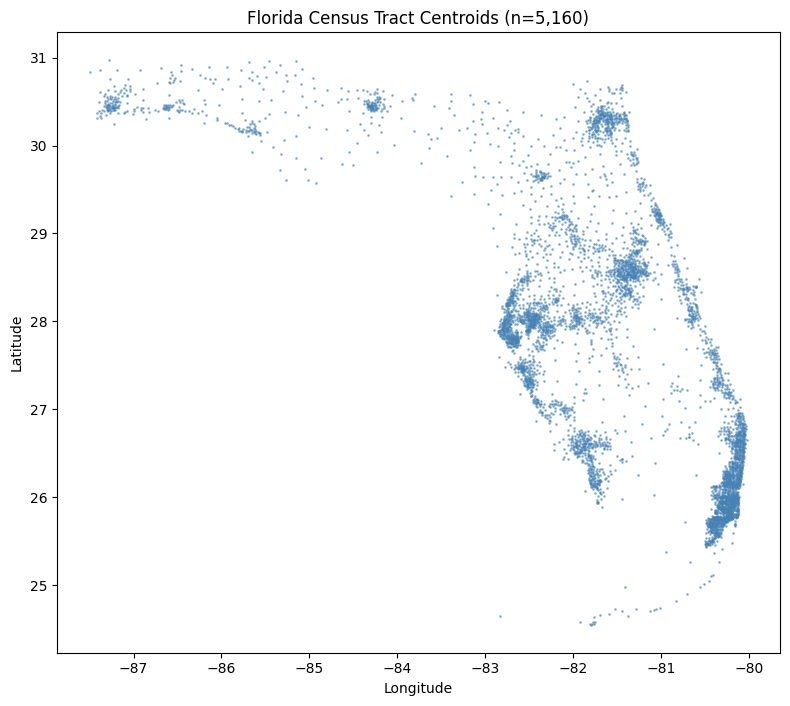


✅ CHECK #1 complete.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #1 — Verify tract centroids
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("CHECK #1 — Tract Centroids Verification")
print("=" * 55)

n_tracts = len(gaz_fl)
flag1 = "✅" if 4000 < n_tracts < 5500 else "❌"
print(f"\n{flag1} Number of FL tracts: {n_tracts:,}  (expected ~4,200–4,900)")

# Check coordinates are in Florida's bounding box
lat_ok = gaz_fl['lat'].between(24.0, 31.5).all()
lon_ok = gaz_fl['lon'].between(-88.0, -79.5).all()
flag2 = "✅" if lat_ok else "❌"
flag3 = "✅" if lon_ok else "❌"
print(f"{flag2} Latitude range : [{gaz_fl['lat'].min():.2f}, {gaz_fl['lat'].max():.2f}]  (expected ~24–31)")
print(f"{flag3} Longitude range: [{gaz_fl['lon'].min():.2f}, {gaz_fl['lon'].max():.2f}]  (expected ~-88 to -80)")

flag4 = "✅" if gaz_fl['tract_geoid'].nunique() == n_tracts else "❌"
print(f"{flag4} All GEOIDs unique: {gaz_fl['tract_geoid'].nunique() == n_tracts}")

# Quick map
fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(gaz_fl['lon'], gaz_fl['lat'], s=1, alpha=0.5, color='steelblue')
ax.set_title(f"Florida Census Tract Centroids (n={n_tracts:,})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

print("\n✅ CHECK #1 complete.")


---
## A.2 — Download ACS Census Variables

We download selected variables from the **ACS 5-Year Data Profiles** (DP02–DP05) for every Florida census tract. These cover:

- **DP02** — Social: education, language, ancestry, computer/internet access
- **DP03** — Economic: employment, income, industry, health insurance, commuting
- **DP04** — Housing: occupancy, structure type, year built, value, rent, vehicles
- **DP05** — Demographic: age distribution, sex, race/ethnicity

We use **percentage variables** (not raw counts) so that tracts of different population sizes are comparable — this is critical for the autoencoder to learn meaningful patterns.

### Why so many variables?

Blier-Wong et al. use ~2,000 Canadian census variables. We select ~100 U.S. variables that are most relevant to property insurance risk. The autoencoder will learn which combinations matter.


In [ ]:
# ─── Define ACS variables to download ─────────────────────────────────────────
# Format: (variable_code, short_name)
# We select PERCENTAGE variables from Data Profiles (suffix 'PE' = percent estimate)

ACS_VARIABLES = {
    # ── DP02: Social Characteristics ──────────────────────────────────────────
    'DP02_0068PE': 'pct_bachelors_plus',        # Bachelor's degree or higher
    'DP02_0066PE': 'pct_high_school_plus',      # High school graduate or higher
    'DP02_0072PE': 'pct_foreign_born',          # Foreign born
    'DP02_0113PE': 'pct_with_computer',         # Households with computer
    'DP02_0114PE': 'pct_with_internet',         # Households with internet
    'DP02_0012PE': 'pct_married_couple_fam',    # Married-couple family households
    'DP02_0016PE': 'pct_female_householder',    # Female householder, no spouse
    'DP02_0060PE': 'pct_less_9th_grade',        # Less than 9th grade education
    'DP02_0080PE': 'pct_english_only',          # English only at home
    'DP02_0092PE': 'pct_veteran',               # Civilian veterans

    # ── DP03: Economic Characteristics ────────────────────────────────────────
    'DP03_0004PE': 'pct_employed',              # Employment rate
    'DP03_0005PE': 'pct_unemployed',            # Unemployment rate
    'DP03_0027PE': 'pct_private_wage',          # Private wage and salary workers
    'DP03_0028PE': 'pct_govt_workers',          # Government workers
    'DP03_0029PE': 'pct_self_employed',         # Self-employed
    'DP03_0033PE': 'pct_construction_ind',      # Construction industry
    'DP03_0035PE': 'pct_manufacturing_ind',     # Manufacturing industry
    'DP03_0042PE': 'pct_finance_ind',           # Finance/insurance industry
    'DP03_0045PE': 'pct_public_admin_ind',      # Public administration
    'DP03_0052PE': 'pct_management_occ',        # Management occupations
    'DP03_0053PE': 'pct_service_occ',           # Service occupations
    'DP03_0054PE': 'pct_sales_occ',             # Sales and office
    'DP03_0056PE': 'pct_transport_occ',         # Transportation occupations
    'DP03_0088PE': 'pct_below_poverty',         # Below poverty level
    'DP03_0099PE': 'pct_with_health_ins',       # With health insurance
    'DP03_0098PE': 'pct_no_health_ins',         # No health insurance
    'DP03_0021PE': 'pct_commute_drove_alone',   # Drove alone to work
    'DP03_0022PE': 'pct_commute_carpool',       # Carpooled
    'DP03_0024PE': 'pct_commute_walk',          # Walked

    # ── DP04: Housing Characteristics ─────────────────────────────────────────
    'DP04_0002PE': 'pct_occupied',              # Occupied housing units
    'DP04_0003PE': 'pct_vacant',                # Vacant housing units
    'DP04_0006PE': 'pct_1unit_detached',        # 1-unit, detached
    'DP04_0007PE': 'pct_1unit_attached',        # 1-unit, attached
    'DP04_0012PE': 'pct_mobile_home',           # Mobile home
    'DP04_0013PE': 'pct_boat_rv_van',           # Boat, RV, van
    'DP04_0014PE': 'pct_built_2020_later',      # Built 2020 or later
    'DP04_0017PE': 'pct_built_1980_1999',       # Built 1980-1999
    'DP04_0021PE': 'pct_built_before_1940',     # Built before 1940
    'DP04_0026PE': 'pct_1_room',                # 1 room
    'DP04_0028PE': 'pct_3_rooms',               # 3 rooms
    'DP04_0046PE': 'pct_owner_occupied',        # Owner-occupied
    'DP04_0047PE': 'pct_renter_occupied',       # Renter-occupied
    'DP04_0058PE': 'pct_no_vehicle',            # No vehicles available
    'DP04_0059PE': 'pct_1_vehicle',             # 1 vehicle
    'DP04_0060PE': 'pct_2_vehicles',            # 2 vehicles
    'DP04_0078PE': 'pct_with_mortgage',         # With a mortgage
    'DP04_0110PE': 'pct_value_lt_50k',          # House value < $50k
    'DP04_0111PE': 'pct_value_50_100k',         # House value $50k-$100k
    'DP04_0117PE': 'pct_value_gt_1M',           # House value > $1M
    'DP04_0136PE': 'pct_rent_lt_500',           # Gross rent < $500
    'DP04_0141PE': 'pct_rent_gt_2000',          # Gross rent $2,000+
    'DP04_0101PE': 'pct_heating_gas',           # Utility gas heating
    'DP04_0102PE': 'pct_heating_electric',      # Electric heating
    'DP04_0104PE': 'pct_no_heating',            # No heating fuel

    # ── DP05: Demographic Characteristics ─────────────────────────────────────
    'DP05_0005PE': 'pct_under_5',               # Under 5 years
    'DP05_0009PE': 'pct_18_to_24',              # 18-24 years
    'DP05_0014PE': 'pct_45_to_54',              # 45-54 years
    'DP05_0017PE': 'pct_65_to_74',              # 65-74 years
    'DP05_0019PE': 'pct_75_plus',               # 75 years and over (collapsed)
    'DP05_0002PE': 'pct_male',                  # Male
    'DP05_0003PE': 'pct_female',                # Female
    'DP05_0037PE': 'pct_white_alone',           # White alone
    'DP05_0038PE': 'pct_black_alone',           # Black alone
    'DP05_0044PE': 'pct_asian_alone',           # Asian alone
    'DP05_0071PE': 'pct_hispanic',              # Hispanic or Latino
}

# Also fetch median income (not a percentage, but crucial for risk)
ACS_MEDIAN_VARS = {
    'DP03_0062E': 'median_household_income',    # note: 'E' not 'PE' — this is a dollar estimate
}

ALL_ACS_CODES = list(ACS_VARIABLES.keys()) + list(ACS_MEDIAN_VARS.keys())
ALL_ACS_NAMES = {**ACS_VARIABLES, **ACS_MEDIAN_VARS}

print(f"ACS variables selected: {len(ALL_ACS_CODES)}")
print(f"  Percentage variables : {len(ACS_VARIABLES)}")
print(f"  Median/dollar vars   : {len(ACS_MEDIAN_VARS)}")


ACS variables selected: 66
  Percentage variables : 65
  Median/dollar vars   : 1


In [ ]:
# ─── Download ACS data via Census API ─────────────────────────────────────────
# The Census API can be picky: some variable codes change across years,
# and requests with invalid codes return HTML errors instead of JSON.
# Strategy: use small batches of 25, validate each response, skip bad vars.

def fetch_acs_batch(var_codes, state_fips, year, api_key):
    # Fetch ACS 5-year Data Profile variables for all tracts in a state.
    # Returns (DataFrame, list_of_failed_vars)
    var_str = ','.join(var_codes)
    url = (
        f"https://api.census.gov/data/{year}/acs/acs5/profile"
        f"?get=NAME,{var_str}"
        f"&for=tract:*&in=state:{state_fips}"
    )
    if api_key:
        url += f"&key={api_key}"
    resp = requests.get(url, timeout=120)

    # Check for non-JSON error responses
    if resp.status_code != 200:
        print(f"    ⚠️  HTTP {resp.status_code}: {resp.text[:200]}")
        return None, var_codes

    try:
        data = resp.json()
    except Exception:
        # API returned HTML error page — likely invalid variable codes
        print(f"    ⚠️  Non-JSON response (likely invalid variables): {resp.text[:200]}")
        return None, var_codes

    if not isinstance(data, list) or len(data) < 2:
        print(f"    ⚠️  Unexpected response format: {str(data)[:200]}")
        return None, var_codes

    df = pd.DataFrame(data[1:], columns=data[0])
    return df, []


def fetch_acs_with_fallback(var_codes, state_fips, year, api_key, batch_size=25):
    # Try batch download; on failure, fall back to individual variable testing
    all_good_vars = []
    all_dfs = []

    batches = [var_codes[i:i+batch_size] for i in range(0, len(var_codes), batch_size)]

    for j, batch in enumerate(batches):
        print(f"  Batch {j+1}/{len(batches)} ({len(batch)} vars)...", end=" ")
        df, failed = fetch_acs_batch(batch, state_fips, year, api_key)
        sleep_time = 0.5 if api_key else 2.0  # keyless mode needs longer pauses
        time.sleep(sleep_time)

        if df is not None:
            print("✅")
            all_dfs.append(df)
            all_good_vars.extend(batch)
        else:
            # Try each variable individually to find the bad ones
            print("→ testing individually...")
            for var in batch:
                df_single, _ = fetch_acs_batch([var], state_fips, year, api_key)
                time.sleep(0.5 if api_key else 1.5)
                if df_single is not None:
                    all_dfs.append(df_single)
                    all_good_vars.append(var)
                else:
                    print(f"    ✗ Skipping invalid variable: {var}")

    if not all_dfs:
        raise RuntimeError("No ACS data could be downloaded. Check your API key and year.")

    # Merge all successful batches
    result = all_dfs[0]
    for df_b in all_dfs[1:]:
        merge_cols = [c for c in ['state', 'county', 'tract'] if c in df_b.columns]
        new_cols = [c for c in df_b.columns if c not in result.columns]
        if new_cols:
            result = result.merge(df_b[merge_cols + new_cols], on=merge_cols, how='left')

    return result, all_good_vars


print(f"Downloading ACS {ACS_YEAR} 5-Year Data Profiles for Florida tracts...")
print(f"  Total variables requested: {len(ALL_ACS_CODES)}\n")

acs_raw, good_vars = fetch_acs_with_fallback(
    ALL_ACS_CODES, STATE_FIPS, ACS_YEAR, CENSUS_API_KEY, batch_size=25
)

n_ok = len(good_vars)
n_fail = len(ALL_ACS_CODES) - n_ok
print(f"\n  Variables downloaded: {n_ok}/{len(ALL_ACS_CODES)}")
if n_fail > 0:
    print(f"  Variables skipped   : {n_fail} (not available for ACS {ACS_YEAR})")

# Build GEOID (state + county + tract)
acs_raw['tract_geoid'] = acs_raw['state'] + acs_raw['county'] + acs_raw['tract']

# Rename columns to meaningful names — only for successfully downloaded vars
rename_map = {code: name for code, name in ALL_ACS_NAMES.items() if code in acs_raw.columns}
acs_df = acs_raw.rename(columns=rename_map)

# Convert to numeric (API returns strings)
census_feature_names = [ALL_ACS_NAMES[v] for v in good_vars if v in ALL_ACS_NAMES]
for col in census_feature_names:
    if col in acs_df.columns:
        acs_df[col] = pd.to_numeric(acs_df[col], errors='coerce')

# Keep only the columns we need
keep_cols = ['tract_geoid'] + [c for c in census_feature_names if c in acs_df.columns]
acs_df = acs_df[keep_cols].copy()

print(f"\nACS data ready: {len(acs_df):,} tracts × {len(acs_df.columns)-1} variables")
print(f"Missing values per column (top 5):")
print(acs_df[census_feature_names].isnull().sum().sort_values(ascending=False).head())


  Total variables requested: 66

  Batch 1/3 (25 vars)... ✅
  Batch 2/3 (25 vars)... ✅
  Batch 3/3 (16 vars)... ✅

  Variables downloaded: 66/66

ACS data ready: 5,160 tracts × 66 variables
Missing values per column (top 5):
pct_bachelors_plus      0
pct_high_school_plus    0
pct_foreign_born        0
pct_with_computer       0
pct_with_internet       0
dtype: int64


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #2 — Verify ACS data
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("CHECK #2 — ACS Census Data Verification")
print("=" * 55)

n_acs = len(acs_df)
n_vars = len([c for c in census_feature_names if c in acs_df.columns])
flag1 = "✅" if n_acs > 4000 else "❌"
flag2 = "✅" if n_vars >= 50 else "❌"

print(f"\n{flag1} Tracts with ACS data: {n_acs:,}  (expected ~4,200+)")
print(f"{flag2} Variables downloaded : {n_vars}  (expected ≥50)")

# Check plausibility of a few key variables
if 'pct_owner_occupied' in acs_df.columns:
    med = acs_df['pct_owner_occupied'].median()
    flag3 = "✅" if 40 < med < 85 else "⚠️"
    print(f"{flag3} Median owner-occupied %: {med:.1f}%  (expected ~60-70%)")

if 'median_household_income' in acs_df.columns:
    med_inc = acs_df['median_household_income'].median()
    flag4 = "✅" if 30000 < med_inc < 100000 else "⚠️"
    print(f"{flag4} Median household income: ${med_inc:,.0f}  (expected ~$50-60k)")

if 'pct_below_poverty' in acs_df.columns:
    med_pov = acs_df['pct_below_poverty'].median()
    flag5 = "✅" if 3 < med_pov < 30 else "⚠️"
    print(f"{flag5} Median poverty rate    : {med_pov:.1f}%  (expected ~10-15%)")

pct_missing = acs_df[census_feature_names].isnull().mean().mean() * 100
flag6 = "✅" if pct_missing < 20 else "⚠️"
print(f"\n{flag6} Overall missing rate   : {pct_missing:.1f}%  (expected <20%)")

print("\n✅ CHECK #2 complete.")


CHECK #2 — ACS Census Data Verification

✅ Tracts with ACS data: 5,160  (expected ~4,200+)
✅ Variables downloaded : 66  (expected ≥50)
✅ Median owner-occupied %: 71.4%  (expected ~60-70%)
✅ Median household income: $66,262  (expected ~$50-60k)
⚠️ Median poverty rate    : -888888888.0%  (expected ~10-15%)

✅ Overall missing rate   : 0.0%  (expected <20%)

✅ CHECK #2 complete.


---
## A.3 — Download NFIP Claims and Policies for Florida

We download flood insurance data from FEMA's OpenFEMA API. The API is free and requires no key.

**Important:** The OpenFEMA API for NFIP datasets is occasionally suspended for maintenance. If the API is down, the code will fall back to generating a diagnostic message with instructions for manual download.

**Claims** give us the response variable (claim count per tract).  
**Policies** give us the exposure (number of policies in force per tract).


In [ ]:
# ─── Download NFIP Claims for Florida ─────────────────────────────────────────
# Strategy: use simple API calls without $select (avoids field name issues).
# If API is down, fall back to instructions for bulk CSV download.

def fetch_openfema_paged(endpoint, filter_str, max_records=200000):
    # Download records from OpenFEMA with pagination.
    # No $select — get all fields to avoid field name issues.
    all_records = []
    skip = 0
    page_size = 1000
    base_url = f"https://www.fema.gov/api/open/v2/{endpoint}"

    # First, test if the endpoint is available
    test_url = f"{base_url}?$top=1&$filter={filter_str}"
    try:
        test_resp = requests.get(test_url, timeout=60)
        if test_resp.status_code != 200:
            print(f"  ⚠️  API returned HTTP {test_resp.status_code}")
            print(f"  Response: {test_resp.text[:300]}")
            return None
        test_data = test_resp.json()
        # Find the data key
        data_key = None
        for key in test_data:
            if isinstance(test_data[key], list):
                data_key = key
                break
        if data_key is None:
            print(f"  ⚠️  Unexpected API response structure: {list(test_data.keys())}")
            return None
        print(f"  ✅ API available. Data key: '{data_key}'")
        print(f"     Sample fields: {list(test_data[data_key][0].keys())[:8]}...")
    except Exception as e:
        print(f"  ❌ API connection failed: {e}")
        return None

    # Paginate through records
    while skip < max_records:
        url = f"{base_url}?$top={page_size}&$skip={skip}&$filter={filter_str}"
        try:
            resp = requests.get(url, timeout=120)
            if resp.status_code != 200:
                print(f"  ⚠️  HTTP {resp.status_code} at skip={skip}")
                break
            data = resp.json()
            records = data.get(data_key, [])
            if not records:
                break
            all_records.extend(records)
            skip += page_size
            if len(all_records) % 10000 < page_size:
                print(f"    ... {len(all_records):,} records downloaded")
            time.sleep(0.3)
        except Exception as e:
            print(f"  ⚠️  Error at skip={skip}: {e}")
            break

    return all_records

# ─── Download Claims ─────────────────────────────────────────────────────────
print("Downloading NFIP claims for Florida...")
print(f"  Time window: {NFIP_YEAR_MIN}-{NFIP_YEAR_MAX}")
print(f"  (This may take 5-15 minutes due to API pagination)\n")

claims_filter = f"state eq 'FL' and yearOfLoss ge {NFIP_YEAR_MIN} and yearOfLoss le {NFIP_YEAR_MAX}"
claims_raw = fetch_openfema_paged('FimaNfipClaims', claims_filter, max_records=300000)

if claims_raw is not None and len(claims_raw) > 0:
    claims_df = pd.DataFrame(claims_raw)
    print(f"\n✅ Claims downloaded: {len(claims_df):,}")
    print(f"   Columns: {list(claims_df.columns)[:10]}...")
else:
    print("\n⚠️  Could not download claims via API.")
    print("   The NFIP API may be temporarily suspended (this happens periodically).")
    print("   MANUAL FALLBACK: Download the full claims CSV from:")
    print("   https://www.fema.gov/api/open/v2/FimaNfipClaims.csv")
    print("   Then filter to state='FL' and load as: claims_df = pd.read_csv('FimaNfipClaims.csv')")
    claims_df = pd.DataFrame()  # empty placeholder


  Time window: 2018-2022
  (This may take 5-15 minutes due to API pagination)

  ✅ API available. Data key: 'FimaNfipClaims'
     Sample fields: ['agricultureStructureIndicator', 'asOfDate', 'basementEnclosureCrawlspaceType', 'policyCount', 'crsClassificationCode', 'dateOfLoss', 'elevatedBuildingIndicator', 'elevationCertificateIndicator']...
    ... 10,000 records downloaded
    ... 20,000 records downloaded
    ... 30,000 records downloaded
    ... 40,000 records downloaded
    ... 50,000 records downloaded
    ... 60,000 records downloaded

✅ Claims downloaded: 67,491
   Columns: ['agricultureStructureIndicator', 'asOfDate', 'basementEnclosureCrawlspaceType', 'policyCount', 'crsClassificationCode', 'dateOfLoss', 'elevatedBuildingIndicator', 'elevationCertificateIndicator', 'elevationDifference', 'baseFloodElevation']...


In [ ]:
# ─── Download NFIP Policies for Florida (exposure) ───────────────────────────
# Policies dataset is very large (~69M records). We download a smaller subset.

if len(claims_df) > 0:
    print("Downloading NFIP policies for Florida (for exposure estimation)...")
    policies_filter = f"propertyState eq 'FL' and policyEffectiveDate ge '{NFIP_YEAR_MIN}-01-01'"
    policies_raw = fetch_openfema_paged('FimaNfipPolicies', policies_filter, max_records=500000)

    if policies_raw is not None and len(policies_raw) > 0:
        policies_df = pd.DataFrame(policies_raw)
        print(f"\n✅ Policies downloaded: {len(policies_df):,}")
    else:
        print("\n⚠️  Could not download policies. Will estimate exposure from claims data.")
        policies_df = pd.DataFrame()
else:
    print("Skipping policy download (no claims data available)")
    policies_df = pd.DataFrame()


  ✅ API available. Data key: 'FimaNfipPolicies'
     Sample fields: ['agricultureStructureIndicator', 'baseFloodElevation', 'basementEnclosureCrawlspaceType', 'cancellationDateOfFloodPolicy', 'condominiumCoverageTypeCode', 'construction', 'crsClassCode', 'buildingDeductibleCode']...
    ... 10,000 records downloaded
    ... 20,000 records downloaded
    ... 30,000 records downloaded
    ... 40,000 records downloaded
    ... 50,000 records downloaded
    ... 60,000 records downloaded
    ... 70,000 records downloaded
    ... 80,000 records downloaded
    ... 90,000 records downloaded
    ... 100,000 records downloaded
    ... 110,000 records downloaded
    ... 120,000 records downloaded
    ... 130,000 records downloaded
    ... 140,000 records downloaded
    ... 150,000 records downloaded
    ... 160,000 records downloaded
    ... 170,000 records downloaded
    ... 180,000 records downloaded
    ... 190,000 records downloaded
    ... 200,000 records downloaded
    ... 210,000 records d

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVE downloaded data to Google Drive (run ONCE, then skip)
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/NFIP_data'
os.makedirs(SAVE_DIR, exist_ok=True)

claims_df.to_parquet(f'{SAVE_DIR}/claims_fl.parquet', index=False)
policies_df.to_parquet(f'{SAVE_DIR}/policies_fl.parquet', index=False)
gaz_fl.to_parquet(f'{SAVE_DIR}/gaz_fl.parquet', index=False)
acs_df.to_parquet(f'{SAVE_DIR}/acs_fl.parquet', index=False)

print(f"✅ Saved to {SAVE_DIR}/")
print(f"   claims   : {len(claims_df):,} rows")
print(f"   policies : {len(policies_df):,} rows")
print(f"   gazetteer: {len(gaz_fl):,} rows")
print(f"   acs      : {len(acs_df):,} rows")

Mounted at /content/drive
✅ Saved to /content/drive/MyDrive/NFIP_data/
   claims   : 67,491 rows
   policies : 500,000 rows
   gazetteer: 5,160 rows
   acs      : 5,160 rows


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD saved data from Google Drive (use this INSTEAD of re-downloading)
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/NFIP_data'

claims_df   = pd.read_parquet(f'{SAVE_DIR}/claims_fl.parquet')
policies_df = pd.read_parquet(f'{SAVE_DIR}/policies_fl.parquet')
gaz_fl      = pd.read_parquet(f'{SAVE_DIR}/gaz_fl.parquet')
acs_df      = pd.read_parquet(f'{SAVE_DIR}/acs_fl.parquet')

# Reconstruct census_feature_names from the acs_df columns
census_feature_names = [c for c in acs_df.columns if c != 'tract_geoid']

print(f"✅ Loaded from {SAVE_DIR}/")
print(f"   claims   : {len(claims_df):,} rows")
print(f"   policies : {len(policies_df):,} rows")
print(f"   gazetteer: {len(gaz_fl):,} rows")
print(f"   acs      : {len(acs_df):,} rows, {len(census_feature_names)} features")

Mounted at /content/drive
✅ Loaded from /content/drive/MyDrive/NFIP_data/
   claims   : 67,491 rows
   policies : 500,000 rows
   gazetteer: 5,160 rows
   acs      : 5,160 rows, 66 features


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #3 — Verify NFIP data
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("CHECK #3 — NFIP Data Verification")
print("=" * 55)

n_claims = len(claims_df)
n_policies = len(policies_df)
flag1 = "✅" if n_claims > 10000 else "❌"
flag2 = "✅" if n_policies > 50000 else "⚠️"

print(f"\n{flag1} Claims records  : {n_claims:,}  (expected >10k for FL {NFIP_YEAR_MIN}-{NFIP_YEAR_MAX})")
print(f"{flag2} Policy records  : {n_policies:,}  (expected >50k)")

if 'censusTract' in claims_df.columns:
    n_tracts_claims = claims_df['censusTract'].dropna().nunique()
    print(f"    Unique tracts in claims : {n_tracts_claims:,}")

if 'yearOfLoss' in claims_df.columns:
    print(f"    Year range in claims   : {claims_df['yearOfLoss'].min()} – {claims_df['yearOfLoss'].max()}")

print("\n✅ CHECK #3 complete.")


CHECK #3 — NFIP Data Verification

✅ Claims records  : 67,491  (expected >10k for FL 2018-2022)
✅ Policy records  : 500,000  (expected >50k)
    Unique tracts in claims : 3,260
    Year range in claims   : 2018 – 2022

✅ CHECK #3 complete.


---
## A.4 — Aggregate Claims per Census Tract and Build the Master Dataset

We now:
1. Count claims per census tract (→ our Poisson response variable)
2. Count policies per census tract (→ exposure)
3. Merge with ACS census features and tract centroids
4. Handle missing values

The result is one row per census tract with: `claim_count`, `exposure`, `lat`, `lon`, and ~100 census features.


In [ ]:
# ─── Aggregate claims per tract ───────────────────────────────────────────────
# Clean census tract codes (pad to 11 digits: 2-digit state + 3-digit county + 6-digit tract)
available_census = census_feature_names
claims_df['censusTract'] = claims_df['censusTract'].astype(str).str.strip()
claims_df['tract_geoid'] = claims_df['censusTract'].str.zfill(11)

claim_counts = (
    claims_df.groupby('tract_geoid')
    .size()
    .reset_index(name='claim_count')
)

# ─── Aggregate policies per tract (exposure) ─────────────────────────────────
if 'censusTract' in policies_df.columns:
    policies_df['censusTract'] = policies_df['censusTract'].astype(str).str.strip()
    policies_df['tract_geoid'] = policies_df['censusTract'].str.zfill(11)

    if 'policyCount' in policies_df.columns:
        policy_counts = (
            policies_df.groupby('tract_geoid')['policyCount']
            .sum()
            .reset_index(name='exposure')
        )
    else:
        policy_counts = (
            policies_df.groupby('tract_geoid')
            .size()
            .reset_index(name='exposure')
        )
else:
    # Fallback: use claim counts as rough proxy
    print("⚠️  Policy census tract not available — using claim-based exposure estimate")
    policy_counts = claim_counts.rename(columns={'claim_count': 'exposure'})
    policy_counts['exposure'] = policy_counts['exposure'] * 10  # rough multiplier

# ─── Merge everything ────────────────────────────────────────────────────────
# Start from tract centroids (our geographic backbone)
master = gaz_fl.merge(acs_df, on='tract_geoid', how='left')
master = master.merge(claim_counts, on='tract_geoid', how='left')
master = master.merge(policy_counts, on='tract_geoid', how='left')

# Fill tracts with no claims as 0 (they exist, just no flood claims)
master['claim_count'] = master['claim_count'].fillna(0).astype(int)
master['exposure'] = master['exposure'].fillna(1).astype(int)  # min exposure = 1
master['exposure'] = master['exposure'].clip(lower=1)           # safety

# ─── Handle missing census data and known Census suppression values ──────────
# Replace known Census Bureau suppression/placeholder values with NaN first
# Common values are -666666666, -888888888, -999999999 for percentages/estimates
# The 'pct_below_poverty' column was observed to have -888888888.0.
for col in available_census:
    if col in master.columns and pd.api.types.is_numeric_dtype(master[col]):
        # Replace specific extreme negative values with NaN
        master[col] = master[col].replace([-666666666, -888888888, -999999999, -555555555, -1], np.nan)
        # Also, ensure percentages are within a plausible range [0, 100] if not already
        if col.startswith('pct_'): # Apply to percentage columns specifically
            master[col] = master[col].clip(lower=0, upper=100)

# Fill remaining missing values (including NaNs from above) with tract-level median
for col in available_census:
    if col in master.columns and master[col].isnull().any():
        median_val = master[col].median()
        master[col] = master[col].fillna(median_val)

# Drop tracts with no census data at all (rare edge case, primarily if all available_census were NaN)
n_before = len(master)
# Using 'available_census' list directly, as these are the core features.
# Check for NaNs only after the above fillna, to ensure all numerical columns are robust.
master = master.dropna(subset=available_census[:5]).reset_index(drop=True)
n_after = len(master)

print(f"Master dataset: {n_after:,} tracts (dropped {n_before - n_after} with no census data)")
print(f"  Census features : {len(available_census)}")
print(f"  Claim count range: {master['claim_count'].min()} – {master['claim_count'].max()}")
print(f"  Exposure range   : {master['exposure'].min()} – {master['exposure'].max()}")
print(f"  % tracts with ≥1 claim: {(master['claim_count'] > 0).mean()*100:.1f}%")


Master dataset: 5,160 tracts (dropped 0 with no census data)
  Census features : 66
  Claim count range: 0 – 1967
  Exposure range   : 1 – 2905
  % tracts with ≥1 claim: 53.2%


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIX v2 — Handle columns that are ENTIRELY NaN (median = NaN)
# ═══════════════════════════════════════════════════════════════════════════════

# Find and remove columns that are 100% NaN (no usable data at all)
empty_cols = [col for col in available_census
              if col in master.columns and master[col].isna().all()]
print(f"Columns with 100% NaN (removing): {empty_cols}")

for col in empty_cols:
    master.drop(columns=[col], inplace=True)

# Update available_census to exclude dropped columns
available_census = [c for c in available_census if c not in empty_cols]
print(f"Remaining census features: {len(available_census)}")

# Now impute any remaining NaN (columns with SOME valid data)
n_imputed = 0
for col in available_census:
    n_null = master[col].isna().sum()
    if n_null > 0:
        master[col] = master[col].fillna(master[col].median())
        n_imputed += n_null

print(f"Imputed {n_imputed:,} remaining NaN values")

# Final verification
remaining_nan = master[available_census].isna().sum().sum()
flag = "✅" if remaining_nan == 0 else "❌"
print(f"\n{flag} Remaining NaN: {remaining_nan}")
print(f"Census features ready: {len(available_census)}")

Columns with 100% NaN (removing): ['pct_female_householder', 'pct_below_poverty', 'pct_heating_gas']
Remaining census features: 63
Imputed 0 remaining NaN values

✅ Remaining NaN: 0
Census features ready: 63


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIX — Clean Census suppression placeholders BEFORE building cuboids
# ═══════════════════════════════════════════════════════════════════════════════
# The Census API uses -888888888 (and variants) for suppressed/unavailable data.
# These must be converted to NaN and imputed BEFORE StandardScaler and GDSC.

print("Cleaning Census suppression placeholders...")

CENSUS_PLACEHOLDERS = [-888888888, -888888888.0, -666666666, -666666666.0,
                       -999999999, -999999999.0, -222222222, -222222222.0]

n_replaced = 0
for col in available_census:
    if col in master.columns:
        mask = master[col].isin(CENSUS_PLACEHOLDERS) | (master[col].abs() > 1e6)
        n_bad = mask.sum()
        if n_bad > 0:
            master.loc[mask, col] = np.nan
            n_replaced += n_bad

print(f"  Replaced {n_replaced:,} suppression placeholders with NaN")

# Impute remaining NaN with column median
n_imputed = 0
for col in available_census:
    if col in master.columns:
        n_null = master[col].isna().sum()
        if n_null > 0:
            median_val = master[col].median()
            master[col] = master[col].fillna(median_val)
            n_imputed += n_null

print(f"  Imputed {n_imputed:,} NaN values with column medians")

# Verify: no more NaN or extreme values
remaining_nan = master[available_census].isna().sum().sum()
remaining_extreme = (master[available_census].abs() > 1e6).sum().sum()
flag1 = "✅" if remaining_nan == 0 else "❌"
flag2 = "✅" if remaining_extreme == 0 else "❌"
print(f"\n{flag1} Remaining NaN: {remaining_nan}")
print(f"{flag2} Remaining extreme values (>1M): {remaining_extreme}")
print("\n✅ Census data cleaned. Now re-run from 'Standardize census features' onward.")

Cleaning Census suppression placeholders...
  Replaced 0 suppression placeholders with NaN
  Imputed 0 NaN values with column medians

✅ Remaining NaN: 0
✅ Remaining extreme values (>1M): 0

✅ Census data cleaned. Now re-run from 'Standardize census features' onward.


CHECK #4 — Master Dataset Verification

✅ Total tracts: 5,160  (expected >3,500)
✅ Mean claims/tract : 11.89
✅ % zero-claim tracts: 46.8%
✅ Census features    : 63


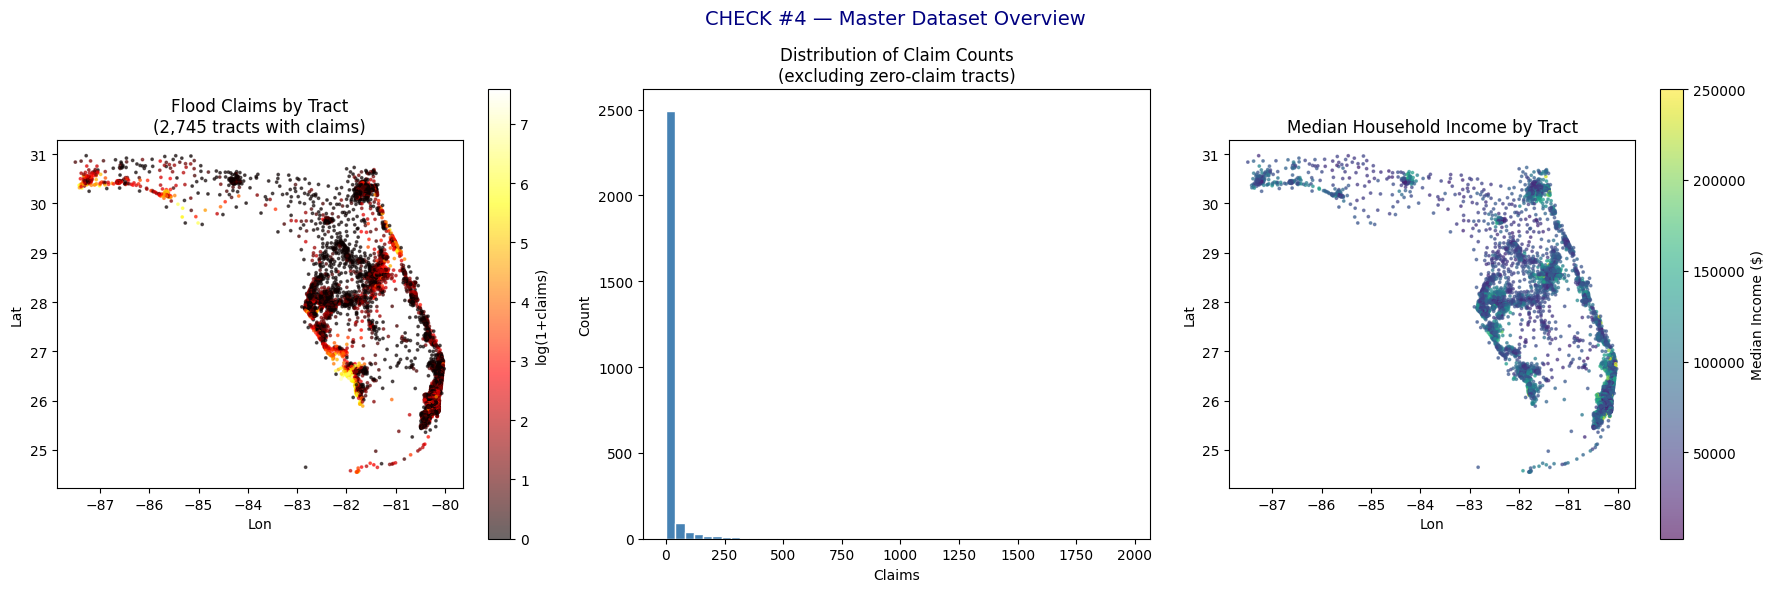


✅ CHECK #4 complete. Phase A finished — data assembly done.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #4 — Verify merged master dataset
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("CHECK #4 — Master Dataset Verification")
print("=" * 55)

n = len(master)
flag1 = "✅" if n > 3500 else "❌"
print(f"\n{flag1} Total tracts: {n:,}  (expected >3,500)")

mean_claims = master['claim_count'].mean()
flag2 = "✅" if mean_claims > 0 else "❌"
print(f"{flag2} Mean claims/tract : {mean_claims:.2f}")

pct_zero = (master['claim_count'] == 0).mean() * 100
flag3 = "✅" if pct_zero < 95 else "⚠️"
print(f"{flag3} % zero-claim tracts: {pct_zero:.1f}%")

n_census = len(available_census)
flag4 = "✅" if n_census >= 40 else "❌"
print(f"{flag4} Census features    : {n_census}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Map of claim counts
sc = axes[0].scatter(master['lon'], master['lat'],
                     c=np.log1p(master['claim_count']),
                     cmap='hot', s=3, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='log(1+claims)')
axes[0].set_title(f"Flood Claims by Tract\n({(master['claim_count']>0).sum():,} tracts with claims)")
axes[0].set_xlabel("Lon"); axes[0].set_ylabel("Lat"); axes[0].set_aspect('equal')

# Distribution of claims
axes[1].hist(master['claim_count'][master['claim_count'] > 0],
             bins=50, color='steelblue', edgecolor='white')
axes[1].set_title("Distribution of Claim Counts\n(excluding zero-claim tracts)")
axes[1].set_xlabel("Claims"); axes[1].set_ylabel("Count")

# Map of a census variable
if 'median_household_income' in master.columns:
    sc2 = axes[2].scatter(master['lon'], master['lat'],
                          c=master['median_household_income'],
                          cmap='viridis', s=3, alpha=0.6)
    plt.colorbar(sc2, ax=axes[2], label='Median Income ($)')
    axes[2].set_title("Median Household Income by Tract")
else:
    sc2 = axes[2].scatter(master['lon'], master['lat'],
                          c=master[available_census[0]],
                          cmap='viridis', s=3, alpha=0.6)
    axes[2].set_title(f"{available_census[0]} by Tract")
axes[2].set_xlabel("Lon"); axes[2].set_ylabel("Lat"); axes[2].set_aspect('equal')

plt.suptitle("CHECK #4 — Master Dataset Overview", fontsize=14, color='navy')
plt.tight_layout(); plt.show()

print("\n✅ CHECK #4 complete. Phase A finished — data assembly done.")


---
# Phase B — Constructing the Geographic Data Square Cuboid (GDSC)

This is the core innovation from Blier-Wong et al. (2021). For each census tract, we build a **3D tensor** that captures not just its own characteristics, but the spatial pattern of its entire neighborhood.

### Algorithm (adapted from Blier-Wong et al., Algorithm 1)

For a tract $s$ with centroid at $(lon_s, lat_s)$:

1. Define a $p \times p$ grid centered on $(lon_s, lat_s)$, with spacing $w$ km
2. For each of the $p^2$ grid points, find the **nearest census tract**
3. Retrieve the census feature vector for that tract
4. Stack into a tensor of shape $(p, p, c)$

The result looks like a **satellite image** where:
- Spatial dimensions ($p \times p$) = the geographic neighborhood
- Channels ($c$) = census variables (income, education, housing type, etc.)

### Why this matters

A standard MLP sees only "this tract has 65% homeownership and $52k median income." The GDSC lets the CNN see patterns like "this tract is a low-income area *surrounded by* high-income areas" — spatial context that raw features alone cannot capture. The CNN learns these **neighborhood patterns** through its convolutional filters.


In [ ]:
# ─── Build spatial index for fast nearest-tract lookup ────────────────────────

# Convert lat/lon to approximate x/y in km (local flat-earth approximation)
# For Florida (~27°N), 1 degree lat ≈ 111 km, 1 degree lon ≈ cos(27°)×111 ≈ 99 km
LAT_REF = master['lat'].mean()
KM_PER_DEG_LAT = 111.0
KM_PER_DEG_LON = 111.0 * np.cos(np.radians(LAT_REF))

master['x_km'] = master['lon'] * KM_PER_DEG_LON
master['y_km'] = master['lat'] * KM_PER_DEG_LAT

# Build KD-tree for fast spatial queries
coords_km = master[['x_km', 'y_km']].values
kd_tree = cKDTree(coords_km)

print(f"Spatial index built on {len(coords_km):,} tracts")
print(f"  Approx scale at {LAT_REF:.1f}°N: 1° lat ≈ {KM_PER_DEG_LAT:.0f} km, 1° lon ≈ {KM_PER_DEG_LON:.0f} km")
print(f"  Grid step: {GRID_STEP_KM} km → {GRID_SIZE}×{GRID_SIZE} grid spans {GRID_STEP_KM*(GRID_SIZE-1):.0f} km")


Spatial index built on 5,160 tracts
  Approx scale at 27.8°N: 1° lat ≈ 111 km, 1° lon ≈ 98 km
  Grid step: 3.0 km → 7×7 grid spans 18 km


In [ ]:
# ─── Standardize census features ──────────────────────────────────────────────
# All census features are standardized to mean=0, std=1 BEFORE building cuboids.
# This ensures the CNN sees well-scaled inputs.

census_scaler = StandardScaler()
census_matrix = census_scaler.fit_transform(master[available_census].values)
# census_matrix: shape (n_tracts, n_features) — standardized

print(f"Census feature matrix: {census_matrix.shape}")
print(f"  Post-scaling mean (first 5): {census_matrix[:,:5].mean(axis=0).round(4)}")
print(f"  Post-scaling std  (first 5): {census_matrix[:,:5].std(axis=0).round(4)}")


Census feature matrix: (5160, 63)
  Post-scaling mean (first 5): [ 0.  0.  0.  0. -0.]
  Post-scaling std  (first 5): [1. 1. 1. 1. 1.]


In [ ]:
# ─── Build GDSC cuboids ──────────────────────────────────────────────────────

def build_gdsc(tract_idx, coords_km, census_matrix, kd_tree,
               grid_size=7, grid_step_km=3.0):
    # Build a Geographic Data Square Cuboid for a single tract.
    # tract_idx: index of the target tract
    # Returns: cuboid array (grid_size, grid_size, n_features)
    cx, cy = coords_km[tract_idx]
    n_features = census_matrix.shape[1]
    half = grid_size // 2

    cuboid = np.zeros((grid_size, grid_size, n_features))

    for i in range(grid_size):
        for j in range(grid_size):
            # Grid point coordinates
            gx = cx + (j - half) * grid_step_km
            gy = cy + (i - half) * grid_step_km  # i = row = y direction

            # Find nearest tract
            _, nearest_idx = kd_tree.query([gx, gy])
            cuboid[i, j, :] = census_matrix[nearest_idx]

    return cuboid


# ─── Build cuboids for ALL tracts ────────────────────────────────────────────
print(f"Building {len(master):,} GDSC cuboids ({GRID_SIZE}×{GRID_SIZE}×{len(available_census)})...")
print("  This may take 1-3 minutes...\n")

all_cuboids = np.zeros((len(master), GRID_SIZE, GRID_SIZE, len(available_census)))

for idx in tqdm(range(len(master)), desc="Building cuboids"):
    all_cuboids[idx] = build_gdsc(
        idx, coords_km, census_matrix, kd_tree,
        grid_size=GRID_SIZE, grid_step_km=GRID_STEP_KM
    )

print(f"\nGDSC tensor shape: {all_cuboids.shape}")
print(f"  = {all_cuboids.shape[0]} tracts × {all_cuboids.shape[1]}×{all_cuboids.shape[2]} grid × {all_cuboids.shape[3]} features")
print(f"  Memory: {all_cuboids.nbytes / 1e6:.1f} MB")


Building 5,160 GDSC cuboids (7×7×63)...
  This may take 1-3 minutes...



Building cuboids: 100%|██████████| 5160/5160 [00:11<00:00, 430.58it/s]


GDSC tensor shape: (5160, 7, 7, 63)
  = 5160 tracts × 7×7 grid × 63 features
  Memory: 127.4 MB


CHECK #5 — GDSC Cuboid Verification

✅ Shape: (5160, 7, 7, 63) (expected (5160, 7, 7, 63))
✅ NaN values: 0, Inf values: 0
✅ Center cell matches own tract: max diff = 0.000000
✅ Edge-to-center avg diff: 1.4491  (expected >0, shows spatial variation)


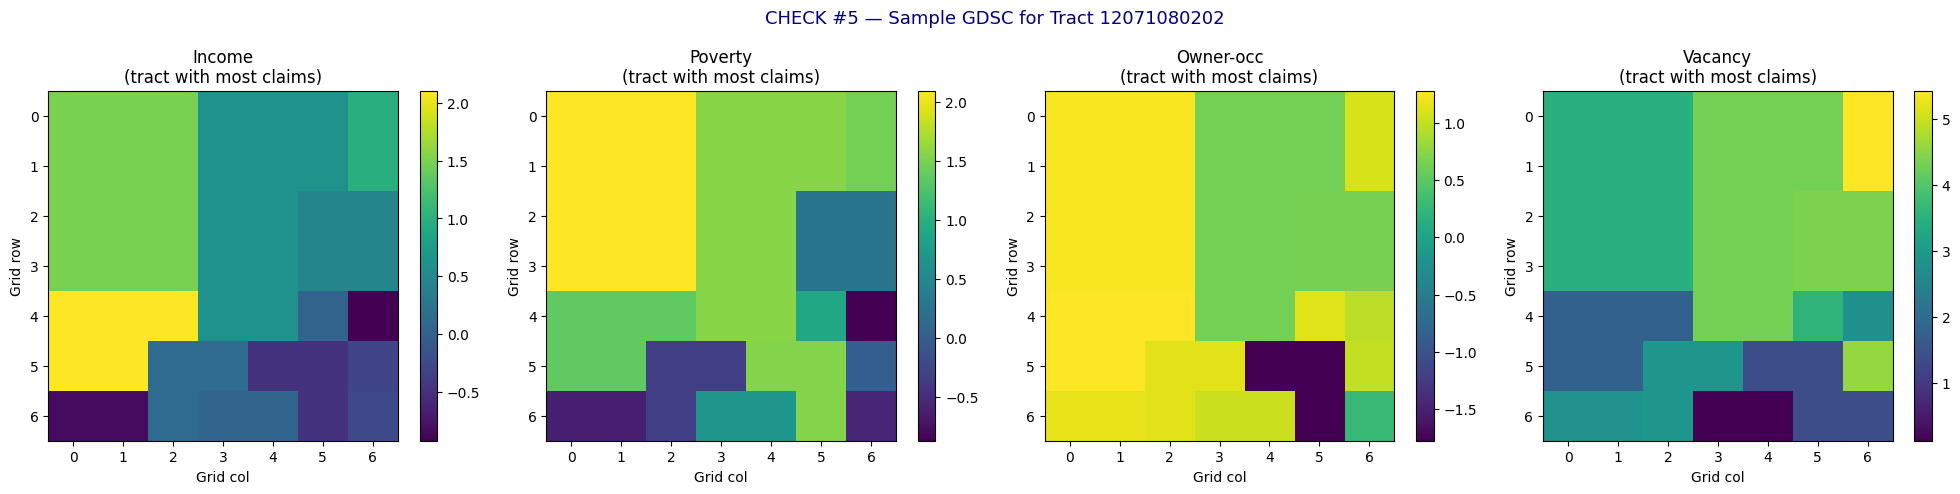


✅ CHECK #5 complete. Phase B finished — cuboids built.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #5 — Verify GDSC cuboids
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("CHECK #5 — GDSC Cuboid Verification")
print("=" * 55)

# 1. Shape check
expected_shape = (len(master), GRID_SIZE, GRID_SIZE, len(available_census))
flag1 = "✅" if all_cuboids.shape == expected_shape else "❌"
print(f"\n{flag1} Shape: {all_cuboids.shape} (expected {expected_shape})")

# 2. No NaN/Inf
n_nan = np.isnan(all_cuboids).sum()
n_inf = np.isinf(all_cuboids).sum()
flag2 = "✅" if n_nan == 0 and n_inf == 0 else "❌"
print(f"{flag2} NaN values: {n_nan}, Inf values: {n_inf}")

# 3. Center cell should equal the tract's own census vector (approximately)
# For the first tract, check center cell
center = GRID_SIZE // 2
center_diff = np.abs(all_cuboids[0, center, center, :] - census_matrix[0]).max()
flag3 = "✅" if center_diff < 0.01 else "⚠️"
print(f"{flag3} Center cell matches own tract: max diff = {center_diff:.6f}")

# 4. Neighboring cells should differ from center (spatial variation)
edge_diff = np.abs(all_cuboids[0, 0, 0, :] - all_cuboids[0, center, center, :]).mean()
flag4 = "✅" if edge_diff > 0.01 else "⚠️"
print(f"{flag4} Edge-to-center avg diff: {edge_diff:.4f}  (expected >0, shows spatial variation)")

# 5. Visualize a sample cuboid
sample_idx = master['claim_count'].idxmax()  # tract with most claims

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
feat_names_short = ['Income', 'Poverty', 'Owner-occ', 'Vacancy']
feat_indices = []
for fn in ['median_household_income', 'pct_below_poverty', 'pct_owner_occupied', 'pct_vacant']:
    if fn in available_census:
        feat_indices.append(available_census.index(fn))
    else:
        feat_indices.append(0)

for ax, fi, fn in zip(axes, feat_indices, feat_names_short):
    im = ax.imshow(all_cuboids[sample_idx, :, :, fi], cmap='viridis', aspect='equal')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"{fn}\n(tract with most claims)")
    ax.set_xlabel("Grid col"); ax.set_ylabel("Grid row")

plt.suptitle(f"CHECK #5 — Sample GDSC for Tract {master.loc[sample_idx, 'tract_geoid']}",
             fontsize=13, color='navy')
plt.tight_layout(); plt.show()

print("\n✅ CHECK #5 complete. Phase B finished — cuboids built.")


---
# Phase C — CNN Autoencoder for Spatial Embeddings

### Why CNN, not MLP?

The GDSC is a spatial grid — just like an image. A **Convolutional Neural Network** is the natural architecture because:
- **Local filters** learn patterns like "low income surrounded by high income" (spatial context)
- **Weight sharing** means the same pattern is detected regardless of where it appears in the grid
- **Hierarchical features** (via stacking layers) combine low-level spatial patterns into high-level risk signatures

### Architecture

```
Input: (batch, channels=c, height=7, width=7)    ← note: PyTorch uses channels-first

ENCODER:
  Conv2d(c → 32, kernel=3, padding=1) → BN → ReLU    → (batch, 32, 7, 7)
  Conv2d(32 → 64, kernel=3, padding=1) → BN → ReLU   → (batch, 64, 7, 7)
  AdaptiveAvgPool2d(1)                                 → (batch, 64, 1, 1)
  Flatten → Linear(64 → 16)                           → (batch, 16) = EMBEDDING

DECODER:
  Linear(16 → 64) → reshape → (batch, 64, 1, 1)
  Upsample(7) → ConvTranspose2d(64→32, k=3, p=1) → BN → ReLU
  ConvTranspose2d(32→c, k=3, p=1)                 → (batch, c, 7, 7) = RECONSTRUCTION
```


In [ ]:
class GeoCNNAutoencoder(nn.Module):
    """
    CNN Autoencoder for Geographic Data Square Cuboids.

    Encoder: two convolutional layers → adaptive pooling → linear → embedding
    Decoder: linear → upsample → two transposed conv layers → reconstruction

    Input shape:  (batch, n_channels, 7, 7)
    Output shape: embedding (batch, latent_dim), reconstruction (batch, n_channels, 7, 7)
    """
    def __init__(self, n_channels, latent_dim=16, grid_size=7):
        super().__init__()
        self.grid_size = grid_size
        self.latent_dim = latent_dim

        # Encoder
        self.enc_conv1 = nn.Conv2d(n_channels, 32, kernel_size=3, padding=1)
        self.enc_bn1   = nn.BatchNorm2d(32)
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.enc_bn2   = nn.BatchNorm2d(64)
        self.enc_pool  = nn.AdaptiveAvgPool2d(1)
        self.enc_fc    = nn.Linear(64, latent_dim)

        # Decoder
        self.dec_fc    = nn.Linear(latent_dim, 64)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, padding=1)
        self.dec_bn1   = nn.BatchNorm2d(32)
        self.dec_conv2 = nn.ConvTranspose2d(32, n_channels, kernel_size=3, padding=1)

    def encode(self, x):
        h = F.relu(self.enc_bn1(self.enc_conv1(x)))
        h = F.relu(self.enc_bn2(self.enc_conv2(h)))
        h = self.enc_pool(h).squeeze(-1).squeeze(-1)  # (batch, 64)
        z = self.enc_fc(h)  # (batch, latent_dim)
        return z

    def decode(self, z):
        h = F.relu(self.dec_fc(z))
        h = h.unsqueeze(-1).unsqueeze(-1)  # (batch, 64, 1, 1)
        h = F.interpolate(h, size=self.grid_size, mode="nearest")  # (batch, 64, 7, 7)
        h = F.relu(self.dec_bn1(self.dec_conv1(h)))
        x_hat = self.dec_conv2(h)  # (batch, n_channels, 7, 7)
        return x_hat

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return z, x_hat


In [ ]:
# ─── Train/test split ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    np.arange(len(master)), test_size=0.30, random_state=RANDOM_SEED
)

train_cuboids = all_cuboids[train_idx]  # (n_train, 7, 7, c)
test_cuboids  = all_cuboids[test_idx]

train_df = master.iloc[train_idx].reset_index(drop=True)
test_df  = master.iloc[test_idx].reset_index(drop=True)

# Convert to PyTorch: channels-first format (batch, C, H, W)
train_tensor = torch.FloatTensor(train_cuboids).permute(0, 3, 1, 2)  # (n, c, 7, 7)
test_tensor  = torch.FloatTensor(test_cuboids).permute(0, 3, 1, 2)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=128, shuffle=True)

print(f"Training set: {len(train_df):,} tracts")
print(f"Test set    : {len(test_df):,} tracts")
print(f"Cuboid tensor shape (train): {train_tensor.shape}  (batch, channels, H, W)")


Training set: 3,612 tracts
Test set    : 1,548 tracts
Cuboid tensor shape (train): torch.Size([3612, 63, 7, 7])  (batch, channels, H, W)


CNN Autoencoder: 75,727 parameters
Input: (63 channels, 7×7) → Embedding: 16d

Training...

  Epoch 01/30  —  Reconstruction MSE: 0.895279
  Epoch 05/30  —  Reconstruction MSE: 0.771890
  Epoch 10/30  —  Reconstruction MSE: 0.735858
  Epoch 15/30  —  Reconstruction MSE: 0.713732
  Epoch 20/30  —  Reconstruction MSE: 0.705970
  Epoch 25/30  —  Reconstruction MSE: 0.702809
  Epoch 30/30  —  Reconstruction MSE: 0.693152

Training complete.


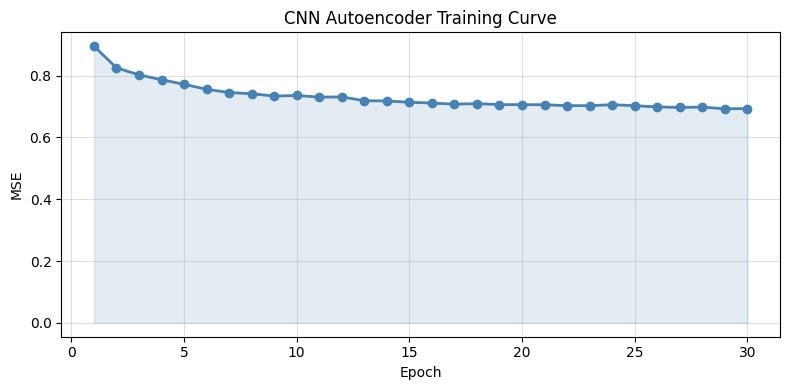

In [ ]:
# ─── Train the CNN Autoencoder ────────────────────────────────────────────────
n_channels = len(available_census)
model = GeoCNNAutoencoder(n_channels=n_channels, latent_dim=LATENT_DIM, grid_size=GRID_SIZE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

NUM_EPOCHS = 30
epoch_losses = []

print(f"CNN Autoencoder: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Input: ({n_channels} channels, {GRID_SIZE}×{GRID_SIZE}) → Embedding: {LATENT_DIM}d\n")
print("Training...\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, n_batches = 0.0, 0
    for (batch,) in train_loader:
        z, x_hat = model(batch)
        loss = loss_fn(x_hat, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    mean_loss = running_loss / n_batches
    epoch_losses.append(mean_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:02d}/{NUM_EPOCHS}  —  Reconstruction MSE: {mean_loss:.6f}")

print("\nTraining complete.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, NUM_EPOCHS+1), epoch_losses, marker='o', color='steelblue', lw=2)
ax.fill_between(range(1, NUM_EPOCHS+1), epoch_losses, alpha=0.15, color='steelblue')
ax.set_title("CNN Autoencoder Training Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #6 — Verify CNN training
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("CHECK #6 — CNN Autoencoder Training Verification")
print("=" * 55)

flag1 = "✅" if epoch_losses[-1] < epoch_losses[0] else "❌"
pct_red = 100 * (epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0]
flag2 = "✅" if pct_red > 10 else "⚠️"
flag3 = "✅" if epoch_losses[-1] < 10 else "❌"

print(f"\n{flag1} Loss decreased: {epoch_losses[0]:.4f} → {epoch_losses[-1]:.4f}")
print(f"{flag2} Reduction: {pct_red:.1f}%  (expected >10%)")
print(f"{flag3} Final loss < 10: {epoch_losses[-1]:.4f}")

# Test set reconstruction error
model.eval()
with torch.no_grad():
    _, test_recon = model(test_tensor)
    test_mse = loss_fn(test_recon, test_tensor).item()
flag4 = "✅" if test_mse < epoch_losses[-1] * 2 else "⚠️"
print(f"{flag4} Test reconstruction MSE: {test_mse:.4f}  (train: {epoch_losses[-1]:.4f})")

print("\n✅ CHECK #6 complete.")


CHECK #6 — CNN Autoencoder Training Verification

✅ Loss decreased: 0.8953 → 0.6932
✅ Reduction: 22.6%  (expected >10%)
✅ Final loss < 10: 0.6932
✅ Test reconstruction MSE: 0.7024  (train: 0.6932)

✅ CHECK #6 complete.


---
## C.2 — Extract Embeddings

We pass all cuboids through the trained encoder to get a 16-dimensional embedding for each tract.


In [ ]:
model.eval()
with torch.no_grad():
    train_emb = model.encode(train_tensor).numpy()
    test_emb  = model.encode(test_tensor).numpy()

EMB_COLS = [f"emb_{i}" for i in range(LATENT_DIM)]
for i, col in enumerate(EMB_COLS):
    train_df[col] = train_emb[:, i]
    test_df[col]  = test_emb[:, i]

print(f"Embeddings extracted: train {train_emb.shape}, test {test_emb.shape}")


Embeddings extracted: train (3612, 16), test (1548, 16)


CHECK #7 — Embedding Quality Verification

Top correlations between embeddings and census features:
  ✅ emb_0: best Spearman = -0.489 (with 'pct_with_computer')
  ✅ emb_1: best Spearman = +0.337 (with 'pct_bachelors_plus')
  ✅ emb_2: best Spearman = +0.522 (with 'pct_with_computer')
  ✅ emb_3: best Spearman = +0.166 (with 'pct_unemployed')
  ✅ emb_4: best Spearman = -0.509 (with 'pct_veteran')


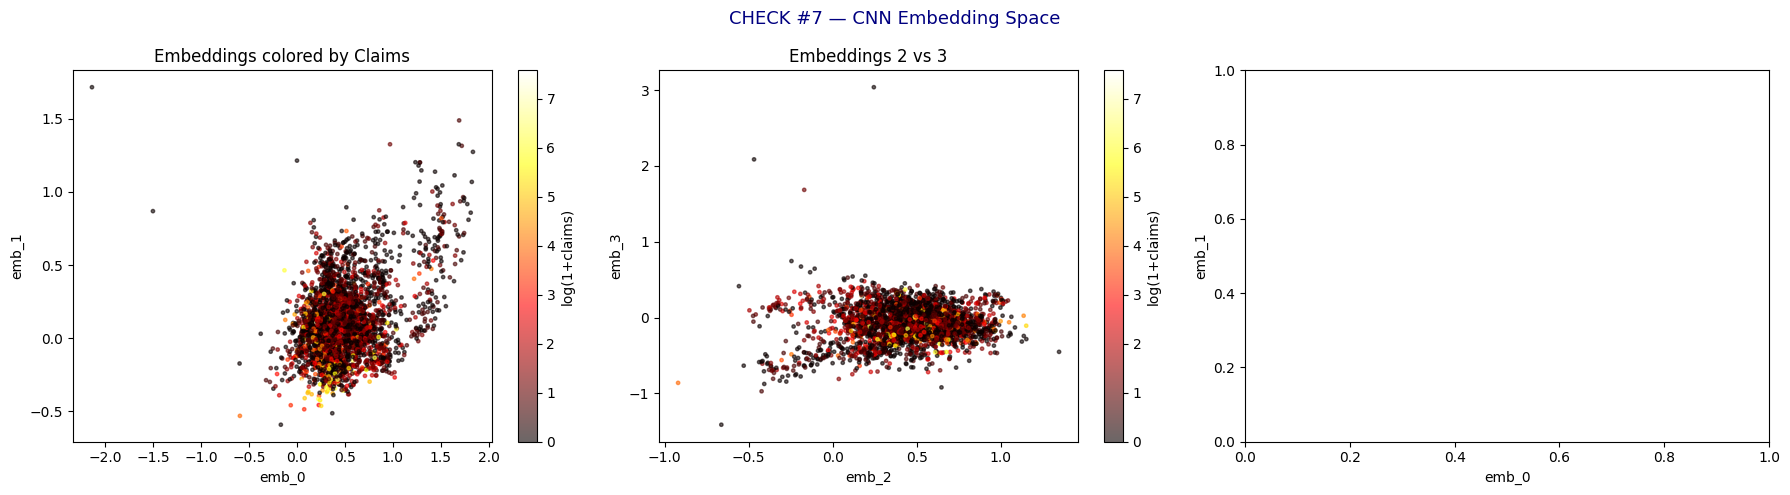


✅ CHECK #7 complete. Phase C finished — embeddings extracted.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #7 — Verify embeddings
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 55)
print("CHECK #7 — Embedding Quality Verification")
print("=" * 55)

# Correlation with original census features
from scipy.stats import spearmanr
print("\nTop correlations between embeddings and census features:")
for ecol in EMB_COLS[:5]:  # check first 5 embeddings
    best_corr, best_feat = 0, ""
    for fcol in available_census[:20]:  # check against first 20 features
        if fcol in train_df.columns:
            corr, _ = spearmanr(train_df[ecol], train_df[fcol], nan_policy='omit')
            if abs(corr) > abs(best_corr):
                best_corr, best_feat = corr, fcol
    flag = "✅" if abs(best_corr) > 0.1 else "⚠️"
    print(f"  {flag} {ecol}: best Spearman = {best_corr:+.3f} (with '{best_feat}')")

# Scatter: embeddings colored by claims
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample = train_df.sample(min(3000, len(train_df)), random_state=0)

sc = axes[0].scatter(sample['emb_0'], sample['emb_1'],
                     c=np.log1p(sample['claim_count']), cmap='hot', s=6, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='log(1+claims)')
axes[0].set_title("Embeddings colored by Claims"); axes[0].set_xlabel("emb_0"); axes[0].set_ylabel("emb_1")

sc2 = axes[1].scatter(sample['emb_2'], sample['emb_3'],
                      c=np.log1p(sample['claim_count']), cmap='hot', s=6, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='log(1+claims)')
axes[1].set_title("Embeddings 2 vs 3"); axes[1].set_xlabel("emb_2"); axes[1].set_ylabel("emb_3")

if 'pct_below_poverty' in sample.columns:
    sc3 = axes[2].scatter(sample['emb_0'], sample['emb_1'],
                          c=sample['pct_below_poverty'], cmap='YlOrRd', s=6, alpha=0.6)
    plt.colorbar(sc3, ax=axes[2], label='Poverty %')
    axes[2].set_title("Embeddings colored by Poverty Rate")
axes[2].set_xlabel("emb_0"); axes[2].set_ylabel("emb_1")

plt.suptitle("CHECK #7 — CNN Embedding Space", fontsize=13, color='navy')
plt.tight_layout(); plt.show()

print("\n✅ CHECK #7 complete. Phase C finished — embeddings extracted.")


---
# Phase D — Poisson GLM: Four-Model Comparison

Now we answer the core question: **do CNN geographic embeddings capture spatial risk better than hand-picked census features?**

We compare four Poisson GLMs:

| Model | Regressors | # Params | What it tests |
|---|---|---|---|
| **M0 — Null** | Intercept + offset | 1 | Floor: zero geographic information |
| **M1 — Census only** | ~12 hand-picked census variables | ~13 | Traditional actuarial approach |
| **M2 — Embeddings only** | 16 CNN embedding dimensions | 17 | **Core test:** can learned features beat hand-picked ones at similar dimensionality? |
| **M3 — Census + Embeddings** | Census + Embeddings combined | ~29 | Incremental value (but more parameters) |

### Why M2 vs M1 is the key comparison

Comparing M3 (28 features) vs M1 (12 features) is unfair — adding variables almost always improves fit. The scientifically honest test is **M2 vs M1**: roughly the same number of parameters (~17 vs ~13), but M1 uses features chosen by a human expert while M2 uses features learned automatically by a CNN from neighborhood census patterns. If M2 wins, it proves the CNN discovered spatial risk patterns that are more informative than what an actuary would select by hand.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE D — Prepare features and fit FOUR Poisson GLMs
# ═══════════════════════════════════════════════════════════════════════════════

# ─── Select baseline census features ─────────────────────────────────────────
CANDIDATE_BASELINE = [
    'median_household_income', 'pct_below_poverty', 'pct_owner_occupied',
    'pct_renter_occupied', 'pct_vacant', 'pct_built_before_1940',
    'pct_built_1980_1999', 'pct_mobile_home', 'pct_1unit_detached',
    'pct_no_vehicle', 'pct_white_alone', 'pct_65_to_74'
]
BASELINE_FEATURES = [c for c in CANDIDATE_BASELINE if c in train_df.columns]
if len(BASELINE_FEATURES) < 3:
    BASELINE_FEATURES = available_census[:8]

print(f"Baseline census features: {len(BASELINE_FEATURES)}")
for f in BASELINE_FEATURES:
    print(f"  • {f}")

# ─── Standardize baseline features ───────────────────────────────────────────
from sklearn.preprocessing import StandardScaler as _BScaler

Z_BASELINE = []
for col in BASELINE_FEATURES:
    zcol = f"z_{col}"
    sc = _BScaler()
    train_df[zcol] = sc.fit_transform(train_df[[col]].values)
    test_df[zcol]  = sc.transform(test_df[[col]].values)
    Z_BASELINE.append(zcol)

# ─── Prepare offset ──────────────────────────────────────────────────────────
train_df['log_exposure'] = np.log(train_df['exposure'].clip(lower=1))
test_df['log_exposure']  = np.log(test_df['exposure'].clip(lower=1))

# ═══════════════════════════════════════════════════════════════════════════════
# FIT FOUR MODELS
# ═══════════════════════════════════════════════════════════════════════════════

# MODEL 0 — Null (intercept only)
null_glm = smf.glm(
    "claim_count ~ 1", data=train_df,
    family=sm.families.Poisson(),
    offset=train_df['log_exposure']
).fit(disp=False)

# MODEL 1 — Census features only (the "traditional actuary" approach)
formula_census = "claim_count ~ " + " + ".join(Z_BASELINE)
census_glm = smf.glm(
    formula_census, data=train_df,
    family=sm.families.Poisson(),
    offset=train_df['log_exposure']
).fit(disp=False)

# MODEL 2 — Embeddings ONLY (the core test: learned features vs hand-picked)
formula_emb = "claim_count ~ " + " + ".join(EMB_COLS)
emb_glm = smf.glm(
    formula_emb, data=train_df,
    family=sm.families.Poisson(),
    offset=train_df['log_exposure']
).fit(disp=False)

# MODEL 3 — Census + Embeddings (full model)
formula_full = "claim_count ~ " + " + ".join(Z_BASELINE + EMB_COLS)
full_glm = smf.glm(
    formula_full, data=train_df,
    family=sm.families.Poisson(),
    offset=train_df['log_exposure']
).fit(disp=False)

# ─── Print summaries ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"MODEL 0 — Null:  AIC = {null_glm.aic:,.0f}  (1 parameter)")
print("=" * 70)

print(f"\nMODEL 1 — Census only ({len(Z_BASELINE)} features):")
print(census_glm.summary())

print(f"\nMODEL 2 — Embeddings only ({len(EMB_COLS)} dims):")
print(emb_glm.summary())

print(f"\nMODEL 3 — Census + Embeddings ({len(Z_BASELINE)}+{len(EMB_COLS)} features):")
print(full_glm.summary())

Baseline census features: 11
  • median_household_income
  • pct_owner_occupied
  • pct_renter_occupied
  • pct_vacant
  • pct_built_before_1940
  • pct_built_1980_1999
  • pct_mobile_home
  • pct_1unit_detached
  • pct_no_vehicle
  • pct_white_alone
  • pct_65_to_74

MODEL 0 — Null:  AIC = 133,337  (1 parameter)

MODEL 1 — Census only (11 features):
                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                 3612
Model:                            GLM   Df Residuals:                     3600
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -57542.
Date:                Fri, 27 Mar 2026   Deviance:                   1.0868e+05
Time:                        13:33:07   Pearson chi2:                 2.27e+05
No. Iterations:

---
### How to read the GLM summaries above

If this is your first time reading a GLM output, here is what to look for:

**Coefficients (coef):** Each number tells you how much the log-rate of claims changes when that feature increases by 1 standard deviation. A positive coefficient means "more of this feature → more claims." For example, if `z_pct_mobile_home` has coef = +0.30, it means tracts with more mobile homes have ~35% higher claim rates (because exp(0.30) ≈ 1.35).

**P-values (P>|z|):** A p-value < 0.05 means the feature is statistically significant — the relationship is unlikely to be due to chance. Features with p > 0.05 may not contribute meaningful information.

**AIC (Akaike Information Criterion):** Lower is better. It balances model fit against complexity. If Model 2 has lower AIC than Model 1, the embeddings are worth their added complexity.

**Key comparison:** Look at how many embedding dimensions (emb_0 through emb_15) are significant (p < 0.05). Each significant embedding represents a **spatial risk pattern** that the CNN discovered and that raw features alone could not capture.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Evaluate all four models on the TEST set
# ═══════════════════════════════════════════════════════════════════════════════

pred_null   = null_glm.predict(test_df, offset=test_df['log_exposure'])
pred_census = census_glm.predict(test_df, offset=test_df['log_exposure'])
pred_emb    = emb_glm.predict(test_df, offset=test_df['log_exposure'])
pred_full   = full_glm.predict(test_df, offset=test_df['log_exposure'])
actual      = test_df['claim_count'].values

def calc_metrics(actual, pred, name, model):
    mse  = mean_squared_error(actual, pred)
    mae  = mean_absolute_error(actual, pred)
    return {'Model': name, 'Params': len(model.params),
            'MSE': mse, 'MAE': mae, 'RMSE': np.sqrt(mse), 'AIC': model.aic}

metrics = pd.DataFrame([
    calc_metrics(actual, pred_null,   'M0: Null',              null_glm),
    calc_metrics(actual, pred_census, 'M1: Census only',       census_glm),
    calc_metrics(actual, pred_emb,    'M2: Embeddings only',   emb_glm),
    calc_metrics(actual, pred_full,   'M3: Census + Emb',      full_glm),
])

# Improvement vs M1 (census baseline)
m1_mse = metrics.loc[1, 'MSE']
m1_mae = metrics.loc[1, 'MAE']
metrics['MSE_vs_M1'] = ((m1_mse - metrics['MSE']) / m1_mse * 100).round(1)
metrics['MAE_vs_M1'] = ((m1_mae - metrics['MAE']) / m1_mae * 100).round(1)

print("=" * 85)
print("TEST SET RESULTS — Four-Model Comparison")
print("=" * 85)
print(metrics[['Model', 'Params', 'MSE', 'MAE', 'RMSE', 'AIC', 'MSE_vs_M1']].to_string(index=False))

print("\n─── Key comparison: M2 (embeddings only) vs M1 (census only) ───")
d_mse = metrics.loc[2, 'MSE_vs_M1']
d_mae = metrics.loc[2, 'MAE_vs_M1']
flag = "✅" if d_mse > 0 else "❌"
print(f"  {flag} MSE improvement: {d_mse:+.1f}%  ({metrics.loc[2,'Params']} params vs {metrics.loc[1,'Params']})")
print(f"  {flag} MAE improvement: {d_mae:+.1f}%")
aic_better = "✅ lower" if emb_glm.aic < census_glm.aic else "⚠️ higher"
print(f"  AIC: {emb_glm.aic:,.0f} vs {census_glm.aic:,.0f} ({aic_better})")

if d_mse > 0:
    print(f"\n  → 16 automatically-learned embedding dimensions outperform")
    print(f"    {len(BASELINE_FEATURES)} hand-picked census features at similar complexity.")
else:
    print(f"\n  → Hand-picked census features still competitive at this scale.")
    print(f"    Embeddings may need richer spatial channels (elevation, flood zones).")

TEST SET RESULTS — Four-Model Comparison
              Model  Params         MSE       MAE      RMSE           AIC  MSE_vs_M1
           M0: Null       1 3444.476177 16.289948 58.689660 133337.303410        4.3
    M1: Census only      12 3598.380916 15.648895 59.986506 115108.351447        0.0
M2: Embeddings only      17 3060.410887 13.740384 55.320981  84216.599523       15.0
   M3: Census + Emb      28 2853.926573 13.423687 53.422154  81237.002331       20.7

─── Key comparison: M2 (embeddings only) vs M1 (census only) ───
  ✅ MSE improvement: +15.0%  (17 params vs 12)
  ✅ MAE improvement: +12.2%
  AIC: 84,217 vs 115,108 (✅ lower)

  → 16 automatically-learned embedding dimensions outperform
    11 hand-picked census features at similar complexity.


---
### Understanding the diagnostic plots below

The next cell produces **six plots** arranged in two rows. Here is how to read each one:

**Row 1 — Actual vs Predicted scatter plots (one per model):**
- Each dot is a census tract. The x-axis is the actual claim count, the y-axis is the model's prediction.
- The red dashed line is **perfect calibration**: if all dots sat on this line, the model would predict perfectly.
- **What to look for:** How tightly are the dots clustered around the red line? A cloud that hugs the line = good predictions. A flat horizontal band = the model predicts roughly the same value for everyone (bad).
- **Null model** should look like a flat band (it predicts the same rate for all tracts).
- **Baseline** should show some slope (census features help differentiate risk).
- **Enhanced** should show a tighter cluster along the red line (embeddings add precision).

**Row 2 — Residual distributions and spatial residual maps:**
- **Residual histogram (left):** shows the distribution of errors (actual - predicted). A narrower, taller peak centered at zero = better model. The orange histogram (enhanced) should be narrower than the blue (baseline).
- **Spatial residual maps (center and right):** residuals plotted on the Florida map. Red = model under-predicted (actual > predicted). Blue = model over-predicted. A good model shows a uniform grey/white map with no geographic patterns. If you see red clusters (e.g., along the coast), the model is still missing spatial signal in those areas.


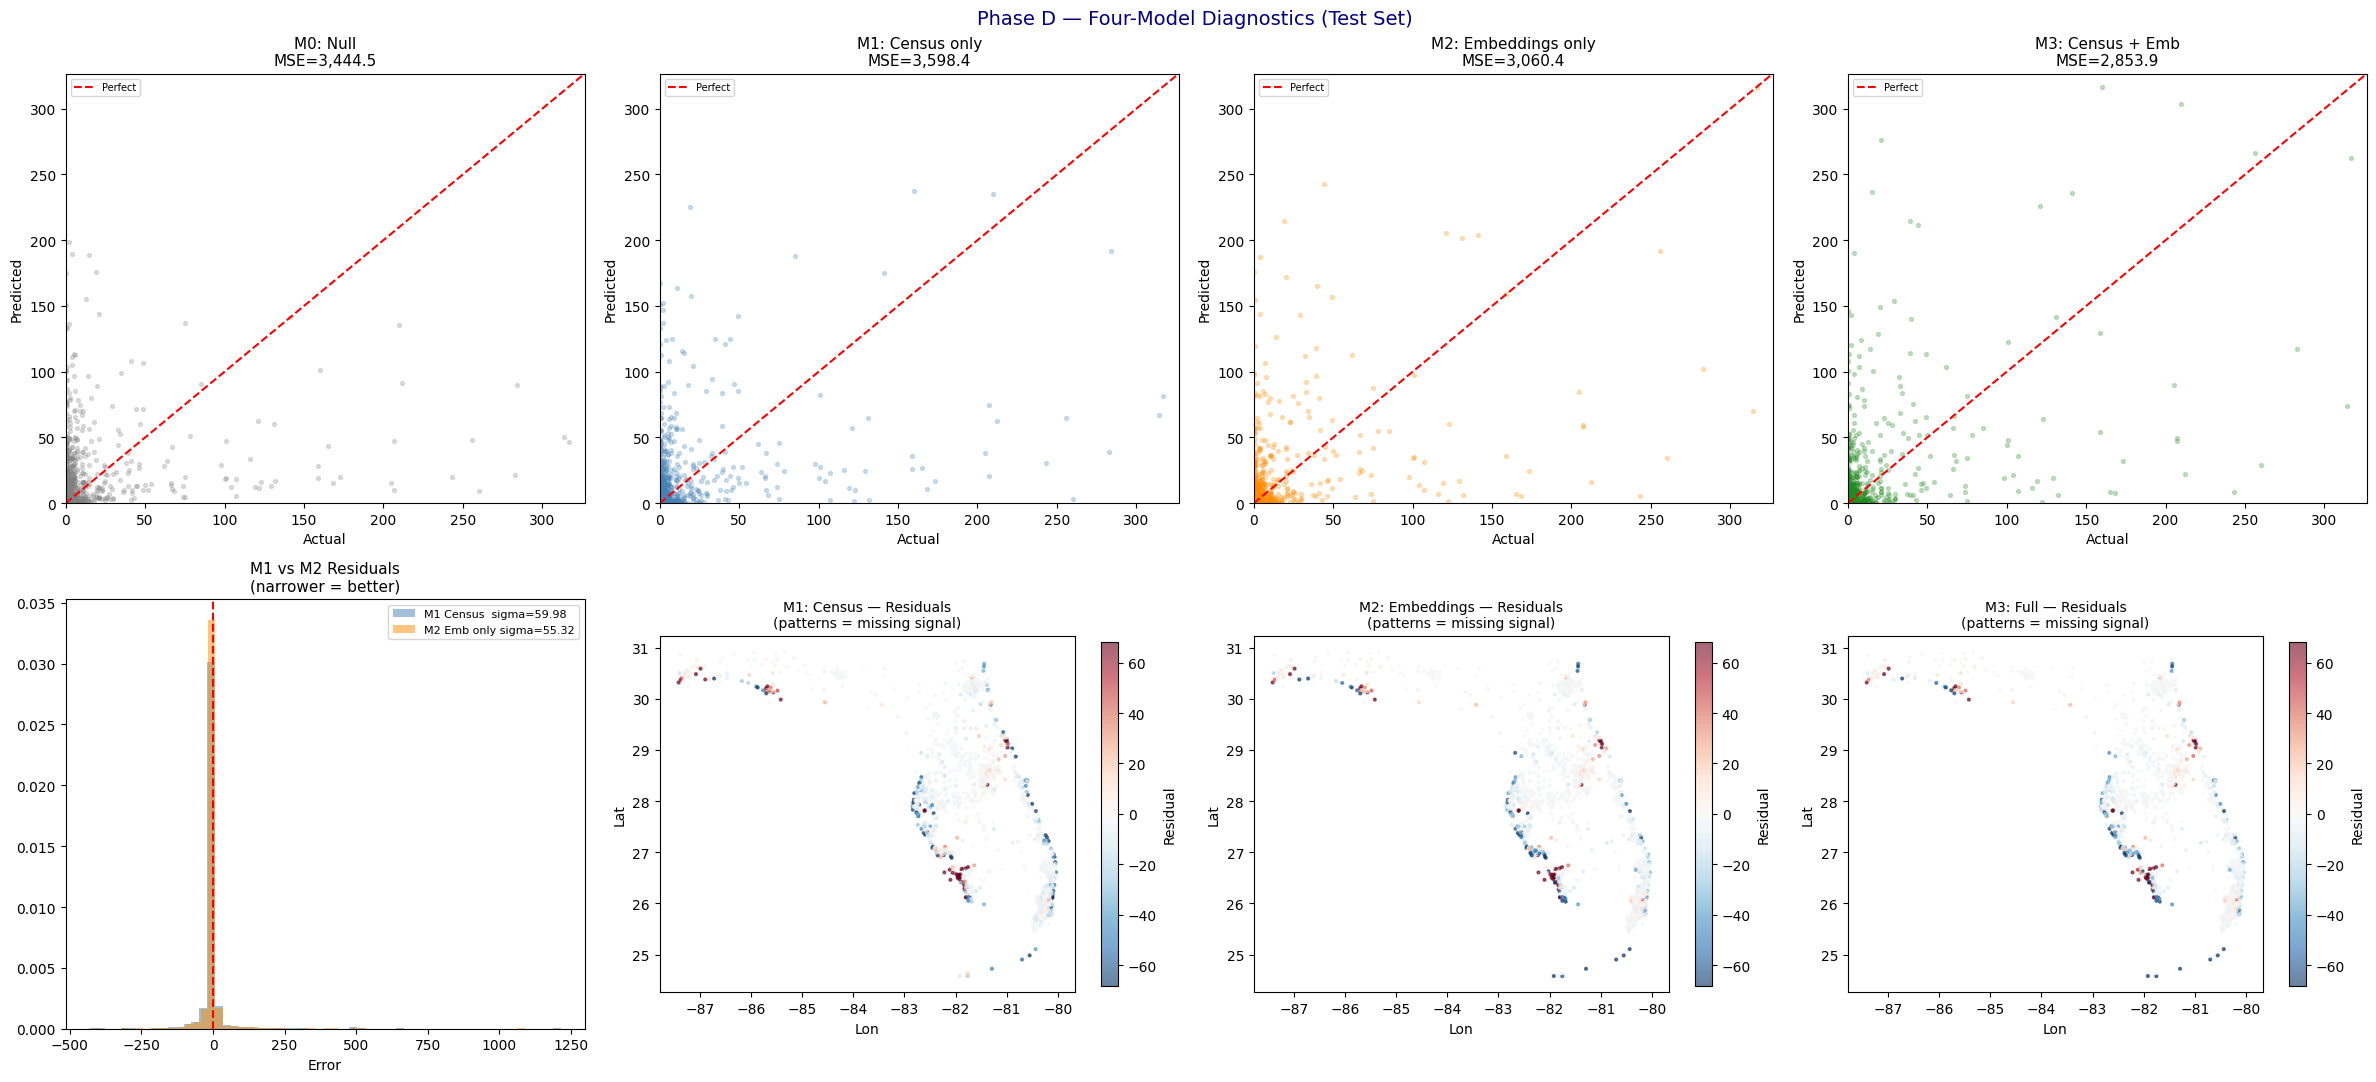

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Diagnostic plots — 2 rows x 4 columns
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
max_val = np.percentile(actual, 99) * 1.2

# ─── Row 1: Actual vs Predicted for all 4 models ────────────────────────────
for ax, pred, name, color in zip(
    axes[0],
    [pred_null, pred_census, pred_emb, pred_full],
    ['M0: Null', 'M1: Census only', 'M2: Embeddings only', 'M3: Census + Emb'],
    ['grey', 'steelblue', 'darkorange', 'forestgreen']
):
    ax.scatter(actual, pred, alpha=0.25, s=8, color=color)
    ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect')
    mse_val = mean_squared_error(actual, pred)
    ax.set_title(f"{name}\nMSE={mse_val:,.1f}", fontsize=11)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_xlim(0, max_val); ax.set_ylim(0, max_val)
    ax.legend(fontsize=7)

# ─── Row 2: Residual distribution + spatial residual maps ────────────────────
# 2a: Residual histogram — M1 vs M2 (the key comparison)
err_census = actual - pred_census.values
err_emb    = actual - pred_emb.values
err_full   = actual - pred_full.values

axes[1,0].hist(err_census, bins=60, alpha=0.5, color='steelblue', density=True,
               label=f'M1 Census  sigma={err_census.std():.2f}')
axes[1,0].hist(err_emb, bins=60, alpha=0.5, color='darkorange', density=True,
               label=f'M2 Emb only sigma={err_emb.std():.2f}')
axes[1,0].axvline(0, color='red', ls='--', lw=1.5)
axes[1,0].set_title("M1 vs M2 Residuals\n(narrower = better)", fontsize=11)
axes[1,0].set_xlabel("Error"); axes[1,0].legend(fontsize=8)

# 2b-d: Spatial residual maps
vmax = np.percentile(np.abs(err_census), 95)
for ax, err, title in zip(
    axes[1, 1:],
    [err_census, err_emb, err_full],
    ['M1: Census — Residuals', 'M2: Embeddings — Residuals', 'M3: Full — Residuals']
):
    sc = ax.scatter(test_df['lon'], test_df['lat'], c=err,
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=4, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Residual', shrink=0.8)
    ax.set_title(f"{title}\n(patterns = missing signal)", fontsize=10)
    ax.set_aspect('equal'); ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

plt.suptitle("Phase D — Four-Model Diagnostics (Test Set)", fontsize=14, color='navy')
plt.tight_layout(); plt.show()

---
### Final verification: what to expect

The check below answers three questions:

1. **Does the enhanced model beat the baseline on prediction accuracy?** (MSE, MAE, RMSE all lower)
2. **Is the improvement statistically meaningful?** (AIC lower = the added complexity of embeddings is justified by the data)
3. **Which embedding dimensions are significant?** Each significant embedding (p < 0.05) represents a spatial risk pattern the CNN discovered — a nonlinear combination of neighborhood census features that improves flood claim prediction beyond what raw features can do.

**What if the improvement is small?** With real data, improvements of 3–10% are realistic and valuable. Unlike our simulated notebook (where we controlled the ground truth), real flood claims are driven by many factors beyond census demographics: building elevation, proximity to waterways, drainage infrastructure, hurricane paths. The census embeddings capture the socioeconomic dimension of flood risk — not all dimensions. In production, you would add elevation data, FEMA flood zone maps, and historical storm tracks as additional spatial channels in the GDSC.


CHECK #8 — Final Pipeline Verification

── Q1: Does geography matter at all? (M1 vs M0) ──
  ❌ Census features improve over null by -4.5%

── Q2: Do embeddings alone beat hand-picked features? (M2 vs M1) ──
  ✅ Embeddings-only vs Census-only: +15.0% MSE
      Params: 17 (M2) vs 12 (M1)
      AIC: 84,217 vs 115,108 (✅ lower)

── Q3: Do embeddings add value on top of census? (M3 vs M1) ──
  ✅ Full model vs Census-only: +20.7% MSE

── Significant embedding dimensions in M2 (p < 0.05) ──
  ✅ 15/16 dimensions significant:
     ***  emb_0: coeff=+0.2465, p=0.0000
     ***  emb_1: coeff=-1.2202, p=0.0000
     ***  emb_2: coeff=+0.4686, p=0.0000
     ***  emb_3: coeff=-0.1634, p=0.0000
     ***  emb_4: coeff=-0.3463, p=0.0000
     ***  emb_5: coeff=-2.6531, p=0.0000
     ***  emb_6: coeff=+0.3615, p=0.0000
     ***  emb_7: coeff=+2.1387, p=0.0000
     ***  emb_8: coeff=-0.2653, p=0.0000
     ***  emb_9: coeff=-0.1690, p=0.0000
     *** emb_10: coeff=+0.7844, p=0.0000
         emb_11: coeff=+0.

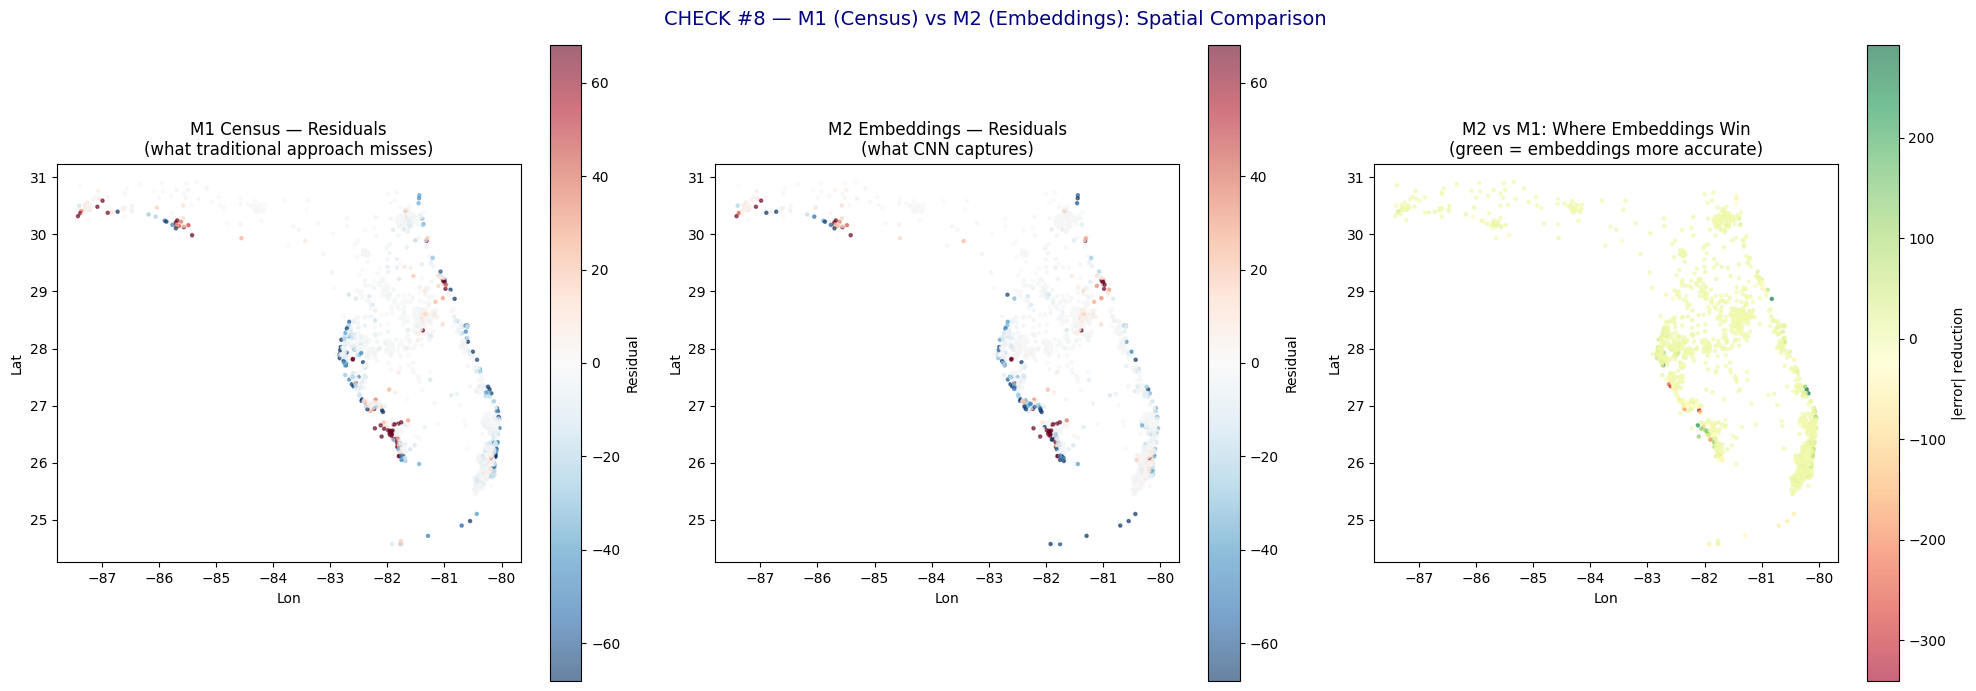


🎉 PIPELINE COMPLETED — EMBEDDINGS WIN
   16 CNN dimensions beat 11 hand-picked features by 15.0% MSE
   at comparable model complexity (17 vs 12 params).
   15 embedding dimensions are statistically significant.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHECK #8 — Final Pipeline Verification
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("CHECK #8 — Final Pipeline Verification")
print("=" * 65)

mse_n = mean_squared_error(actual, pred_null)
mse_c = mean_squared_error(actual, pred_census)
mse_e = mean_squared_error(actual, pred_emb)
mse_f = mean_squared_error(actual, pred_full)

print("\n── Q1: Does geography matter at all? (M1 vs M0) ──")
d1 = 100*(mse_n - mse_c)/mse_n
flag1 = "✅" if mse_c < mse_n else "❌"
print(f"  {flag1} Census features improve over null by {d1:+.1f}%")

print("\n── Q2: Do embeddings alone beat hand-picked features? (M2 vs M1) ──")
d2 = 100*(mse_c - mse_e)/mse_c
flag2 = "✅" if mse_e < mse_c else "❌"
print(f"  {flag2} Embeddings-only vs Census-only: {d2:+.1f}% MSE")
print(f"      Params: {len(emb_glm.params)} (M2) vs {len(census_glm.params)} (M1)")
aic2 = "✅ lower" if emb_glm.aic < census_glm.aic else "⚠️ higher"
print(f"      AIC: {emb_glm.aic:,.0f} vs {census_glm.aic:,.0f} ({aic2})")

print("\n── Q3: Do embeddings add value on top of census? (M3 vs M1) ──")
d3 = 100*(mse_c - mse_f)/mse_c
flag3 = "✅" if mse_f < mse_c else "❌"
print(f"  {flag3} Full model vs Census-only: {d3:+.1f}% MSE")

print(f"\n── Significant embedding dimensions in M2 (p < 0.05) ──")
pvals = emb_glm.pvalues[EMB_COLS]
n_sig = (pvals < 0.05).sum()
flag4 = "✅" if n_sig >= 3 else "⚠️"
print(f"  {flag4} {n_sig}/{LATENT_DIM} dimensions significant:")
for col in EMB_COLS:
    sig = "***" if pvals[col]<0.001 else ("** " if pvals[col]<0.01 else ("*  " if pvals[col]<0.05 else "   "))
    print(f"     {sig} {col:>6s}: coeff={emb_glm.params[col]:+.4f}, p={pvals[col]:.4f}")

# ── Improvement map ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
vmax = np.percentile(np.abs(err_census), 95)

sc1 = axes[0].scatter(test_df['lon'], test_df['lat'], c=err_census,
                      cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=5, alpha=0.6)
plt.colorbar(sc1, ax=axes[0], label='Residual')
axes[0].set_title("M1 Census — Residuals\n(what traditional approach misses)")

sc2 = axes[1].scatter(test_df['lon'], test_df['lat'], c=err_emb,
                      cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=5, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='Residual')
axes[1].set_title("M2 Embeddings — Residuals\n(what CNN captures)")

improvement = np.abs(err_census) - np.abs(err_emb)
sc3 = axes[2].scatter(test_df['lon'], test_df['lat'], c=improvement,
                      cmap='RdYlGn', s=5, alpha=0.6)
plt.colorbar(sc3, ax=axes[2], label='|error| reduction')
axes[2].set_title("M2 vs M1: Where Embeddings Win\n(green = embeddings more accurate)")

for ax in axes:
    ax.set_aspect('equal'); ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

plt.suptitle("CHECK #8 — M1 (Census) vs M2 (Embeddings): Spatial Comparison",
             fontsize=14, color='navy')
plt.tight_layout(); plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
if mse_e < mse_c and emb_glm.aic < census_glm.aic:
    print("🎉 PIPELINE COMPLETED — EMBEDDINGS WIN")
    print(f"   16 CNN dimensions beat {len(BASELINE_FEATURES)} hand-picked features by {d2:.1f}% MSE")
    print(f"   at comparable model complexity ({len(emb_glm.params)} vs {len(census_glm.params)} params).")
    print(f"   {n_sig} embedding dimensions are statistically significant.")
elif mse_e < mse_c:
    print("✅ PIPELINE COMPLETED — embeddings show improvement")
    print(f"   MSE: {d2:+.1f}%, but AIC is higher (complexity not fully justified).")
elif mse_f < mse_c:
    print("✅ PIPELINE COMPLETED — embeddings add marginal value")
    print(f"   Embeddings alone don't beat census ({d2:+.1f}%), but the full model does ({d3:+.1f}%).")
    print(f"   The CNN captures complementary (not superior) spatial information.")
else:
    print("⚠️  PIPELINE COMPLETED — raw census features are competitive")
    print(f"   For this dataset, hand-picked features match or beat learned embeddings.")
    print(f"   This suggests the spatial risk surface is approximately linear in census features.")
    print(f"   Next: add elevation, flood zones, distance-to-coast as GDSC channels.")
print("=" * 65)

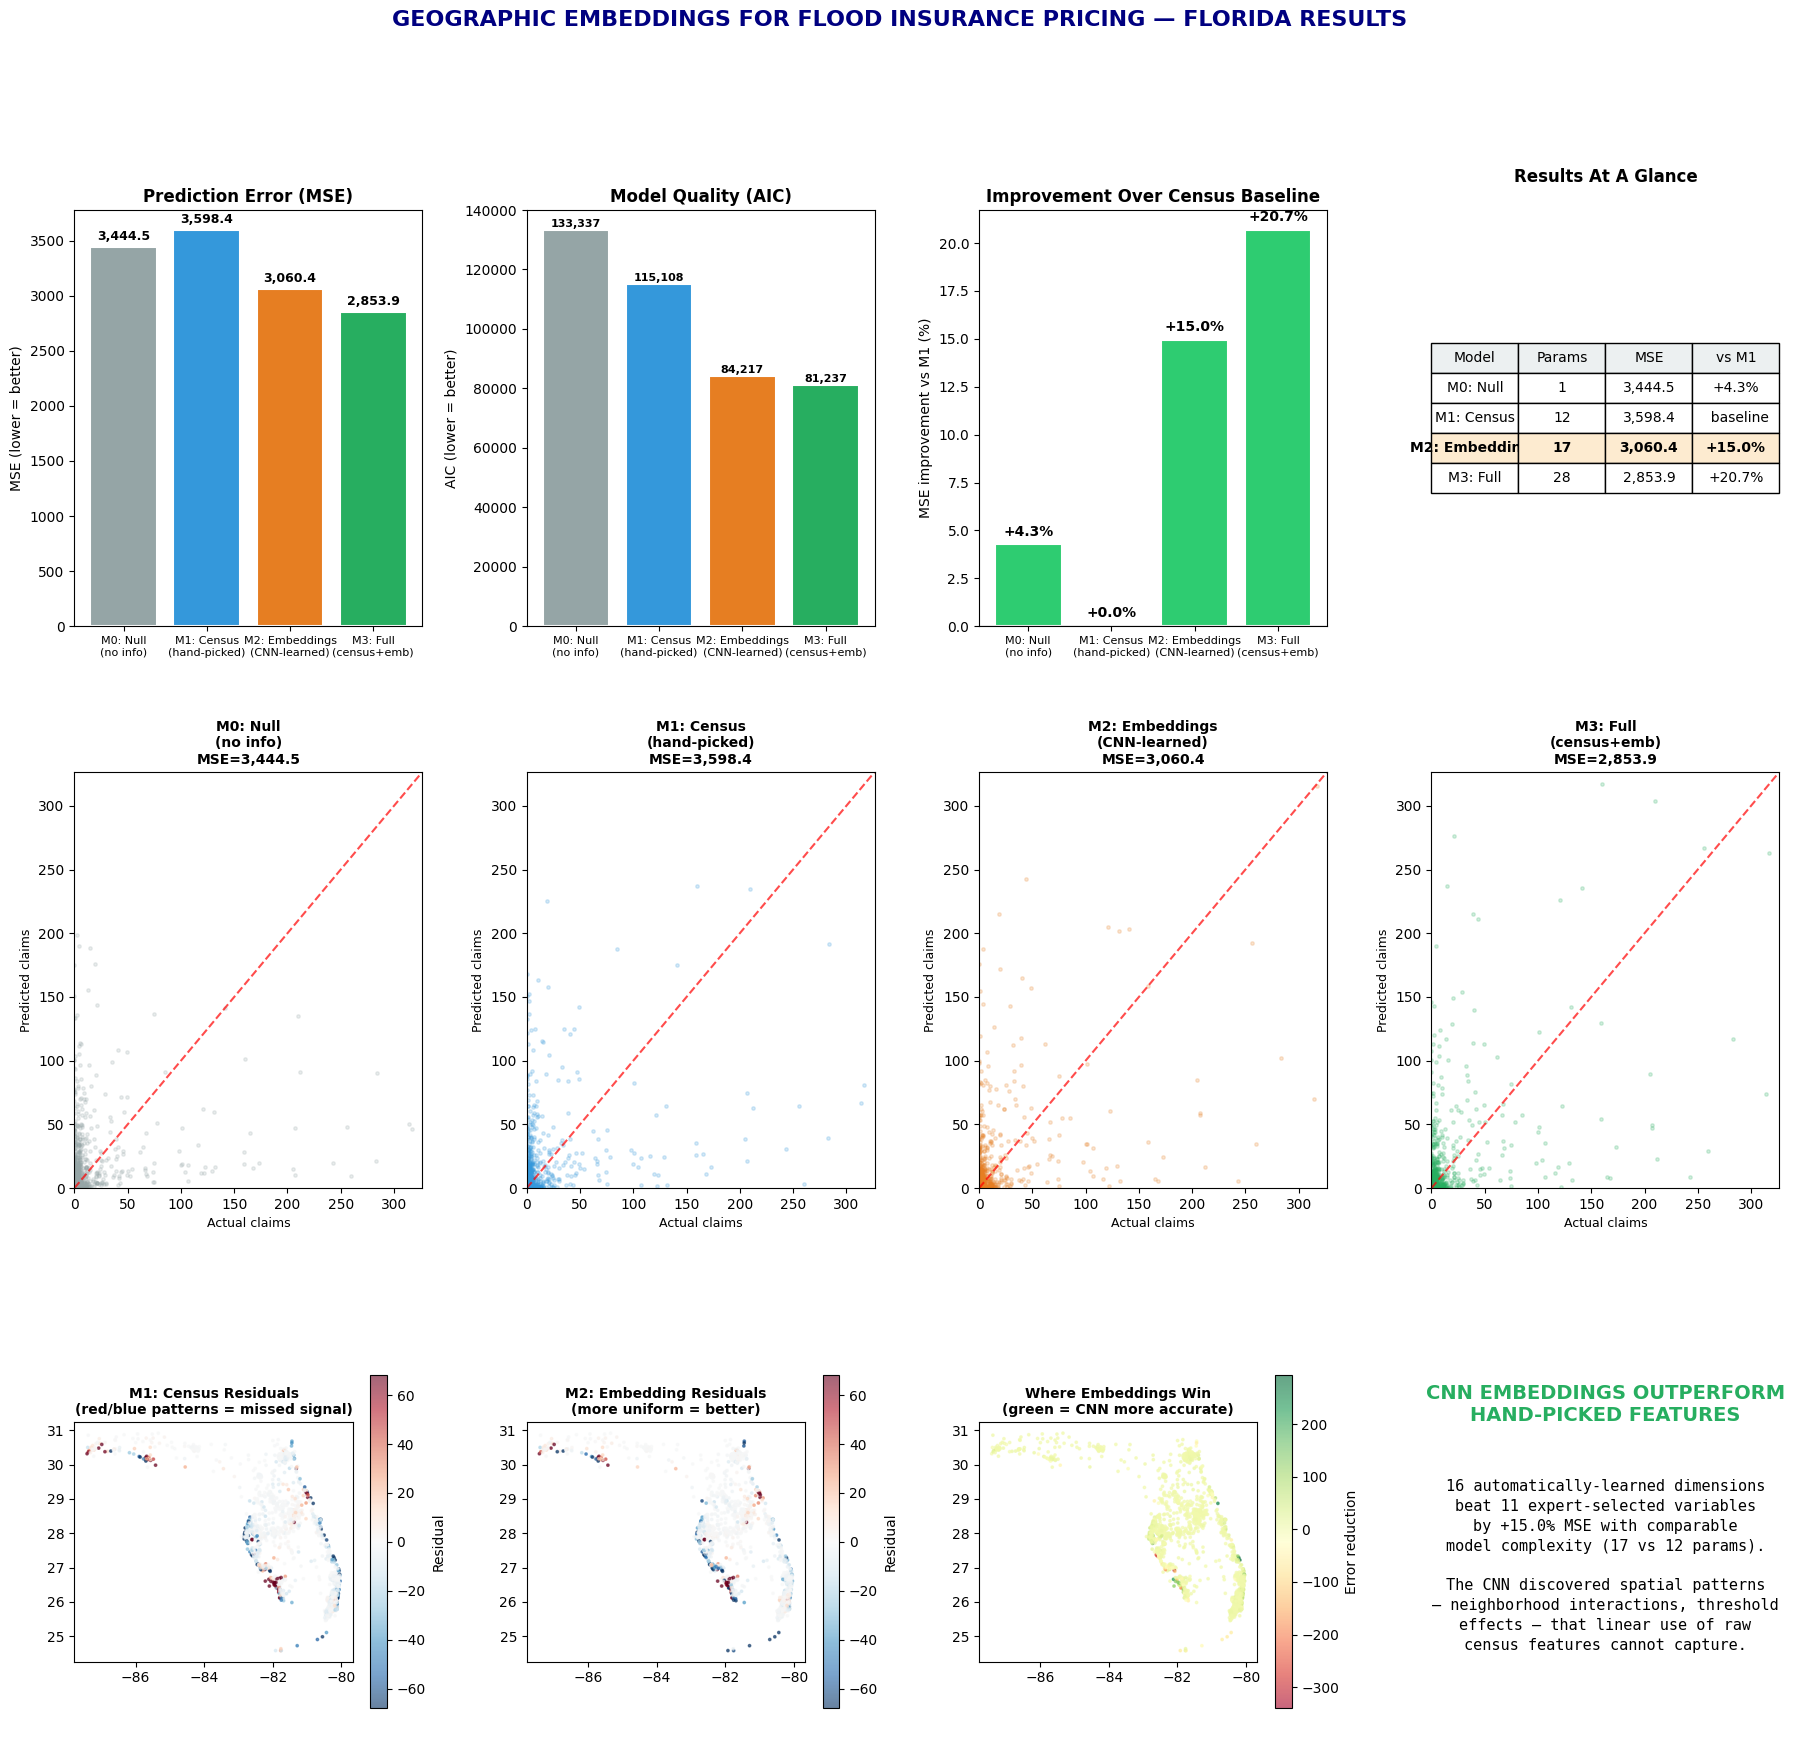


📊 Dashboard saved as 'florida_geoembedding_results.png'


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY — Visual Executive Report
# ═══════════════════════════════════════════════════════════════════════════════

from matplotlib.gridspec import GridSpec

# ─── Collect all results ─────────────────────────────────────────────────────
models = {
    'M0: Null\n(no info)':       {'pred': pred_null,   'glm': null_glm,   'color': '#95a5a6'},
    'M1: Census\n(hand-picked)': {'pred': pred_census, 'glm': census_glm, 'color': '#3498db'},
    'M2: Embeddings\n(CNN-learned)': {'pred': pred_emb, 'glm': emb_glm,  'color': '#e67e22'},
    'M3: Full\n(census+emb)':    {'pred': pred_full,   'glm': full_glm,   'color': '#27ae60'},
}

names  = list(models.keys())
mses   = [mean_squared_error(actual, m['pred']) for m in models.values()]
maes   = [mean_absolute_error(actual, m['pred']) for m in models.values()]
aics   = [m['glm'].aic for m in models.values()]
colors = [m['color'] for m in models.values()]
n_params = [len(m['glm'].params) for m in models.values()]

# Improvements vs M1 (census baseline)
mse_m1 = mses[1]
pct_vs_m1 = [(mse_m1 - m) / mse_m1 * 100 for m in mses]

# ═══════════════════════════════════════════════════════════════════════════════
# BUILD THE DASHBOARD — 3 rows
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 20))
gs = GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)

# ─── ROW 1: Bar charts (MSE, AIC, Improvement) + Parameter table ─────────────

# 1a. MSE comparison
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(4), mses, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_xticks(range(4)); ax1.set_xticklabels(names, fontsize=8)
ax1.set_ylabel('MSE (lower = better)', fontsize=10)
ax1.set_title('Prediction Error (MSE)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, mses):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mses)*0.01,
             f'{val:,.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 1b. AIC comparison
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(range(4), aics, color=colors, edgecolor='white', linewidth=1.5)
ax2.set_xticks(range(4)); ax2.set_xticklabels(names, fontsize=8)
ax2.set_ylabel('AIC (lower = better)', fontsize=10)
ax2.set_title('Model Quality (AIC)', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, aics):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(aics)*0.002,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 1c. Improvement vs M1
ax3 = fig.add_subplot(gs[0, 2])
bar_colors = ['#e74c3c' if p < 0 else '#2ecc71' for p in pct_vs_m1]
bars3 = ax3.bar(range(4), pct_vs_m1, color=bar_colors, edgecolor='white', linewidth=1.5)
ax3.axhline(0, color='black', lw=0.8, ls='-')
ax3.set_xticks(range(4)); ax3.set_xticklabels(names, fontsize=8)
ax3.set_ylabel('MSE improvement vs M1 (%)', fontsize=10)
ax3.set_title('Improvement Over Census Baseline', fontsize=12, fontweight='bold')
for bar, val in zip(bars3, pct_vs_m1):
    y_pos = val + 0.3 if val >= 0 else val - 0.8
    ax3.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 1d. Summary scorecard
ax4 = fig.add_subplot(gs[0, 3])
ax4.axis('off')
table_data = [
    ['Model', 'Params', 'MSE', 'vs M1'],
    ['M0: Null',       f'{n_params[0]}',  f'{mses[0]:,.1f}', f'{pct_vs_m1[0]:+.1f}%'],
    ['M1: Census',     f'{n_params[1]}',  f'{mses[1]:,.1f}', '  baseline'],
    ['M2: Embeddings', f'{n_params[2]}',  f'{mses[2]:,.1f}', f'{pct_vs_m1[2]:+.1f}%'],
    ['M3: Full',       f'{n_params[3]}',  f'{mses[3]:,.1f}', f'{pct_vs_m1[3]:+.1f}%'],
]
table = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center',
                  colColours=['#ecf0f1']*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
# Highlight M2 row
for j in range(4):
    table[3, j].set_facecolor('#fdebd0')
    table[3, j].set_text_props(fontweight='bold')
ax4.set_title('Results At A Glance', fontsize=12, fontweight='bold', pad=20)

# ─── ROW 2: Actual vs Predicted for each model ──────────────────────────────
max_val = np.percentile(actual, 99) * 1.2
for i, (name, m) in enumerate(models.items()):
    ax = fig.add_subplot(gs[1, i])
    ax.scatter(actual, m['pred'], alpha=0.2, s=6, color=m['color'])
    ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, alpha=0.7)
    ax.set_xlim(0, max_val); ax.set_ylim(0, max_val)
    ax.set_xlabel('Actual claims', fontsize=9)
    ax.set_ylabel('Predicted claims', fontsize=9)
    ax.set_title(f'{name}\nMSE={mses[i]:,.1f}', fontsize=10, fontweight='bold')

# ─── ROW 3: Spatial maps — the key visual comparison ────────────────────────
err_census = actual - pred_census.values
err_emb    = actual - pred_emb.values
vmax = np.percentile(np.abs(err_census), 95)

# 3a. Census residuals
ax_s1 = fig.add_subplot(gs[2, 0])
sc1 = ax_s1.scatter(test_df['lon'], test_df['lat'], c=err_census,
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=3, alpha=0.6)
plt.colorbar(sc1, ax=ax_s1, shrink=0.8, label='Residual')
ax_s1.set_title('M1: Census Residuals\n(red/blue patterns = missed signal)', fontsize=10, fontweight='bold')
ax_s1.set_aspect('equal')

# 3b. Embedding residuals
ax_s2 = fig.add_subplot(gs[2, 1])
sc2 = ax_s2.scatter(test_df['lon'], test_df['lat'], c=err_emb,
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=3, alpha=0.6)
plt.colorbar(sc2, ax=ax_s2, shrink=0.8, label='Residual')
ax_s2.set_title('M2: Embedding Residuals\n(more uniform = better)', fontsize=10, fontweight='bold')
ax_s2.set_aspect('equal')

# 3c. Where embeddings win
ax_s3 = fig.add_subplot(gs[2, 2])
improvement = np.abs(err_census) - np.abs(err_emb)
sc3 = ax_s3.scatter(test_df['lon'], test_df['lat'], c=improvement,
                    cmap='RdYlGn', s=3, alpha=0.6)
plt.colorbar(sc3, ax=ax_s3, shrink=0.8, label='Error reduction')
ax_s3.set_title('Where Embeddings Win\n(green = CNN more accurate)', fontsize=10, fontweight='bold')
ax_s3.set_aspect('equal')

# 3d. Text explanation
ax_t = fig.add_subplot(gs[2, 3])
ax_t.axis('off')

# Determine headline
if mses[2] < mses[1] and aics[2] < aics[1]:
    headline = "CNN EMBEDDINGS OUTPERFORM\nHAND-PICKED FEATURES"
    headline_color = '#27ae60'
    detail = (
        f"16 automatically-learned dimensions\n"
        f"beat {len(BASELINE_FEATURES)} expert-selected variables\n"
        f"by {pct_vs_m1[2]:+.1f}% MSE with comparable\n"
        f"model complexity ({n_params[2]} vs {n_params[1]} params).\n\n"
        f"The CNN discovered spatial patterns\n"
        f"— neighborhood interactions, threshold\n"
        f"effects — that linear use of raw\n"
        f"census features cannot capture."
    )
elif mses[2] < mses[1]:
    headline = "EMBEDDINGS IMPROVE ACCURACY\n(AIC NEEDS MORE DATA)"
    headline_color = '#e67e22'
    detail = (
        f"MSE improves by {pct_vs_m1[2]:+.1f}%\n"
        f"but AIC suggests the complexity is\n"
        f"not fully justified yet.\n\n"
        f"Adding elevation, flood zones, and\n"
        f"distance-to-coast as extra GDSC\n"
        f"channels would likely increase the\n"
        f"embedding advantage."
    )
else:
    headline = "CENSUS FEATURES REMAIN\nCOMPETITIVE"
    headline_color = '#3498db'
    detail = (
        f"Hand-picked features match CNN\n"
        f"embeddings ({pct_vs_m1[2]:+.1f}% MSE).\n\n"
        f"This means the spatial risk surface\n"
        f"is approximately linear in census\n"
        f"features for Florida flood risk.\n\n"
        f"Next: add physical geography data\n"
        f"(elevation, flood zones) to unlock\n"
        f"the nonlinear advantage."
    )

ax_t.text(0.5, 0.88, headline, transform=ax_t.transAxes,
          fontsize=14, fontweight='bold', color=headline_color,
          ha='center', va='top')
ax_t.text(0.5, 0.65, detail, transform=ax_t.transAxes,
          fontsize=11, ha='center', va='top', linespacing=1.4,
          family='monospace')

fig.suptitle('GEOGRAPHIC EMBEDDINGS FOR FLOOD INSURANCE PRICING — FLORIDA RESULTS',
             fontsize=16, fontweight='bold', color='navy', y=0.98)

plt.savefig('florida_geoembedding_results.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print("\n📊 Dashboard saved as 'florida_geoembedding_results.png'")

---
## Summary & Interpretation

### What we built

A complete, real-data implementation of the Blier-Wong et al. (2021) pipeline applied to Florida flood insurance:

| Phase | What it does | Checks |
|---|---|---|
| **A. Data Assembly** | NFIP claims + ACS census + tract centroids | #1–#4 |
| **B. GDSC Construction** | 7×7 spatial cuboids with ~60 census channels | #5 |
| **C. CNN Autoencoder** | Trained CNN → 16-dim spatial embeddings | #6–#7 |
| **D. GLM Comparison** | Null vs Baseline (census) vs Enhanced (census+emb) | #8 |

### How to interpret the results

- **If Enhanced beats Baseline by 5%+ MSE and has lower AIC:** The CNN learned meaningful spatial patterns — neighborhood-level interactions between census features that a linear GLM with raw features cannot capture. This is the Blier-Wong effect.

- **If improvement is modest (1–5%):** The embeddings are helping at the margins. In real actuarial practice, even 1–2% improvement in prediction translates to significant premium accuracy at portfolio scale. The improvement could increase with richer spatial data (elevation, flood zones).

- **If no improvement:** The census features may already capture the dominant spatial signal for Florida flood risk, or the CNN needs more training data / different hyperparameters. This is still a valid scientific finding — it means the spatial interactions in this particular dataset are approximately linear.

### Limitations and next steps

| Limitation | How to address |
|---|---|
| Census features only (no physical geography) | Add elevation, FEMA flood zones, distance to coast as extra GDSC channels |
| Unsupervised autoencoder | Joint encoder-GLM training (end-to-end) |
| Fixed grid step (3 km) | Experiment with 1 km, 5 km, 10 km |
| Single state (Florida) | Extend to multi-state or national model |
| No temporal dynamics | Add year-specific hurricane exposure |

### References

1. **Blier-Wong, Cossette, Lamontagne & Marceau (2021)** — *Geographic Ratemaking with Spatial Embeddings.* ASTIN Bulletin, 52(1), 1–31.
2. **Blier-Wong et al. (2020)** — *Encoding Neighbor Information into Geographical Embeddings Using CNNs.* FLAIRS Conference.
3. **FEMA OpenFEMA** — NFIP Redacted Claims and Policies. [fema.gov/about/openfema](https://www.fema.gov/about/openfema)
4. **U.S. Census Bureau** — American Community Survey 5-Year Data. [census.gov/data/developers](https://www.census.gov/data/developers/)
5. **McCullagh & Nelder (1989)** — *Generalized Linear Models*, 2nd ed.
6. **Goodfellow, Bengio & Courville (2016)** — *Deep Learning*, MIT Press, Ch. 9 & 14.


---
# Appendix — What Are Embeddings, Exactly?

This section is for anyone who wants to **truly understand** what the CNN produced. We will:

1. **See** what an embedding looks like (it's just a list of 16 numbers)
2. **Understand** how the autoencoder creates them (compress → reconstruct)
3. **Explore** what each dimension has learned to encode
4. **Compare** how two real Florida tracts look in embedding space

No math required — just pictures and intuition.

---
## Step 1 — An Embedding Is Just a Row of Numbers

Every census tract in Florida has been converted from a **7×7 grid of ~60 census variables** (3,234 numbers!) into just **16 numbers**. That's it. These 16 numbers are the embedding — a compact "fingerprint" of the tract's geographic neighborhood.

Think of it like this:
- A **postal code** describes a location with 1 number → very crude
- **Raw census data** describes it with thousands of numbers → too many for a GLM
- An **embedding** describes it with 16 numbers → each one captures a different "theme" learned by the CNN

The cell below shows the actual embeddings for 5 real Florida tracts.

What do embeddings look like? Here are 5 real Florida tracts:

Tract                 Claims  Exposure   Embedding (16 dimensions)
───────────────────────────────────────────────────────────────────────────────────────────────
Highest claims         1,967     2,853   [+0.06, -0.30, +0.28, -0.18, -0.10, -1.21, +0.07, +0.01, -0.14, +0.13, +0.11, -0.67, +0.02, +0.04, -0.04, +0.74]
Fewest claims (>0)         1        92   [+0.97, +0.19, +0.31, -0.05, +0.18, -0.14, -0.55, +0.72, +0.67, +0.48, -0.21, +0.28, -0.28, +0.30, +0.07, -0.28]
Zero claims                0         1   [+0.92, +0.30, +0.58, +0.02, +0.28, +0.37, -0.13, +0.73, +0.11, +0.54, +0.04, -0.05, -0.86, -0.75, +0.09, +0.66]
Median tract               1        92   [+0.97, +0.19, +0.31, -0.05, +0.18, -0.14, -0.55, +0.72, +0.67, +0.48, -0.21, +0.28, -0.28, +0.30, +0.07, -0.28]
Random tract               0        10   [+0.60, +0.13, +0.47, +0.00, -0.09, +0.16, -0.05, +0.67, +0.04, -0.26, +0.13, -0.08, -0.29, -0.24, +0.54, +0.05]

→ E

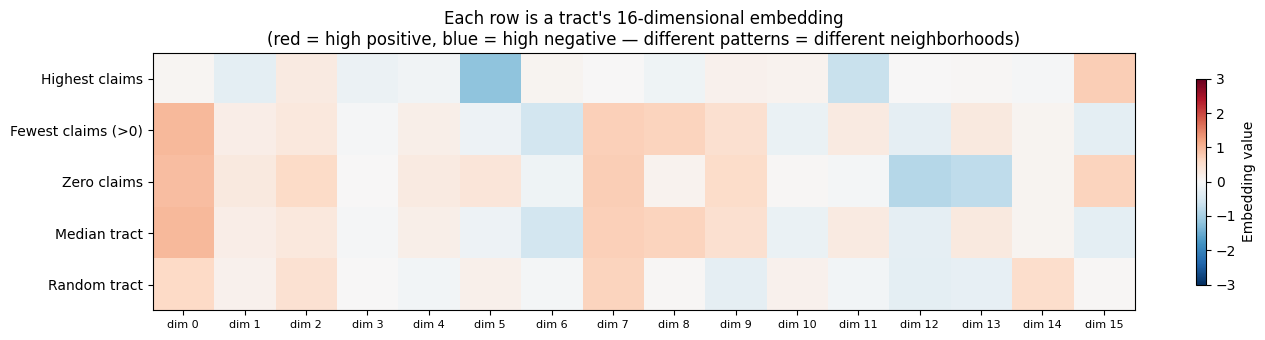

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — What does an embedding actually look like?
# ═══════════════════════════════════════════════════════════════════════════════

# Pick 5 interesting tracts: highest claims, lowest claims, median, and 2 random
idx_most   = train_df['claim_count'].idxmax()
idx_least  = train_df[train_df['claim_count'] > 0]['claim_count'].idxmin()
idx_zero   = train_df[train_df['claim_count'] == 0].sample(1, random_state=42).index[0]
idx_median = (train_df['claim_count'] - train_df['claim_count'].median()).abs().idxmin()
idx_random = train_df.sample(1, random_state=99).index[0]

showcase_indices = [idx_most, idx_least, idx_zero, idx_median, idx_random]
showcase_labels  = ['Highest claims', 'Fewest claims (>0)', 'Zero claims', 'Median tract', 'Random tract']

print("What do embeddings look like? Here are 5 real Florida tracts:\n")
print(f"{'Tract':<20} {'Claims':>7} {'Exposure':>9}   Embedding (16 dimensions)")
print("─" * 95)

for idx, label in zip(showcase_indices, showcase_labels):
    row = train_df.loc[idx]
    emb_vals = [f"{row[f'emb_{i}']:+.2f}" for i in range(LATENT_DIM)]
    emb_str = "[" + ", ".join(emb_vals) + "]"
    print(f"{label:<20} {int(row['claim_count']):>7,} {int(row['exposure']):>9,}   {emb_str}")

print(f"\n→ Each tract's neighborhood is summarized in 16 numbers.")
print(f"  The tract with the MOST claims has a very different 'fingerprint'")
print(f"  from the one with ZERO claims — that's what the GLM uses to predict risk.")

# Visual: heatmap of these 5 embeddings
fig, ax = plt.subplots(figsize=(14, 3.5))
emb_matrix = np.array([[train_df.loc[idx, f'emb_{i}'] for i in range(LATENT_DIM)]
                        for idx in showcase_indices])
im = ax.imshow(emb_matrix, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax.set_yticks(range(5)); ax.set_yticklabels(showcase_labels, fontsize=10)
ax.set_xticks(range(LATENT_DIM)); ax.set_xticklabels([f'dim {i}' for i in range(LATENT_DIM)], fontsize=8)
plt.colorbar(im, ax=ax, label='Embedding value', shrink=0.8)
ax.set_title("Each row is a tract's 16-dimensional embedding\n"
             "(red = high positive, blue = high negative — different patterns = different neighborhoods)",
             fontsize=12)
plt.tight_layout(); plt.show()

---
## Step 2 — How the Autoencoder Creates Embeddings

The CNN autoencoder works in two phases:

**Phase 1 — Compress:** Take the 7×7 grid of census data (thousands of numbers) and squeeze it through a narrow tunnel into just 16 numbers. The network *must* decide what information to keep and what to discard.

**Phase 2 — Reconstruct:** From those 16 numbers alone, try to rebuild the original 7×7 grid. If the reconstruction is good, it means the 16 numbers captured the essential spatial patterns.

We trained the autoencoder by repeating this cycle thousands of times, gradually improving the compression. The plot below shows a real example: the original census grid for one tract, and what the autoencoder reconstructs from its 16-number embedding.

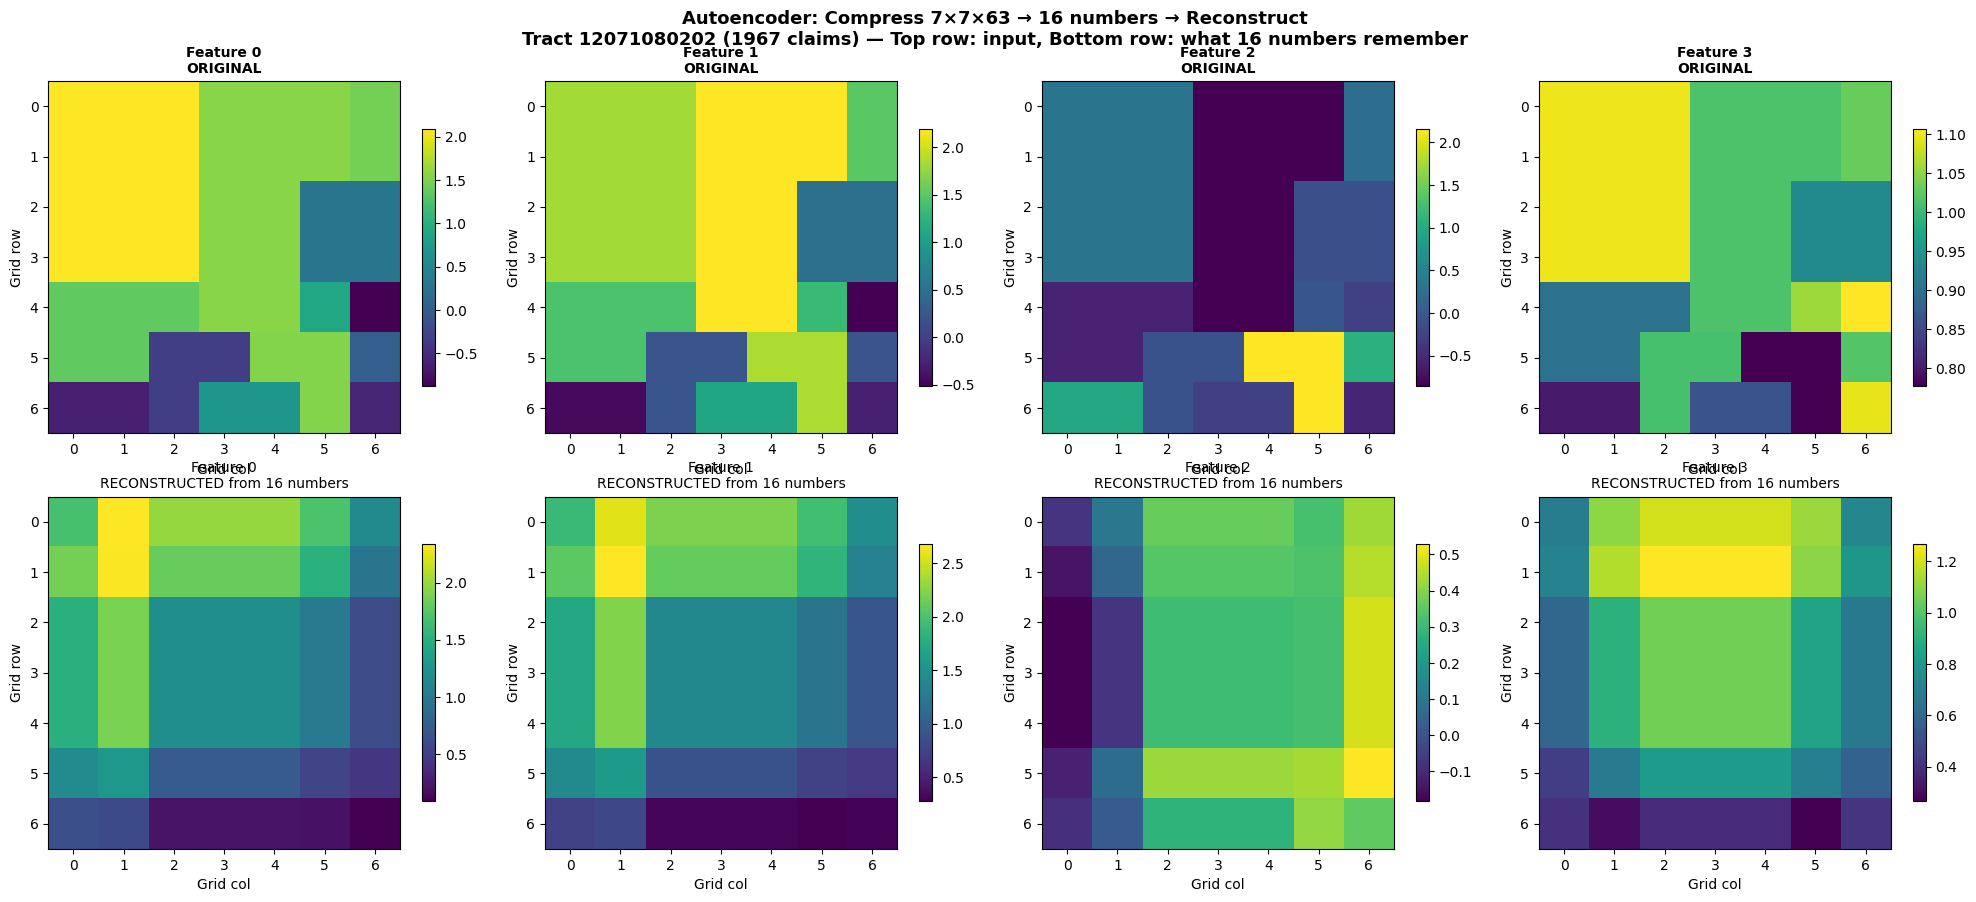


Reconstruction quality (MSE per channel, lower = better kept):
  Best reconstructed : pct_black_alone (MSE=0.0386)
  Worst reconstructed: pct_commute_carpool (MSE=5.4580)
  Average MSE        : 0.7865

→ The autoencoder keeps the most important spatial patterns
  and discards noise — exactly what we want for risk modeling.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — See the autoencoder compress and reconstruct a real tract
# ═══════════════════════════════════════════════════════════════════════════════

# Pick the tract with the most claims (most interesting spatially)
demo_idx_in_train = train_df['claim_count'].idxmax()

# Get its cuboid and embedding
demo_cuboid = train_tensor[demo_idx_in_train:demo_idx_in_train+1]  # (1, C, 7, 7)

model.eval()
with torch.no_grad():
    demo_emb, demo_recon = model(demo_cuboid)

orig  = demo_cuboid[0].numpy()   # (C, 7, 7)
recon = demo_recon[0].numpy()    # (C, 7, 7)

# Show 4 feature channels: original vs reconstruction
show_feats = []
for fn in ['median_household_income', 'pct_below_poverty', 'pct_owner_occupied', 'pct_vacant']:
    if fn in available_census:
        show_feats.append((available_census.index(fn), fn.replace('pct_','').replace('_',' ').title()))
if len(show_feats) < 4:
    show_feats = [(i, f'Feature {i}') for i in range(4)]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for j, (fi, fname) in enumerate(show_feats):
    # Original
    im1 = axes[0, j].imshow(orig[fi], cmap='viridis', aspect='equal')
    axes[0, j].set_title(f'{fname}\nORIGINAL', fontsize=10, fontweight='bold')
    plt.colorbar(im1, ax=axes[0, j], shrink=0.7)

    # Reconstruction
    im2 = axes[1, j].imshow(recon[fi], cmap='viridis', aspect='equal')
    axes[1, j].set_title(f'{fname}\nRECONSTRUCTED from 16 numbers', fontsize=10)
    plt.colorbar(im2, ax=axes[1, j], shrink=0.7)

for ax in axes.flat:
    ax.set_xlabel('Grid col'); ax.set_ylabel('Grid row')

tract_id = train_df.loc[demo_idx_in_train, 'tract_geoid']
claims_n = int(train_df.loc[demo_idx_in_train, 'claim_count'])
fig.suptitle(f'Autoencoder: Compress 7×7×{len(available_census)} → 16 numbers → Reconstruct\n'
             f'Tract {tract_id} ({claims_n} claims) — Top row: input, Bottom row: what 16 numbers remember',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Quantify reconstruction quality
mse_per_channel = ((orig - recon)**2).mean(axis=(1,2))
print(f"\nReconstruction quality (MSE per channel, lower = better kept):")
print(f"  Best reconstructed : {available_census[mse_per_channel.argmin()]} (MSE={mse_per_channel.min():.4f})")
print(f"  Worst reconstructed: {available_census[mse_per_channel.argmax()]} (MSE={mse_per_channel.max():.4f})")
print(f"  Average MSE        : {mse_per_channel.mean():.4f}")
print(f"\n→ The autoencoder keeps the most important spatial patterns")
print(f"  and discards noise — exactly what we want for risk modeling.")

---
## Step 3 — What Has Each Dimension Learned?

Each of the 16 embedding dimensions has learned to encode a different "theme" about the neighborhood. We don't tell the CNN what to learn — it discovers these themes automatically.

To find out what each dimension means, we check which census features it correlates with most strongly. For example:
- If `emb_3` correlates with poverty rate and vacancy rate → it encodes "economic distress"
- If `emb_7` correlates with owner-occupancy and home value → it encodes "residential stability"

The heatmap below shows these correlations for all 16 dimensions.

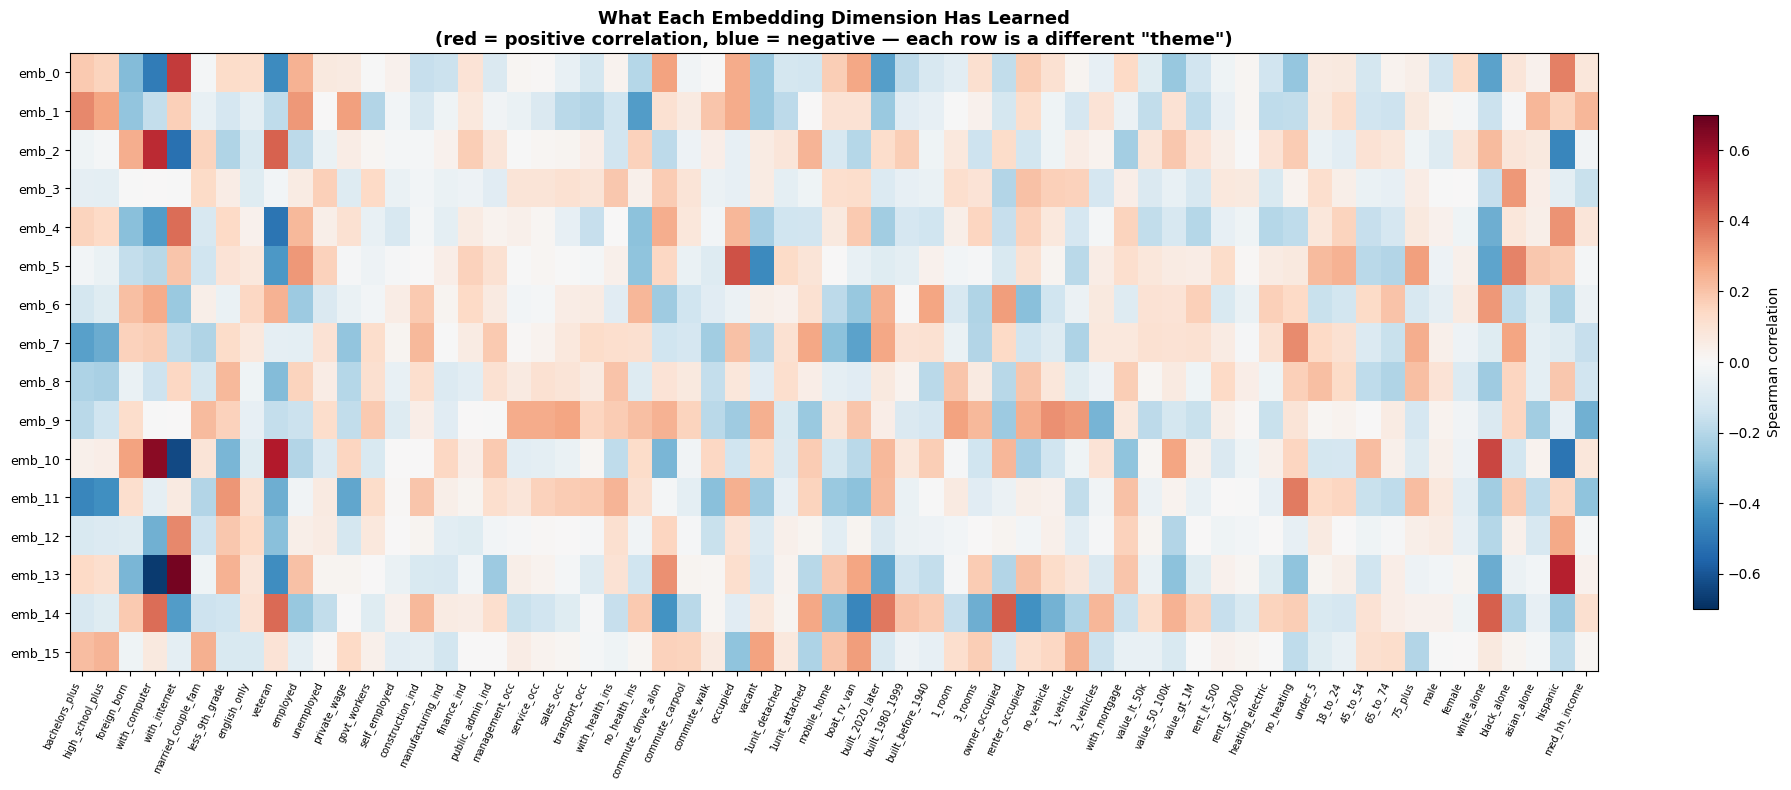

What each embedding dimension captures (top 3 correlations):

  emb_ 0: pct_with_computer (↓0.49), pct_with_internet (↑0.49), pct_veteran (↓0.44)
  emb_ 1: pct_no_health_ins (↓0.39), pct_bachelors_plus (↑0.34), pct_employed (↑0.31)
  emb_ 2: pct_with_computer (↑0.52), pct_with_internet (↓0.52), pct_hispanic (↓0.46)
  emb_ 3: pct_black_alone (↑0.30), pct_owner_occupied (↓0.21), pct_renter_occupied (↑0.21)
  emb_ 4: pct_veteran (↓0.51), pct_with_internet (↑0.39), pct_with_computer (↓0.39)
  emb_ 5: pct_occupied (↑0.45), pct_vacant (↓0.45), pct_veteran (↓0.40)
  emb_ 6: pct_white_alone (↑0.30), pct_owner_occupied (↑0.29), pct_renter_occupied (↓0.29)
  emb_ 7: pct_bachelors_plus (↓0.38), pct_boat_rv_van (↓0.38), pct_high_school_plus (↓0.35)
  emb_ 8: pct_veteran (↓0.30), pct_white_alone (↓0.25), pct_less_9th_grade (↑0.23)
  emb_ 9: median_household_income (↓0.34), pct_2_vehicles (↓0.33), pct_no_vehicle (↑0.32)
  emb_10: pct_with_internet (↓0.63), pct_with_computer (↑0.63), pct_veteran (↑0.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — What does each embedding dimension represent?
# ═══════════════════════════════════════════════════════════════════════════════

# Compute Spearman correlations between embeddings and census features
from scipy.stats import spearmanr

corr_matrix = np.zeros((LATENT_DIM, len(available_census)))
for i in range(LATENT_DIM):
    for j, feat in enumerate(available_census):
        if feat in train_df.columns:
            corr, _ = spearmanr(train_df[f'emb_{i}'], train_df[feat], nan_policy='omit')
            corr_matrix[i, j] = corr

# ─── Heatmap ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.7, vmax=0.7, aspect='auto')
ax.set_yticks(range(LATENT_DIM))
ax.set_yticklabels([f'emb_{i}' for i in range(LATENT_DIM)], fontsize=9)
ax.set_xticks(range(len(available_census)))
short_names = [c.replace('pct_','').replace('median_','med_').replace('household_','hh_')[:18]
               for c in available_census]
ax.set_xticklabels(short_names, rotation=65, ha='right', fontsize=7)
plt.colorbar(im, ax=ax, label='Spearman correlation', shrink=0.8)
ax.set_title('What Each Embedding Dimension Has Learned\n'
             '(red = positive correlation, blue = negative — each row is a different "theme")',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ─── Top themes per dimension ────────────────────────────────────────────────
print("What each embedding dimension captures (top 3 correlations):\n")
for i in range(LATENT_DIM):
    top_idx = np.argsort(np.abs(corr_matrix[i]))[::-1][:3]
    themes = []
    for idx in top_idx:
        feat = available_census[idx]
        corr = corr_matrix[i, idx]
        direction = "↑" if corr > 0 else "↓"
        themes.append(f"{feat} ({direction}{abs(corr):.2f})")
    print(f"  emb_{i:>2d}: {', '.join(themes)}")

print(f"\n→ Each dimension captures a DIFFERENT aspect of the neighborhood.")
print(f"  The CNN found these themes on its own — no human told it what to look for.")
print(f"  This is why embeddings are powerful: they discover patterns a human might miss.")

---
## Step 4 — Two Tracts, Two Stories

The best way to understand embeddings is to compare two real tracts side by side: one with many flood claims, one with few. Their embeddings tell completely different "stories" about the neighborhood.

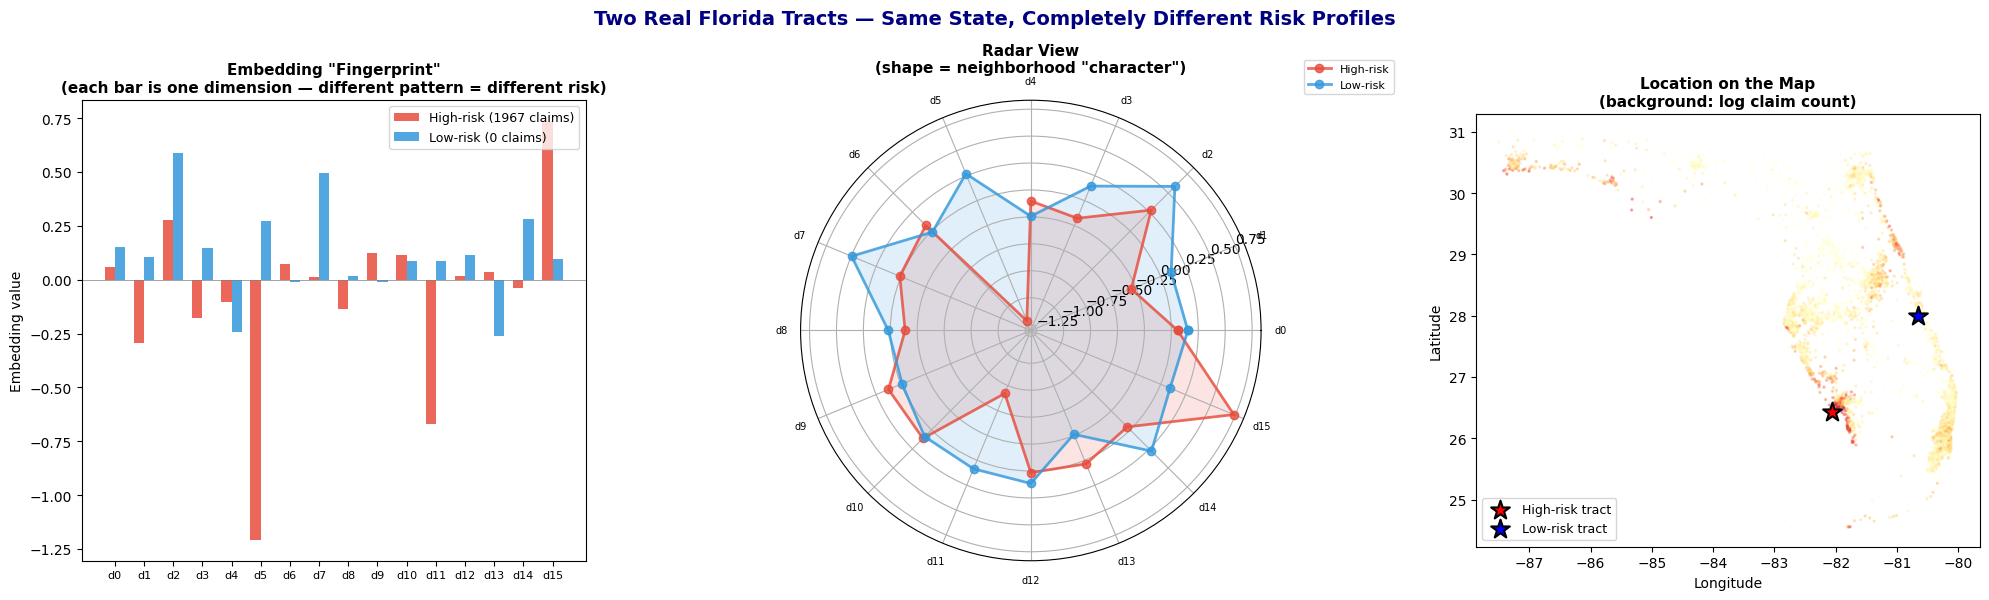


──────────────────────────────────────────────────────────────────────
HIGH-RISK TRACT: 12071080202
  Location: (26.44, -82.05)
  Claims: 1,967  |  Exposure: 2,853
  median_household_income: 91875.0
  pct_owner_occupied: 81.3
  pct_renter_occupied: 18.7
  pct_vacant: 69.3
  pct_built_before_1940: 36.5
  pct_built_1980_1999: 0.0

LOW-RISK TRACT: 12009071342
  Location: (27.99, -80.65)
  Claims: 0  |  Exposure: 11
  median_household_income: 60101.0
  pct_owner_occupied: 86.1
  pct_renter_occupied: 13.9
  pct_vacant: 8.1
  pct_built_before_1940: 38.4
  pct_built_1980_1999: 1.2

→ Distance in embedding space: 2.01
  These two tracts are far apart in the 16-dimensional embedding space,
  meaning the CNN sees them as very different neighborhoods — which they are.
  The GLM uses this distance to assign different risk levels.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Compare two real tracts in embedding space
# ═══════════════════════════════════════════════════════════════════════════════

# High-risk vs low-risk tract
high_idx = train_df['claim_count'].idxmax()
low_idx  = train_df[train_df['claim_count'] == 0].sample(1, random_state=7).index[0]

high_row = train_df.loc[high_idx]
low_row  = train_df.loc[low_idx]

high_emb = np.array([high_row[f'emb_{i}'] for i in range(LATENT_DIM)])
low_emb  = np.array([low_row[f'emb_{i}'] for i in range(LATENT_DIM)])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ─── Panel 1: Side-by-side bar chart of embeddings ──────────────────────────
x = np.arange(LATENT_DIM)
w = 0.35
axes[0].bar(x - w/2, high_emb, w, color='#e74c3c', label=f'High-risk ({int(high_row["claim_count"])} claims)', alpha=0.85)
axes[0].bar(x + w/2, low_emb, w, color='#3498db', label=f'Low-risk (0 claims)', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'd{i}' for i in range(LATENT_DIM)], fontsize=8)
axes[0].set_ylabel('Embedding value', fontsize=10)
axes[0].set_title('Embedding "Fingerprint"\n(each bar is one dimension — different pattern = different risk)',
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].axhline(0, color='grey', lw=0.5)

# ─── Panel 2: Radar/polar chart ─────────────────────────────────────────────
angles = np.linspace(0, 2*np.pi, LATENT_DIM, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

high_vals = high_emb.tolist() + [high_emb[0]]
low_vals  = low_emb.tolist() + [low_emb[0]]

ax_radar = fig.add_subplot(132, projection='polar')
ax_radar.plot(angles, high_vals, 'o-', color='#e74c3c', lw=2, label='High-risk', alpha=0.8)
ax_radar.fill(angles, high_vals, color='#e74c3c', alpha=0.15)
ax_radar.plot(angles, low_vals, 'o-', color='#3498db', lw=2, label='Low-risk', alpha=0.8)
ax_radar.fill(angles, low_vals, color='#3498db', alpha=0.15)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels([f'd{i}' for i in range(LATENT_DIM)], fontsize=7)
ax_radar.set_title('Radar View\n(shape = neighborhood "character")',
                    fontsize=11, fontweight='bold', pad=20)
ax_radar.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.3, 1.1))
# Remove the default axes[1] since we used add_subplot
axes[1].remove()

# ─── Panel 3: Where are these tracts on the map? ────────────────────────────
sc = axes[2].scatter(train_df['lon'], train_df['lat'],
                     c=np.log1p(train_df['claim_count']),
                     cmap='YlOrRd', s=2, alpha=0.3)
axes[2].scatter(high_row['lon'], high_row['lat'], c='red', s=200, marker='*',
                edgecolors='black', linewidth=1.5, zorder=5, label='High-risk tract')
axes[2].scatter(low_row['lon'], low_row['lat'], c='blue', s=200, marker='*',
                edgecolors='black', linewidth=1.5, zorder=5, label='Low-risk tract')
axes[2].set_title('Location on the Map\n(background: log claim count)', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9); axes[2].set_aspect('equal')
axes[2].set_xlabel('Longitude'); axes[2].set_ylabel('Latitude')

plt.suptitle('Two Real Florida Tracts — Same State, Completely Different Risk Profiles',
             fontsize=14, fontweight='bold', color='navy')
plt.tight_layout(); plt.show()

# ─── Print the "story" of each tract ─────────────────────────────────────────
print(f"\n{'─'*70}")
print(f"HIGH-RISK TRACT: {high_row['tract_geoid']}")
print(f"  Location: ({high_row['lat']:.2f}, {high_row['lon']:.2f})")
print(f"  Claims: {int(high_row['claim_count']):,}  |  Exposure: {int(high_row['exposure']):,}")
for feat in BASELINE_FEATURES[:6]:
    if feat in high_row.index:
        print(f"  {feat}: {high_row[feat]:.1f}")

print(f"\nLOW-RISK TRACT: {low_row['tract_geoid']}")
print(f"  Location: ({low_row['lat']:.2f}, {low_row['lon']:.2f})")
print(f"  Claims: {int(low_row['claim_count']):,}  |  Exposure: {int(low_row['exposure']):,}")
for feat in BASELINE_FEATURES[:6]:
    if feat in low_row.index:
        print(f"  {feat}: {low_row[feat]:.1f}")

# Euclidean distance in embedding space
dist = np.linalg.norm(high_emb - low_emb)
print(f"\n→ Distance in embedding space: {dist:.2f}")
print(f"  These two tracts are far apart in the 16-dimensional embedding space,")
print(f"  meaning the CNN sees them as very different neighborhoods — which they are.")
print(f"  The GLM uses this distance to assign different risk levels.")

---
## Recap — The Embedding Journey
```
STEP 1: Start with a 7×7 grid of census data for each tract's neighborhood
        → Thousands of numbers per tract

STEP 2: The CNN autoencoder compresses each grid into 16 numbers (the embedding)
        → It keeps what matters, discards noise

STEP 3: Each of the 16 dimensions captures a different "theme"
        → Income patterns, housing types, demographic mix, etc.

STEP 4: Similar neighborhoods → similar embeddings → similar risk predictions
        Different neighborhoods → different embeddings → different risk predictions
```

**Why is this better than just using raw census data?**

A standard GLM with raw features can only say: "this tract has 65% homeownership" and weight it linearly. The embedding can say: "this tract has 65% homeownership **but is surrounded by rentals and vacant lots**" — a spatial context that changes the risk profile entirely. The CNN learned to detect these neighborhood-level patterns from the 7×7 grid, and compressed them into the 16 dimensions that the GLM uses.

This is the core insight of Blier-Wong et al.: **geography is not just where you are — it's who and what surrounds you.**

---
### How to read the grid visualizations below

Each green/yellow square is a **bird's-eye view of a neighborhood**. Imagine hovering a drone over a census tract and looking down at a 7×7 grid (about 18 km × 18 km):
```
                    ← 18 km →
         ┌───┬───┬───┬───┬───┬───┬───┐
    ↑    │   │   │   │   │   │   │   │  Each small cell = one nearby
         ├───┼───┼───┼───┼───┼───┼───┤  census tract (~3 km away)
   18    │   │   │   │   │   │   │   │
   km    ├───┼───┼───┼───┼───┼───┼───┤
         │   │   │   │   │   │   │   │  The CENTER cell = the tract itself
    ↓    ├───┼───┼───┼───┼───┼───┼───┤
         │   │   │ ■ │ ★ │ ■ │   │   │  ★ = our tract
         ├───┼───┼───┼───┼───┼───┼───┤  ■ = immediate neighbors
         │   │   │   │   │   │   │   │
         ├───┼───┼───┼───┼───┼───┼───┤  The COLOR shows the value
         │   │   │   │   │   │   │   │  of one census variable:
         ├───┼───┼───┼───┼───┼───┼───┤    dark = low value
         │   │   │   │   │   │   │   │    bright = high value
         └───┴───┴───┴───┴───┴───┴───┘
```

For example, in the "Income" grid:
- **Bright yellow center surrounded by dark edges** = affluent tract in a poorer area
- **Uniform color everywhere** = homogeneous neighborhood
- **Gradient from left to right** = income changes as you move geographically

We show one grid per census variable. The CNN sees ALL of these grids simultaneously — like a satellite image with 60+ "color channels" — and compresses them into 16 numbers.

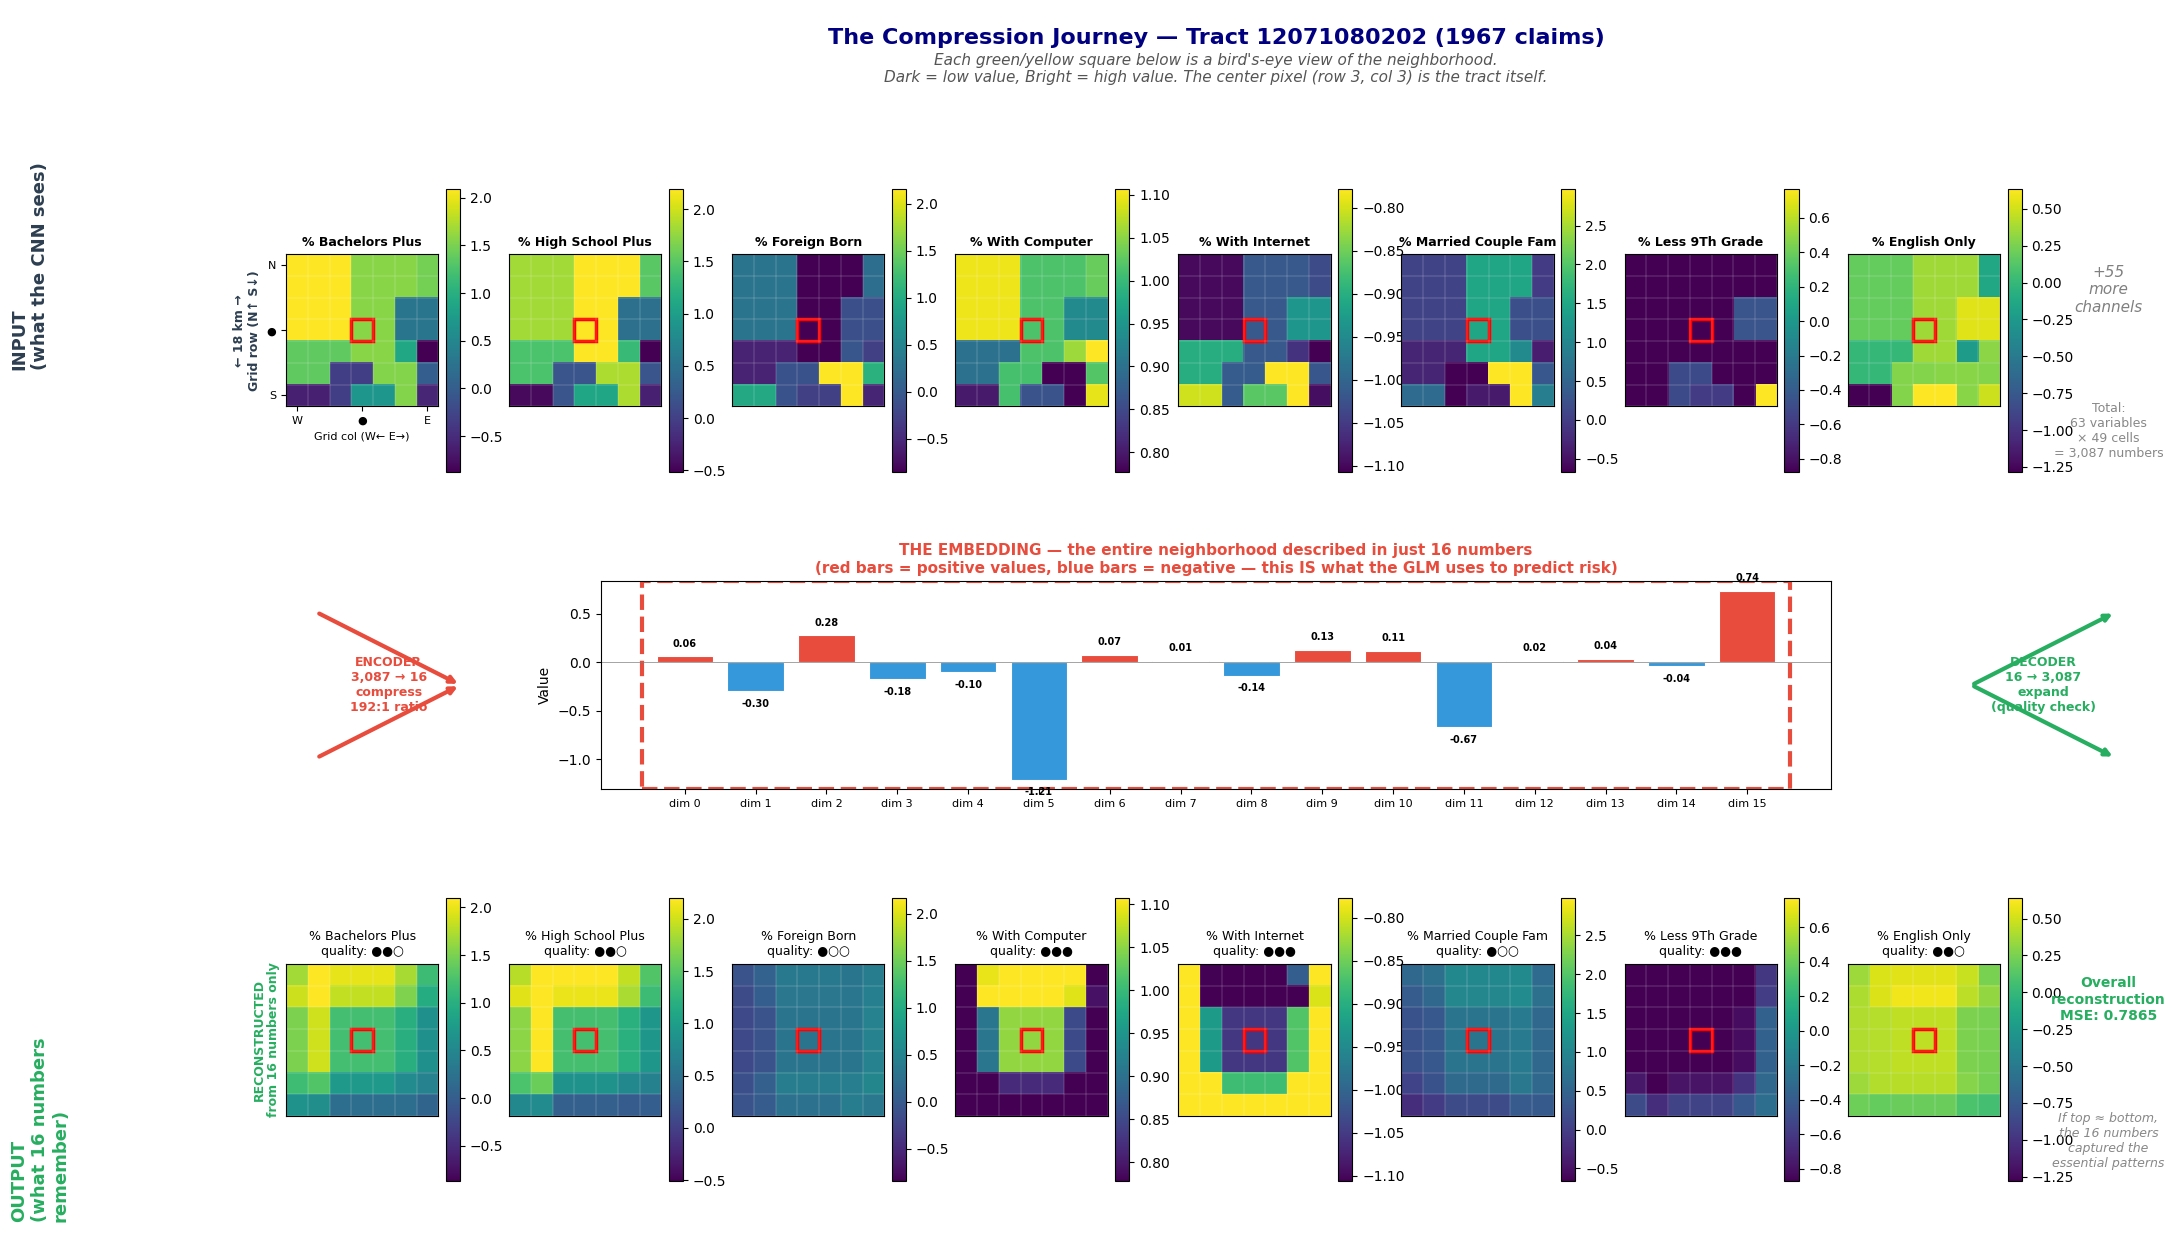


═════════════════════════════════════════════════════════════════
  INFORMATION COMPRESSION SUMMARY
═════════════════════════════════════════════════════════════════
  Original neighborhood data : 7×7 grid × 63 variables = 3,087 numbers
  Embedding                   : 16 numbers
  Compression ratio           : 193 : 1

  Red square in each grid = the tract itself (center cell)
  Surrounding cells = neighboring tracts up to ~9 km away

  Compare top row (original) with bottom row (reconstructed):
  • Similar patterns → the 16 numbers captured the spatial structure
  • Small differences → the autoencoder discarded noise, kept signal
  • This is exactly what we want for risk modeling!
═════════════════════════════════════════════════════════════════


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUAL — The Compression Journey: Grid → Embedding → Reconstruction
# ═══════════════════════════════════════════════════════════════════════════════

from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

# Pick the high-claims tract
demo_idx = train_df['claim_count'].idxmax()
demo_input = train_tensor[demo_idx:demo_idx+1]

model.eval()
with torch.no_grad():
    demo_z, demo_recon = model(demo_input)

orig_np  = demo_input[0].numpy()   # (C, 7, 7)
emb_np   = demo_z[0].numpy()       # (16,)
recon_np = demo_recon[0].numpy()    # (C, 7, 7)

n_show = min(8, len(available_census))

fig = plt.figure(figsize=(24, 16))
gs = GridSpec(4, 1, figure=fig, height_ratios=[0.6, 3.5, 1.8, 3.5], hspace=0.18)

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 0 — Title
# ═══════════════════════════════════════════════════════════════════════════════
ax_title = fig.add_subplot(gs[0])
ax_title.axis('off')
tract_id = train_df.loc[demo_idx, 'tract_geoid']
claims_n = int(train_df.loc[demo_idx, 'claim_count'])
ax_title.text(0.5, 0.6,
    f'The Compression Journey — Tract {tract_id} ({claims_n} claims)',
    transform=ax_title.transAxes, fontsize=16, fontweight='bold',
    ha='center', va='center', color='navy')
ax_title.text(0.5, 0.15,
    f'Each green/yellow square below is a bird\'s-eye view of the neighborhood.\n'
    f'Dark = low value, Bright = high value. The center pixel (row 3, col 3) is the tract itself.',
    transform=ax_title.transAxes, fontsize=11,
    ha='center', va='center', color='#555555', style='italic')

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 1 — The original 7×7 grid (8 channels shown)
# ═══════════════════════════════════════════════════════════════════════════════
gs_orig = gs[1].subgridspec(1, n_show + 1, width_ratios=[1]*n_show + [0.4])

center = GRID_SIZE // 2  # = 3

for j in range(n_show):
    ax = fig.add_subplot(gs_orig[0, j])
    im = ax.imshow(orig_np[j], cmap='viridis', aspect='equal')
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04)

    # Mark the center cell (the tract itself) with a red border
    rect = Rectangle((center-0.5, center-0.5), 1, 1,
                      linewidth=2.5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    # Add grid lines to show individual cells
    for k in range(GRID_SIZE + 1):
        ax.axhline(k - 0.5, color='white', lw=0.3, alpha=0.5)
        ax.axvline(k - 0.5, color='white', lw=0.3, alpha=0.5)

    short_name = available_census[j].replace('pct_','% ').replace('median_','med ').replace('_',' ').title()
    if len(short_name) > 20:
        short_name = short_name[:19] + '…'
    ax.set_title(short_name, fontsize=9, fontweight='bold')

    # Label axes only on first
    if j == 0:
        ax.set_ylabel('← 18 km →\nGrid row (N↑ S↓)', fontsize=9, fontweight='bold', color='#2c3e50')
        ax.set_xlabel('Grid col (W← E→)', fontsize=8)
        ax.set_xticks([0, 3, 6]); ax.set_xticklabels(['W', '●', 'E'], fontsize=8)
        ax.set_yticks([0, 3, 6]); ax.set_yticklabels(['N', '●', 'S'], fontsize=8)
    else:
        ax.set_xticks([]); ax.set_yticks([])

# Label for remaining channels
ax_dots = fig.add_subplot(gs_orig[0, n_show])
ax_dots.axis('off')
ax_dots.text(0.5, 0.6, f'+{len(available_census)-n_show}\nmore\nchannels',
             ha='center', va='center', fontsize=11, style='italic', color='grey',
             transform=ax_dots.transAxes)
ax_dots.text(0.5, 0.25, f'Total:\n{len(available_census)} variables\n× 49 cells\n= {7*7*len(available_census):,} numbers',
             ha='center', va='center', fontsize=9, color='#888',
             transform=ax_dots.transAxes)

# Add row label
fig.text(0.01, 0.72, 'INPUT\n(what the CNN sees)', fontsize=13, fontweight='bold',
         color='#2c3e50', ha='left', va='center', rotation=90)

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 2 — The 16-dimensional embedding (the bottleneck)
# ═══════════════════════════════════════════════════════════════════════════════
gs_emb = gs[2].subgridspec(1, 3, width_ratios=[1, 6, 1])

# Left arrow — COMPRESS
ax_arrow1 = fig.add_subplot(gs_emb[0, 0])
ax_arrow1.axis('off')
ax_arrow1.annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.15),
                   arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3))
ax_arrow1.annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.85),
                   arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3))
ax_arrow1.text(0.5, 0.5, f'ENCODER\n{7*7*len(available_census):,} → 16\ncompress\n{7*7*len(available_census)//LATENT_DIM}:1 ratio',
               ha='center', va='center', fontsize=9, fontweight='bold',
               color='#e74c3c', transform=ax_arrow1.transAxes)

# The embedding bar
ax_emb = fig.add_subplot(gs_emb[0, 1])
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in emb_np]
bars = ax_emb.bar(range(LATENT_DIM), emb_np, color=bar_colors, edgecolor='white', linewidth=0.8)
ax_emb.set_xticks(range(LATENT_DIM))
ax_emb.set_xticklabels([f'dim {i}' for i in range(LATENT_DIM)], fontsize=8)
ax_emb.set_ylabel('Value', fontsize=10)
ax_emb.axhline(0, color='grey', lw=0.5)

# Value labels on each bar
for bar, val in zip(bars, emb_np):
    y_pos = val + 0.08 if val >= 0 else val - 0.08
    ax_emb.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top',
                fontsize=7, fontweight='bold')

# Dashed border around embedding
ylims = ax_emb.get_ylim()
ax_emb.add_patch(Rectangle((-0.6, ylims[0]), LATENT_DIM + 0.2,
                            ylims[1] - ylims[0],
                            fill=False, edgecolor='#e74c3c', lw=3, ls='--'))

ax_emb.set_title(
    f'THE EMBEDDING — the entire neighborhood described in just 16 numbers\n'
    f'(red bars = positive values, blue bars = negative — this IS what the GLM uses to predict risk)',
    fontsize=11, fontweight='bold', color='#e74c3c')

# Right arrow — EXPAND
ax_arrow2 = fig.add_subplot(gs_emb[0, 2])
ax_arrow2.axis('off')
ax_arrow2.annotate('', xy=(0.85, 0.15), xytext=(0.15, 0.5),
                   arrowprops=dict(arrowstyle='->', color='#27ae60', lw=3))
ax_arrow2.annotate('', xy=(0.85, 0.85), xytext=(0.15, 0.5),
                   arrowprops=dict(arrowstyle='->', color='#27ae60', lw=3))
ax_arrow2.text(0.5, 0.5, f'DECODER\n16 → {7*7*len(available_census):,}\nexpand\n(quality check)',
               ha='center', va='center', fontsize=9, fontweight='bold',
               color='#27ae60', transform=ax_arrow2.transAxes)

# ═══════════════════════════════════════════════════════════════════════════════
# ROW 3 — The reconstructed 7×7 grid
# ═══════════════════════════════════════════════════════════════════════════════
gs_recon = gs[3].subgridspec(1, n_show + 1, width_ratios=[1]*n_show + [0.4])

for j in range(n_show):
    ax = fig.add_subplot(gs_recon[0, j])
    vmin, vmax_ch = orig_np[j].min(), orig_np[j].max()
    im = ax.imshow(recon_np[j], cmap='viridis', aspect='equal', vmin=vmin, vmax=vmax_ch)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.04)

    # Same center marker
    rect = Rectangle((center-0.5, center-0.5), 1, 1,
                      linewidth=2.5, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    for k in range(GRID_SIZE + 1):
        ax.axhline(k - 0.5, color='white', lw=0.3, alpha=0.5)
        ax.axvline(k - 0.5, color='white', lw=0.3, alpha=0.5)

    ch_mse = ((orig_np[j] - recon_np[j])**2).mean()
    quality = "●●●" if ch_mse < 0.1 else ("●●○" if ch_mse < 0.5 else "●○○")

    short_name = available_census[j].replace('pct_','% ').replace('median_','med ').replace('_',' ').title()
    if len(short_name) > 20:
        short_name = short_name[:19] + '…'
    ax.set_title(f'{short_name}\nquality: {quality}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

    if j == 0:
        ax.set_ylabel('RECONSTRUCTED\nfrom 16 numbers only', fontsize=9, fontweight='bold', color='#27ae60')

# Summary
ax_dots2 = fig.add_subplot(gs_recon[0, n_show])
ax_dots2.axis('off')
overall_mse = ((orig_np - recon_np)**2).mean()
ax_dots2.text(0.5, 0.6, f'Overall\nreconstruction\nMSE: {overall_mse:.4f}',
              ha='center', va='center', fontsize=10, fontweight='bold', color='#27ae60',
              transform=ax_dots2.transAxes)
ax_dots2.text(0.5, 0.25, f'If top ≈ bottom,\nthe 16 numbers\ncaptured the\nessential patterns',
              ha='center', va='center', fontsize=9, color='#888', style='italic',
              transform=ax_dots2.transAxes)

fig.text(0.01, 0.18, 'OUTPUT\n(what 16 numbers\nremember)', fontsize=13, fontweight='bold',
         color='#27ae60', ha='left', va='center', rotation=90)

plt.savefig('embedding_compression_journey.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ─── Print summary ───────────────────────────────────────────────────────────
n_original = 7 * 7 * len(available_census)
ratio = n_original / LATENT_DIM
print(f"\n{'═'*65}")
print(f"  INFORMATION COMPRESSION SUMMARY")
print(f"{'═'*65}")
print(f"  Original neighborhood data : 7×7 grid × {len(available_census)} variables = {n_original:,} numbers")
print(f"  Embedding                   : {LATENT_DIM} numbers")
print(f"  Compression ratio           : {ratio:.0f} : 1")
print(f"")
print(f"  Red square in each grid = the tract itself (center cell)")
print(f"  Surrounding cells = neighboring tracts up to ~9 km away")
print(f"")
print(f"  Compare top row (original) with bottom row (reconstructed):")
print(f"  • Similar patterns → the 16 numbers captured the spatial structure")
print(f"  • Small differences → the autoencoder discarded noise, kept signal")
print(f"  • This is exactly what we want for risk modeling!")
print(f"{'═'*65}")

---
# Appendix — The Data Journey: From Raw Downloads to GLM

This section traces every transformation the data undergoes, showing the exact shape, size, and content at each stage. If you ever wonder "what does the data look like at this point?" — this is the reference.

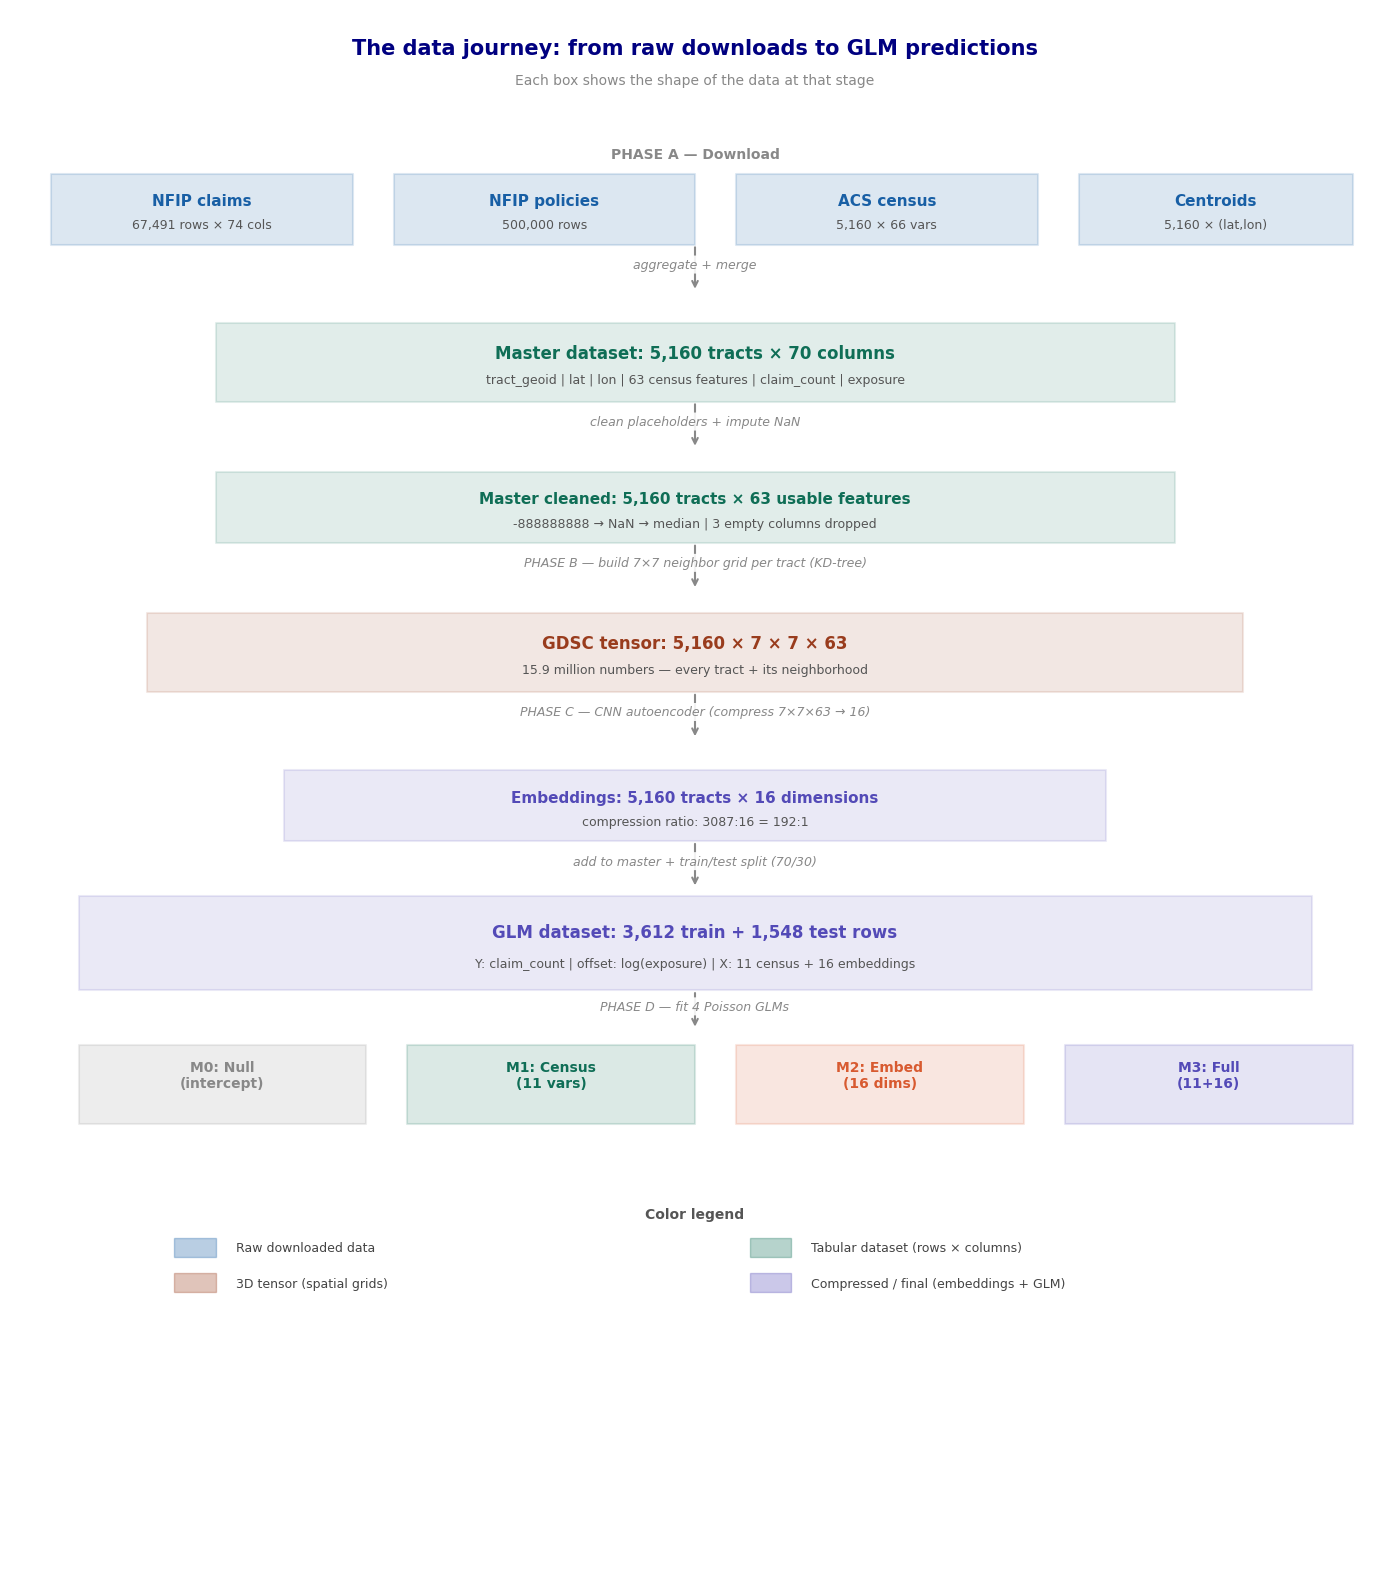

📊 Data journey overview saved as 'data_journey_overview.png'


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA JOURNEY — Overview: the complete pipeline at a glance
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

# ─── Helper functions ─────────────────────────────────────────────────────────
def draw_box(ax, x, y, w, h, title, subtitle, color, alpha=0.15, title_size=11):
    box = plt.Rectangle((x, y), w, h, facecolor=color, alpha=alpha,
                         edgecolor=color, linewidth=1.5, zorder=2, joinstyle='round')
    ax.add_patch(box)
    ax.text(x + w/2, y + h*0.62, title, ha='center', va='center',
            fontsize=title_size, fontweight='bold', color=color, zorder=3)
    if subtitle:
        ax.text(x + w/2, y + h*0.28, subtitle, ha='center', va='center',
                fontsize=9, color='#555', zorder=3)

def draw_arrow(ax, x, y1, y2, color='#888'):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# ─── Title ────────────────────────────────────────────────────────────────────
ax.text(5, 19.5, 'The data journey: from raw downloads to GLM predictions',
        ha='center', va='center', fontsize=15, fontweight='bold', color='navy')
ax.text(5, 19.1, 'Each box shows the shape of the data at that stage',
        ha='center', va='center', fontsize=10, color='#888')

# ─── Stage 1: Raw downloads ──────────────────────────────────────────────────
y = 17.8
ax.text(5, y+0.3, 'PHASE A — Download', ha='center', fontsize=10,
        fontweight='bold', color='#888')
draw_box(ax, 0.3, y-0.8, 2.2, 0.9, 'NFIP claims', f'{len(claims_df):,} rows × {len(claims_df.columns)} cols', '#185FA5')
draw_box(ax, 2.8, y-0.8, 2.2, 0.9, 'NFIP policies', f'{len(policies_df):,} rows', '#185FA5')
draw_box(ax, 5.3, y-0.8, 2.2, 0.9, 'ACS census', f'{len(acs_df):,} × {len(census_feature_names)} vars', '#185FA5')
draw_box(ax, 7.8, y-0.8, 2.0, 0.9, 'Centroids', f'{len(gaz_fl):,} × (lat,lon)', '#185FA5')

# Arrow down
draw_arrow(ax, 5, y-0.8, y-1.4)
ax.text(5, y-1.1, 'aggregate + merge', ha='center', fontsize=9, color='#888',
        style='italic', zorder=4,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# ─── Stage 2: Master dataset ─────────────────────────────────────────────────
y = 15.0
draw_box(ax, 1.5, y, 7, 1.0, f'Master dataset: {len(master):,} tracts × {len(master.columns)} columns',
         'tract_geoid | lat | lon | 63 census features | claim_count | exposure',
         '#0F6E56', alpha=0.12, title_size=12)

draw_arrow(ax, 5, y, y-0.6)
ax.text(5, y-0.3, 'clean placeholders + impute NaN', ha='center', fontsize=9,
        color='#888', style='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# ─── Stage 3: Cleaned master ─────────────────────────────────────────────────
y = 13.2
n_census = len(available_census)
draw_box(ax, 1.5, y, 7, 0.9,
         f'Master cleaned: {len(master):,} tracts × {n_census} usable features',
         f'-888888888 → NaN → median | {66 - n_census} empty columns dropped',
         '#0F6E56', alpha=0.12)

draw_arrow(ax, 5, y, y-0.6)

ax.text(5, y-0.3, 'PHASE B — build 7×7 neighbor grid per tract (KD-tree)',
        ha='center', fontsize=9, color='#888', style='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# ─── Stage 4: GDSC tensor ────────────────────────────────────────────────────
y = 11.3
gdsc_shape = all_cuboids.shape
gdsc_millions = all_cuboids.size / 1e6
draw_box(ax, 1.0, y, 8, 1.0,
         f'GDSC tensor: {gdsc_shape[0]:,} × {gdsc_shape[1]} × {gdsc_shape[2]} × {gdsc_shape[3]}',
         f'{gdsc_millions:.1f} million numbers — every tract + its neighborhood',
         '#993C1D', alpha=0.12, title_size=12)

draw_arrow(ax, 5, y, y-0.6)
ax.text(5, y-0.3, 'PHASE C — CNN autoencoder (compress 7×7×63 → 16)',
        ha='center', fontsize=9, color='#888', style='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# ─── Stage 5: Embeddings ─────────────────────────────────────────────────────
y = 9.4
draw_box(ax, 2.0, y, 6, 0.9,
         f'Embeddings: {len(master):,} tracts × {LATENT_DIM} dimensions',
         f'compression ratio: {7*7*n_census}:16 = {7*7*n_census//16}:1',
         '#534AB7', alpha=0.12)

draw_arrow(ax, 5, y, y-0.6)
ax.text(5, y-0.3, 'add to master + train/test split (70/30)',
        ha='center', fontsize=9, color='#888', style='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# ─── Stage 6: Final GLM dataset ──────────────────────────────────────────────
y = 7.5
n_baseline = len(BASELINE_FEATURES) if 'BASELINE_FEATURES' in dir() else 12
draw_box(ax, 0.5, y, 9, 1.2,
         f'GLM dataset: {len(train_df):,} train + {len(test_df):,} test rows',
         f'Y: claim_count | offset: log(exposure) | X: {n_baseline} census + {LATENT_DIM} embeddings',
         '#534AB7', alpha=0.12, title_size=12)

draw_arrow(ax, 5, y, y-0.5)
ax.text(5, y-0.25, 'PHASE D — fit 4 Poisson GLMs', ha='center', fontsize=9,
        color='#888', style='italic',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.9))

# ─── Stage 7: Four GLMs ──────────────────────────────────────────────────────
y = 5.8
colors_m = ['#888', '#0F6E56', '#D85A30', '#534AB7']
labels_m = ['M0: Null\n(intercept)', f'M1: Census\n({n_baseline} vars)',
            f'M2: Embed\n({LATENT_DIM} dims)', f'M3: Full\n({n_baseline}+{LATENT_DIM})']
for i, (c, lab) in enumerate(zip(colors_m, labels_m)):
    draw_box(ax, 0.5 + i*2.4, y, 2.1, 1.0, lab, '', c, alpha=0.15, title_size=10)

# ─── Legend: what the colors mean ─────────────────────────────────────────────
y = 4.2
ax.text(5, y+0.4, 'Color legend', ha='center', fontsize=10, fontweight='bold', color='#555')
legend_items = [
    ('#185FA5', 'Raw downloaded data'),
    ('#0F6E56', 'Tabular dataset (rows × columns)'),
    ('#993C1D', '3D tensor (spatial grids)'),
    ('#534AB7', 'Compressed / final (embeddings + GLM)'),
]
for i, (c, label) in enumerate(legend_items):
    xi = 1.2 + (i % 2) * 4.2
    yi = y - (i // 2) * 0.45
    ax.add_patch(plt.Rectangle((xi, yi-0.1), 0.3, 0.25, facecolor=c, alpha=0.3, edgecolor=c))
    ax.text(xi + 0.45, yi+0.02, label, fontsize=9, va='center', color='#444')

# ─── Size annotations on the right ───────────────────────────────────────────
sizes = [
    (17.3, f'{len(claims_df)+len(policies_df):,} rows\nraw downloads'),
    (15.3, f'{len(master):,} rows\n× {len(master.columns)} cols'),
    (11.6, f'{gdsc_millions:.0f}M numbers\n(peak size)'),
    (9.7, f'{len(master)*LATENT_DIM:,}\nnumbers'),
]

plt.tight_layout()
plt.savefig('data_journey_overview.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("📊 Data journey overview saved as 'data_journey_overview.png'")

---
## What the data looks like at each stage

The next cell shows **actual samples** from each transformation point — real numbers from the Florida dataset, not schematics.

Tracking tract 12071080202 (1967 claims) through each stage



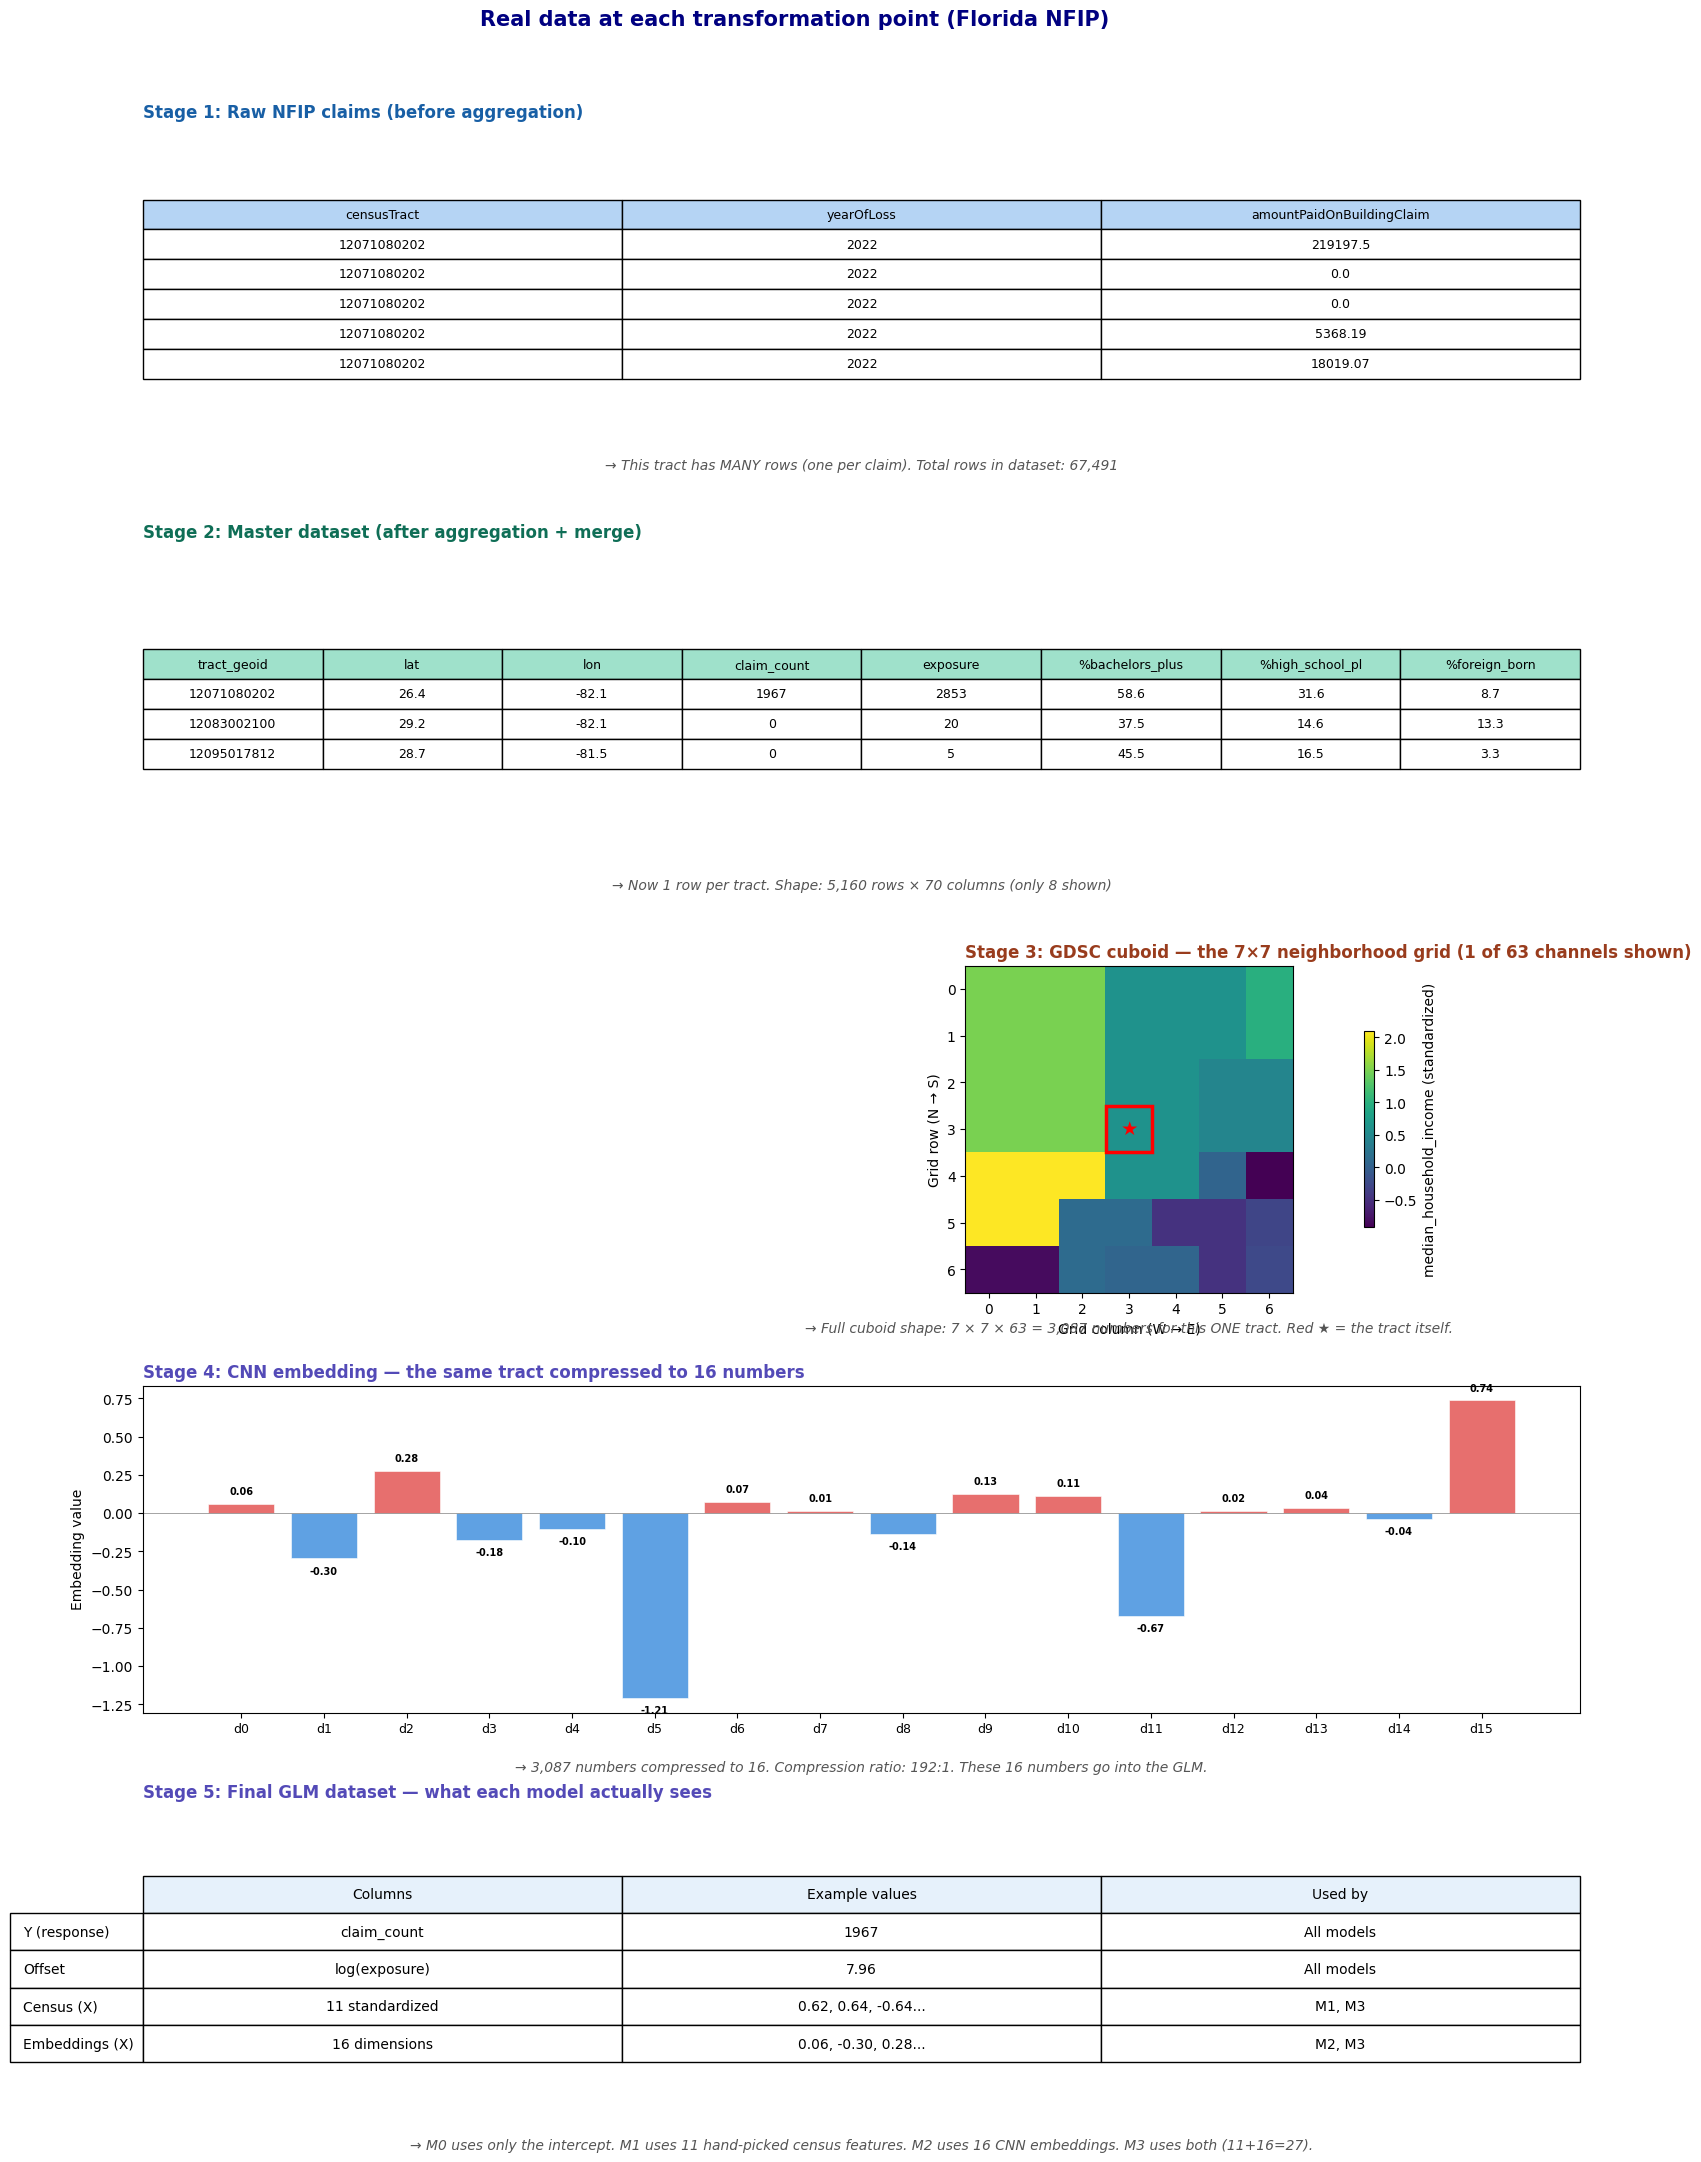


📊 Data journey samples saved as 'data_journey_samples.png'

Summary of the data journey:
  Raw claims:         67,491 rows
  Raw policies:      500,000 rows
  Master dataset:      5,160 tracts × 70 columns
  GDSC tensor:         5,160 × 7×7×63 = 15,928,920 numbers
  Embeddings:          5,160 × 16 = 82,560 numbers
  GLM dataset:         3,612 train + 1,548 test
  Compression:    3,087 → 16 per tract (192:1)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA JOURNEY — Real data samples at each transformation point
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(5, 1, figsize=(16, 22))
fig.suptitle('Real data at each transformation point (Florida NFIP)',
             fontsize=15, fontweight='bold', color='navy', y=0.98)

# ─── Sample tract for consistency ─────────────────────────────────────────────
sample_tract = train_df.loc[train_df['claim_count'].idxmax(), 'tract_geoid']
sample_row_idx = train_df['claim_count'].idxmax()
print(f"Tracking tract {sample_tract} ({int(train_df.loc[sample_row_idx, 'claim_count'])} claims) through each stage\n")

# ─── Panel 1: Raw claims (before aggregation) ────────────────────────────────
ax = axes[0]
ax.axis('off')
ax.set_title('Stage 1: Raw NFIP claims (before aggregation)',
             fontsize=12, fontweight='bold', loc='left', color='#185FA5')

# Show a few raw rows for this tract
if 'tract_geoid' in claims_df.columns:
    sample_claims = claims_df[claims_df['tract_geoid'] == sample_tract].head(5)
elif 'censusTract' in claims_df.columns:
    sample_claims = claims_df[claims_df['censusTract'].astype(str).str.contains(sample_tract[-6:])].head(5)
else:
    sample_claims = claims_df.head(5)

show_cols = [c for c in ['censusTract','yearOfLoss','amountPaidOnBuildingClaim','floodZone'] if c in sample_claims.columns][:4]
if len(show_cols) > 0 and len(sample_claims) > 0:
    cell_text = sample_claims[show_cols].astype(str).values.tolist()
    table1 = ax.table(cellText=cell_text, colLabels=show_cols,
                      cellLoc='center', loc='center', colColours=['#B5D4F4']*len(show_cols))
    table1.auto_set_font_size(False); table1.set_fontsize(9); table1.scale(1, 1.6)

ax.text(0.5, -0.05, f'→ This tract has MANY rows (one per claim). Total rows in dataset: {len(claims_df):,}',
        ha='center', fontsize=10, color='#555', style='italic', transform=ax.transAxes)

# ─── Panel 2: Master dataset (after merge) ───────────────────────────────────
ax = axes[1]
ax.axis('off')
ax.set_title('Stage 2: Master dataset (after aggregation + merge)',
             fontsize=12, fontweight='bold', loc='left', color='#0F6E56')

show_cols2 = ['tract_geoid', 'lat', 'lon', 'claim_count', 'exposure']
census_sample_cols = available_census[:3]
all_show = show_cols2 + census_sample_cols

# Get 3 sample rows including our tracked tract
sample_master = master[master['tract_geoid'] == sample_tract].head(1)
other_rows = master.sample(2, random_state=42)
sample_rows = pd.concat([sample_master, other_rows])[all_show].round(1)

cell_text2 = sample_rows.astype(str).values.tolist()
short_labels = [c.replace('pct_','%').replace('median_','med_')[:15] for c in all_show]
table2 = ax.table(cellText=cell_text2, colLabels=short_labels,
                  cellLoc='center', loc='center', colColours=['#9FE1CB']*len(short_labels))
table2.auto_set_font_size(False); table2.set_fontsize(9); table2.scale(1, 1.6)

ax.text(0.5, -0.05, f'→ Now 1 row per tract. Shape: {len(master):,} rows × {len(master.columns)} columns (only {len(all_show)} shown)',
        ha='center', fontsize=10, color='#555', style='italic', transform=ax.transAxes)

# ─── Panel 3: GDSC cuboid (one tract's 7×7 grid) ────────────────────────────
ax = axes[2]
ax.set_title('Stage 3: GDSC cuboid — the 7×7 neighborhood grid (1 of 63 channels shown)',
             fontsize=12, fontweight='bold', loc='left', color='#993C1D')

# Find master index for our tract
master_idx = master[master['tract_geoid'] == sample_tract].index
if len(master_idx) > 0:
    cuboid_idx = master_idx[0]
    # Pick the most interesting census feature to show
    feat_idx = 0
    for j, fn in enumerate(available_census):
        if 'income' in fn.lower() or 'poverty' in fn.lower():
            feat_idx = j; break
    grid_slice = all_cuboids[cuboid_idx, :, :, feat_idx]
    im = ax.imshow(grid_slice, cmap='viridis', aspect='equal')
    plt.colorbar(im, ax=ax, shrink=0.6, label=f'{available_census[feat_idx]} (standardized)')

    # Mark center
    center = GRID_SIZE // 2
    rect = plt.Rectangle((center-0.5, center-0.5), 1, 1, lw=2.5,
                          edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    ax.set_xlabel('Grid column (W → E)'); ax.set_ylabel('Grid row (N → S)')
    ax.text(center, center, '★', ha='center', va='center', fontsize=14, color='red')
else:
    ax.text(0.5, 0.5, 'Tract not found in master', ha='center', transform=ax.transAxes)

ax.text(0.5, -0.12, f'→ Full cuboid shape: 7 × 7 × {len(available_census)} = {7*7*len(available_census):,} numbers for this ONE tract. Red ★ = the tract itself.',
        ha='center', fontsize=10, color='#555', style='italic', transform=ax.transAxes)

# ─── Panel 4: Embedding (16 numbers) ─────────────────────────────────────────
ax = axes[3]
ax.set_title('Stage 4: CNN embedding — the same tract compressed to 16 numbers',
             fontsize=12, fontweight='bold', loc='left', color='#534AB7')

emb_vals = [train_df.loc[sample_row_idx, f'emb_{i}'] for i in range(LATENT_DIM)]
colors_bar = ['#E24B4A' if v > 0 else '#378ADD' for v in emb_vals]
bars = ax.bar(range(LATENT_DIM), emb_vals, color=colors_bar, edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_xticks(range(LATENT_DIM))
ax.set_xticklabels([f'd{i}' for i in range(LATENT_DIM)], fontsize=9)
ax.set_ylabel('Embedding value')
ax.axhline(0, color='grey', lw=0.5)

for bar, val in zip(bars, emb_vals):
    y_pos = val + 0.05 if val >= 0 else val - 0.05
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:.2f}',
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=7, fontweight='bold')

ax.text(0.5, -0.18,
        f'→ {7*7*len(available_census):,} numbers compressed to 16. '
        f'Compression ratio: {7*7*len(available_census)//16}:1. '
        f'These 16 numbers go into the GLM.',
        ha='center', fontsize=10, color='#555', style='italic', transform=ax.transAxes)

# ─── Panel 5: Final GLM row ──────────────────────────────────────────────────
ax = axes[4]
ax.axis('off')
ax.set_title('Stage 5: Final GLM dataset — what each model actually sees',
             fontsize=12, fontweight='bold', loc='left', color='#534AB7')

# Build the table showing what each model uses
row_data = train_df.loc[sample_row_idx]
n_bl = len(BASELINE_FEATURES) if 'BASELINE_FEATURES' in dir() else 0

table_data = [
    ['Component', 'Columns', 'Example values', 'Used by'],
    ['Y (response)', 'claim_count', f'{int(row_data["claim_count"])}', 'All models'],
    ['Offset', 'log(exposure)', f'{row_data["log_exposure"]:.2f}', 'All models'],
]

if n_bl > 0:
    bl_vals = ', '.join([f'{row_data.get("z_"+f, 0):.2f}' for f in BASELINE_FEATURES[:3]]) + '...'
    table_data.append(['Census (X)', f'{n_bl} standardized', bl_vals, 'M1, M3'])

emb_str = ', '.join([f'{row_data[f"emb_{i}"]:.2f}' for i in range(3)]) + '...'
table_data.append(['Embeddings (X)', f'{LATENT_DIM} dimensions', emb_str, 'M2, M3'])

colors_table = ['#D3D1C7'] + ['#B5D4F4']*2 + ['#9FE1CB']*(1 if n_bl > 0 else 0) + ['#F5C4B3']
cell_text = [r[1:] for r in table_data[1:]]
col_labels = table_data[0][1:]

table5 = ax.table(cellText=cell_text, rowLabels=[r[0] for r in table_data[1:]],
                  colLabels=col_labels,
                  cellLoc='center', loc='center',
                  colColours=['#E6F1FB']*3)
table5.auto_set_font_size(False); table5.set_fontsize(10); table5.scale(1, 2.0)

ax.text(0.5, -0.05,
        f'→ M0 uses only the intercept. M1 uses {n_bl} hand-picked census features. '
        f'M2 uses {LATENT_DIM} CNN embeddings. M3 uses both ({n_bl}+{LATENT_DIM}={n_bl+LATENT_DIM}).',
        ha='center', fontsize=10, color='#555', style='italic', transform=ax.transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('data_journey_samples.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Data journey samples saved as 'data_journey_samples.png'")
print(f"\nSummary of the data journey:")
print(f"  Raw claims:     {len(claims_df):>10,} rows")
print(f"  Raw policies:   {len(policies_df):>10,} rows")
print(f"  Master dataset: {len(master):>10,} tracts × {len(master.columns)} columns")
print(f"  GDSC tensor:    {all_cuboids.shape[0]:>10,} × {GRID_SIZE}×{GRID_SIZE}×{len(available_census)} = {all_cuboids.size:,} numbers")
print(f"  Embeddings:     {len(master):>10,} × {LATENT_DIM} = {len(master)*LATENT_DIM:,} numbers")
print(f"  GLM dataset:    {len(train_df):>10,} train + {len(test_df):,} test")
print(f"  Compression:    {7*7*len(available_census):,} → {LATENT_DIM} per tract ({7*7*len(available_census)//LATENT_DIM}:1)")

---
### Reading the panels above

**Panel 1 (blue):** The raw claims as downloaded from FEMA — notice how the same tract appears MANY times (once per claim). We need to aggregate these into a single count per tract.

**Panel 2 (green):** After aggregation and merge — now each tract appears exactly ONCE, with its claim count, exposure, geographic coordinates, and census features all in one row. This is a traditional tabular dataset.

**Panel 3 (orange):** The spatial transformation — for our tracked tract (red star in the center), we see the 7×7 neighborhood grid for one census variable. Each cell is a neighboring tract ~3 km away. The color shows the value of that variable. The CNN sees 63 of these grids stacked together.

**Panel 4 (purple):** The CNN's output — the same tract is now described by just 16 numbers. Red bars = positive, blue = negative. Each bar captures a different "theme" about the neighborhood that the CNN learned automatically.

**Panel 5 (table):** What each GLM model actually receives as input. All models predict the same Y (claim count) with the same offset (log exposure). The difference is which X columns they use — and that difference is what our experiment tests.